<a href="https://colab.research.google.com/github/mwithgod3952/TIL/blob/main/Marketing_Analytics_Cohort_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title <font size = 1><font color='white'>.
%%capture

from google.colab import drive; drive.mount('/content/drive/', force_remount=True)
import os; os.chdir('/content/drive/MyDrive/portfolio0_business_analytics')
local_download_path = '/content/drive/MyDrive/portfolio0_business_analytics/dataset'

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRUWdW_JxRVna87eS8ZnNfzH6SwfBHb7gWgAw&usqp=CAU" width='100'/><font size = 2> <b><font color = 'grey'>"Installation1"</font>은 한글을 포함한 시각화를 위해 폰트를 설치해야 해요.</b></font>

<font size = 2> <i>( 적용을 위해, 설치 후 세션을 재시작해 주세요. )</i></font>




In [1]:
#@title <font color = 'grey'><font size = 3><b>Installation1</b></font>

%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
#@title <font color = 'grey'><font size = 3><b>Libraries</b></font>

%%capture

# Install necessary Python packages for data visualization, machine learning, and other utilities
!pip install adjustText
!pip install -U kaleido
!pip install chart_studio
!pip install -U -q PyDrive
!pip install highlight_text
!pip install emoji --upgrade
!pip install -q dataprep pycaret

# Update the package list on the system and install wget and unzip utilities
!apt-get update
!apt-get install -y wget unzip

# Download and install Google Chrome for web scraping or automated browser tasks
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get -f install -y

# Install Selenium and Chromedriver for automated web interactions
!pip install selenium chromedriver-autoinstaller

# Authenticate user for data sharing
from google.colab import auth
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from oauth2client.client import GoogleCredentials

# data analysis and scientific computing
import os
import re
import io
import ast
import sys
import csv
import copy
import time
import math
import pickle
import base64
import random
import logging
import operator
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
from io import BytesIO
from numpy import asarray
from multiprocessing import Pool
from collections import namedtuple
from datetime import datetime, timedelta, date

import scipy.stats as sts
from scipy.stats import t
import statsmodels.api as sm
from sklearn.cluster import KMeans
from scipy.stats import linregress
from scipy.spatial import distance
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from scipy.stats import shapiro, gaussian_kde
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from mpl_toolkits.mplot3d import Axes3D,axes3d
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess

# web scraping and data collection.
import requests
from bs4 import BeautifulSoup
from google.colab import files
from selenium import webdriver
import chromedriver_autoinstaller
from IPython.display import Image, display

# visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from highlight_text import ax_text
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch
from matplotlib.font_manager import FontProperties
plt.rc('font', family='NanumBarunGothic')
%matplotlib inline
import seaborn as sns
sns.set(font='NanumBarunGothic', rc={"axes.unicode_minus":False}, style='white')

import chart_studio
import chart_studio.plotly as py

import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image
from plotly.subplots import make_subplots

# adjusting the positions of text labels in plots
from adjustText import adjust_text
# interactive data tables for displaying data in Google Colab
from google.colab import data_table
# automatically generating comprehensive reports
from dataprep.eda import create_report

# options
from IPython import display
from IPython.display import Image, display, HTML

pd.options.mode.chained_assignment = None
import warnings
warnings.filterwarnings('ignore')

<font color = 'white'><font size = 10>.</font>

<img src = "https://media.bazaarvoice.com/shutterstock_2813452041-1030x386.jpg" width="150"/><font size = 2><b> 아래 <img src = "https://creazilla-store.fra1.digitaloceanspaces.com/emojis/45439/play-button-emoji-clipart-xl.png" width="25"/> 버튼으로 실행하면, 그 다음 셀의 "<u>data_prepa()</u></b> - <i>{Data Download Program(Launchar)}</i>"<b>을 활성화 시킬 수 있습니다.</b></font>

In [ ]:
#@title <font color = 'grey'><font size = 4><b>Data preparation</b></font>

def data_prepa():
    global local_download_path, file_list
    # from google.colab import drive; drive.mount('/content/drive', force_remount=True)

    from traceback import print_exc
    from google.colab import drive; drive.mount( '/content/drive', force_remount=True )

    print('\n\n\033[1m\033[94m---\033[0m\n');
    new_path = input('- 작업을 희망하는 구글 드라이브 내 폴더명을 입력해주세요: '); print('\n')

    import os; wp = os.getcwd()
    while True:
        try:
            listdir = os.listdir(wp)
            wp_ = wp
            for di in listdir:
                if 'drive' in di.lower():
                    wp += f'/{di}'
            if wp_ == wp:

                if new_path in listdir:
                    wp += f'/{new_path}'; os.chdir(wp)
                    break
                else:
                    new_path = input('\n\n\tThe specified working directory is not valid. Please enter the folder name again.\n\n')
        except Exception as e:
            print('type is:', e.__class__.__name__)
            print_exc()

    new_path = wp
    os.chdir(new_path)
    for step_i in tqdm(range(2)):
        if step_i == 0:
            print('\t\033[1m The working path has been successfully changed\033[0m')
        elif step_i == 1:
            if os.getcwd() == new_path:
                print(f'\t\033[1mMounted at{new_path}\033[0m\n')
            else:
                print(f'\t\033[1mfailed mount\033[0m\n')

    display.clear_output()
    print('\n\033[1m\033[94m---\033[0m\n');
    URL = input('- 공유받고자 하는 파일의 링크를 입력해주세요.: ')
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    if '/folders/' in URL:
        shared_drv_id = URL[URL.find('/folders/'):].split('/')[2].split('?')[0]
        Q = '- 저장하고자 하는 폴더의 이름을 입력해 주세요.: '
        folder_name = input(Q)
        local_download_path = f'{os.getcwd()}/{folder_name}'
        try:
            os.makedirs(local_download_path)
        except: print('e1'); pass;
        file_list = drive.ListFile(
            {'q': f"'{shared_drv_id}' in parents and trashed=false"}).GetList()
        try:
            print('\n')
            if len(file_list) > 0:
                for fi in tqdm(file_list):
                    drive.CreateFile({'id':fi['id']}).GetContentFile(f"{local_download_path}/{fi['title']}")
            import time; time.sleep(1)
            if len(os.listdir(local_download_path)) == len(file_list):
                print(emoji.emojize('\t\033[1mNew datasset has been created\033[0m :memo:'))
                time.sleep(1.5)
                display.clear_output()
                print('\t\033[1mThe file path is stored in variable \033[91mlocal_download_path\033[0m')
        except: print('e2'); pass;
    else:
        filename_extention = '.csv'
        shared_drv_id = URL[URL.find('/d/'):].split('/')[2]
        Q = '저장하고자 하는 파일의 이름을 입력해 주세요. (확장자명 제외): '
        filename = input(Q)
        drive.CreateFile({'id':shared_drv_id}).GetContentFile(f'{os.getcwd()}')

        i = 0
        for fi in os.listdir():
            if filename in fi:
                i += 1
        if i > 0:
            print('\n')
            print('*'*1)
            print('\t\033[1mNew data has been created\033[0m')
            print('\033[1m\033[0m')
            df = pd.read_csv(f'{filename}.csv').iloc[:, 1:]
            print('*'*2)
            print('\t\033[1mThe file is stored in variable df.\033[0m')

<img src="https://i.pinimg.com/736x/80/0b/a2/800ba20898c79ee5d503306f4391395e.jpg" width='40'/><font size = 2> <b>input box로 요청드리는 본인의 <font color = 'slateblue'>"경로정보"</font>와 하단 셀에 기재해둔 <font color = 'slateblue'>"공유폴더 URL"</font>을 절차에 따라 입력-실행하면 데이터셋 다운로드가 진행됩니다.</b></font>

In [ ]:
# 공유폴더 URL: https://drive.google.com/drive/folders/18aPJXG7CZKbCAo1Xl4JH45R2h6hx0u6m?usp=sharing
data_prepa()

	The file path is stored in variable local_download_path


<img src="https://i.pinimg.com/736x/80/0b/a2/800ba20898c79ee5d503306f4391395e.jpg" width='40'/><font size = 2> <b>데이터들을 모두 다운받은 후, <font color = 'crimson'>"local_download_path"</font> 변수를 실행하면 데이터가 저장된 파일경로를 확인할 수 있습니다.</b></font>

In [ ]:
print(f'\t\033[1m{local_download_path}\033[0m')

<font size = 10><font color = 'white'>.

<font color = 'grey'><font size = 3><b>📑 About Dataset</b>

- <font color = 'black'><font size = 2><b>Context</b>
    * <font size = 2>본 데이터셋은 일반적으로 공개되기 어려운 전자상거래 데이터를 제공하고 있습니다. <b>The UCI Machine Learning Repository</b>에서 <i>'Online Retail'</i>이라는 제목으로 관리되고 있는 본 데이터셋은 2010년 12월 1일부터 2011년 12월 9일 사이에 영국 기반의 온라인 소매 기업에서 발생한 실제 거래 내역을 포함하고 있습니다.

- <font color = 'black'><font size = 2><b>Content</b>
    * <font size = 2>본 회사는 주로 특별한 선물  용품을 판매하며 많은 고객이 도매상입니다.

- <font color = 'black'><font size = 2><b>Inspiration</b>
    * <font size = 2>이 데이터셋을 활용하면 시계열 분석, 클러스터링, 분류 등 다양한 분석을 수행할 수 있습니다. <u>이는 전자상거래 분야에서 유용한 정보를 제공할 수 있을 것으로 기대됩니다</u>.

<font size = 10><font color = 'white'>.    

<font color = 'white'>.</font>

<center><font color = 'blue'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

<font color = 'grey'><font size = 4><b>Data Preprocessing</b></font>

In [3]:
import multiprocessing as mp; print('\n\t - number of CPUs available', mp.cpu_count())


	 - number of CPUs available 8


In [4]:
dataset = [x for x in os.listdir(local_download_path)]
print(dataset)

['data.csv', 'online_retail_final.csv']


In [5]:
df1 = pd.read_csv(f'{local_download_path}/{dataset[0]}', encoding= 'unicode_escape')

In [6]:
# 데이터프레임의 모든 컬럼명을 리스트로 변환
col_names = df1.columns.tolist()

# 컬럼별 데이터 타입을 확인하고 출력
print(f"\n - \033[1mCheck the datatype of each column\033[0m")

# 각 컬럼명을 순회하면서 데이터 타입을 출력
for x in col_names:
    # 만약 데이터 타입이 '<M8[ns]'이 아닌 경우 (datetime 형식이 아닌 경우)
    if (x.endswith('Date')) and (df1[x].dtype != '<M8[ns]'):
        # 붉은색으로 굵게 강조하여 경고 메세지 출력
        print(f"\t \033[91m\033[1m{x}: {df1[x].dtype}\033[0m")
    else:
        # 그렇지 않은 경우 일반 출력
        print(f"{x}: {df1[x].dtype}")


 - Check the datatype of each column
InvoiceNo: object
StockCode: object
Description: object
Quantity: int64
	 InvoiceDate: object
UnitPrice: float64
CustomerID: float64
Country: object


In [7]:
# 날짜 문자열을 특정 포맷을 사용하여 datetime 객체로 변환하는 함수 정의
def convert_to_dt(input_series, fm):
    return pd.to_datetime(input_series, format=fm)

# 'InvoiceDate' 컬럼을 지정한 포맷에 따라 datetime 객체로 변환
df1['InvoiceDate'] = convert_to_dt(input_series=df1['InvoiceDate'], fm="%m/%d/%Y %H:%M")

# 'InvoiceDate' 컬럼의 복사본을 생성
T_mdy_hm = df1['InvoiceDate'].copy()

# 날짜와 시간을 별도로 저장하기 위한 리스트 초기화
mdy_hm = []

# 날짜와 시간 형식을 지정하는 문자열 리스트를 순회
for dt in ["%m/%d/%Y", "%H:%M"]:
    # 각 형식에 맞게 날짜와 시간을 문자열로 변환
    y = T_mdy_hm.apply(lambda x: x.strftime(dt))
    # 변환된 결과를 리스트에 추가
    mdy_hm.append(y)

# 'Inv_date' 컬럼에 날짜 부분만 datetime 객체로 변환하여 저장
df1['Inv_date'] = convert_to_dt(mdy_hm[0], "%m/%d/%Y")

# 'InvoiceDate' 컬럼의 데이터 타입을 확인하고, datetime 형식 여부에 따라 출력
if df1.InvoiceDate.dtype == '<M8[ns]':
    print('T')  # datetime 형식이면 'T' 출력
else:
    print('F')  # datetime 형식이 아니면 'F' 출력

T


In [8]:
# 데이터프레임의 크기(행과 열의 수)를 출력
print(f'\t\n \033[1mShape : {df1.shape}\033[0m \n')

# NULL 값에 대한 정보를 출력
print(f'\033[1m- NULL\033[0m')

# 각 컬럼의 NULL 값 개수를 출력
print(df1.isnull().sum())
print('\n')

	
 Shape : (541909, 9) 

- NULL
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Inv_date            0
dtype: int64




In [9]:
# 'Description' 컬럼에서 NULL 값을 가진 행들을 필터링하여 새로운 데이터프레임 생성
des_nullDf = df1[df1.Description.isnull()].reset_index( drop=True )

In [10]:
# 'Description' 컬럼이 NULL인 행의 개수와 'CustomerID' 컬럼이 NULL인 행의 개수가 같은지 확인
if len(des_nullDf) == des_nullDf.CustomerID.isnull().sum():
    print('T') # 같으면 'T'를 출력
else:
    print('F') # 다르면 'F'를 출력

T


In [11]:
# 'UnitPrice' 컬럼에서 각 값이 나타나는 빈도수 출력
des_nullDf.UnitPrice.value_counts()

,UnitPrice
0.0,1454


<font size = 2>상위의 과정을 통해 "Description" 열에 포함된 내용이 없을 때 "CustomerID" 정보 역시 누락되어 있음을 확인하였습니다, 더불어, "UnitPrice"는 0임을 확하였습니다.</font>

In [12]:
# 'df1' 데이터프레임에서 'Description' 열이 null이 아닌 행만 필터링하여 새로운 데이터프레임 'des_notnullDf' 생성
des_notnullDf = df1[df1.Description.notnull()].reset_index(drop=True)

# 'des_notnullDf'에서 'CustomerID' 열이 null인 경우의 수를 계산
ID_NULL_cnt = des_notnullDf.CustomerID.isnull().sum()

# 'Description' 정보가 존재하지만 'CustomerID' 정보가 누락된 경우의 수를 출력
print(f'\n\t \033[1m- "Description"정보가 확인되나, ID 정보가 누락된 경우의 수 : {ID_NULL_cnt}\033[0m')


	 - "Description"정보가 확인되나, ID 정보가 누락된 경우의 수 : 133626


In [13]:
# 'df1' 데이터프레임에서 'Description' 열과 'CustomerID' 열이 모두 null이 아닌 행만 선택하여 새로운 'df1' 데이터프레임 생성
df1 = df1[df1.Description.notnull() & df1.CustomerID.notnull()]

# 'df1' 데이터프레임의 각 열에 대한 null 값의 개수를 계산
df1.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Inv_date,0


In [14]:
"""
    ⓵. 'df1' 데이터프레임의 'InvoiceNo' 열에 대해 정규표현식을 사용하여 영문자가 포함된 경우 'Y', 그렇지 않은 경우 'N'을 반환하는 함수를 적용
    ⓶. ⓵.의 결과가 'Y'인 행의 'InvoiceNo' 열 값을 추출하여 첫 번째 문자만 추출하고 고유한 값을 반환
"""

df1.loc[df1['InvoiceNo'].apply(lambda x: str('Y') if re.search('[a-zA-Z]+', x) else str('N')) == 'Y', 'InvoiceNo'].apply(lambda x: str(x)[0]).unique()

array(['C'], dtype=object)

In [15]:
# 'df1' 데이터프레임에서 'InvoiceNo' 열 값이 'C'로 시작하는 행을 선택하여 'wC' 변수에 저장
wC  = df1[df1['InvoiceNo'].apply(lambda x: x.startswith('C'))]

# 'df1' 데이터프레임에서 'InvoiceNo' 열 값에 'A'와 'C'가 모두 포함되지 않는 행을 선택하여 'nwC' 변수에 저장
nwC = df1[df1['InvoiceNo'].apply(lambda x: True if len(set('AC') & set(x)) == 0 else False)]

# 'wC' 데이터프레임의 모든 행의 'Quantity' 열 값이 음수이고, 'nwC' 데이터프레임의 모든 행의 'Quantity' 열 값이 0 이상인 경우 'T'를 출력, 그렇지 않은 경우 'N'을 출력
if (len(wC) == sum(wC.Quantity < 0)) and (len(nwC) == sum(nwC.Quantity >= 0)):
    print('T')
else:
    print('N')

T


<font size = 2>'InvoiceNO'정보 값 중 특정 값에 알파벳 값이 결합된 경우를 발견하여 확인해본 결과, 일반 정수값 번호 외에 'C'와 'A'가 결합된 경우를 확인하였습니다.</font>

<font size = 2><b>그 중, 'C'로 구분한 Quantity값이 모두 음수 인 것을 확인하였고 더불어, Quantity값이 음수이나 'InvoiceNO'값이 잘못 구분된 케이스는 없음을 확인하였음으로, 'C'는 취소된 주문건을 구분하기 위한 구분자임을 확신</b>할 수 있습니다.</font>


<font size = 2>우선 'Cancelled'라는 열을 만들어 주문취소가 포함된 행을 1로 나머지 행을 0으로 구분합니다.</font>


In [16]:
# 'Cancelled'라는 열을 만들어 주문취소가 포함된 행을 1로 나머지 행을 0으로 구분
df1.loc[wC.index, 'Cancelled'] = int(1); df1.loc[df1.Cancelled.isnull(), 'Cancelled'] = int(0)

<font size = 2>아래부터는 주문건에 대한 정보만을을 취합하여 분석을 진행하겠습니다.</font>

In [17]:
# 'df1' 데이터프레임에서 'Cancelled' 열 값이 0인 행만 선택하여 '_df1' 변수에 저장
_df1 = df1[df1.Cancelled == 0]

# '_df1' 데이터프레임의 'Cancelled' 열 값의 빈도수를 계산하여 출력
_df1.Cancelled.value_counts()

,Cancelled
0.0,397924


In [18]:
# '_df1' 데이터프레임에서 'StockCode' 열 값이 영문자로 시작하는 행을 제외하고 선택
_df1 = _df1[~ _df1['StockCode'].str.contains("^[a-zA-Z]")]

# '_df1' 데이터프레임의 'Description' 열 값을 모두 소문자로 변환하여 저장
_df1.loc[:, 'Description'] = list(_df1.Description.str.lower())

In [19]:
# '_df1' 데이터프레임에서 'UnitPrice' 열 값이 0보다 큰 행만 선택
_df1 = _df1[_df1.UnitPrice > 0]

<font size = 2>각 열의 값이 완전히 중복된 행의 경우, 데이터 기록 시 오기입된 정보로 판단하여 삭제합니다.</font>

In [20]:
# '_df1' 데이터프레임에서 중복된 행을 제거하고 인덱스를 재설정
_df1 = _df1.drop_duplicates(keep='first').reset_index(drop=True)

<font color = 'white'>.</font>

<center><font color = 'blue'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

<font size = 2><b>"df1 데이터셋은 주문 취소와 관련된 정보를 포함하고 있으며, 전처리 과정을 거쳐 주문 취소된 항목이 제거된 상태로 _df1 데이터셋이 생성되었습니다. 이는 데이터의 정제가 완료된 후의 결과물입니다."</b></font>

<font size = 2>이후 진행되는 분석 과정에서 주로 사용되는 데이터셋은 `_df1`<i>(주문 취소된 항목이 제거된 상태)</i>이고, 취소 원인을 분석하기 위해 부분적으로 `df1` 데이터셋을 활용합니다.

<font color = 'white'>.</font>

<center><font color = 'lightgrey'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

<font size = 2>위, 전처리<i>(</i>preprocessing<i>)</i> 과정을 통해 얻은 `_df1`변수에 저장된 테이블 데이터가 앞으로의 분석과정에서 주되게 다뤄집니다. 본격적인 분석에 앞서 데이터가 가지고 있는 '통계정보' 및 '특징'들을 개괄적으로 살펴봅니다.

In [ ]:
#@title <font color = 'grey'><font size = 3><b>Generate a Comprehensive Data Analysis Report</b></font>

%%capture

# 1. 보고서 생성 및 저장
report = create_report(_df1, display=["Overview"])

# 보고서 파일 이름 설정
file_name = os.path.basename(os.path.abspath(os.getcwd())) + '_Report.html'

# 보고서 파일 저장
report.save(file_name)

# 보고서 파일의 전체 경로 설정
file_name_W_foler_name = os.getcwd() + f'/{file_name}'
file_name_W_foler_name

# 3. ChromeDriver 설정 및 HTML 파일 열기
chromedriver_autoinstaller.install()

# Chrome Option
options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--remote-debugging-port=9222')
options.add_argument('--disable-gpu')
options.add_argument('--window-size=1280x720')
options.binary_location = '/usr/bin/google-chrome'

driver = webdriver.Chrome(options=options)

# HTML 파일 경로 설정
html_file = file_name_W_foler_name

# HTML 파일을 브라우저로 열기
driver.get('file://' + html_file)

# 스크린샷 저장 경로 설정
screenshot_path = file_name_W_foler_name.split('.')[0] + '.png'

# 스크린샷 저장
driver.save_screenshot(screenshot_path)

driver.quit()

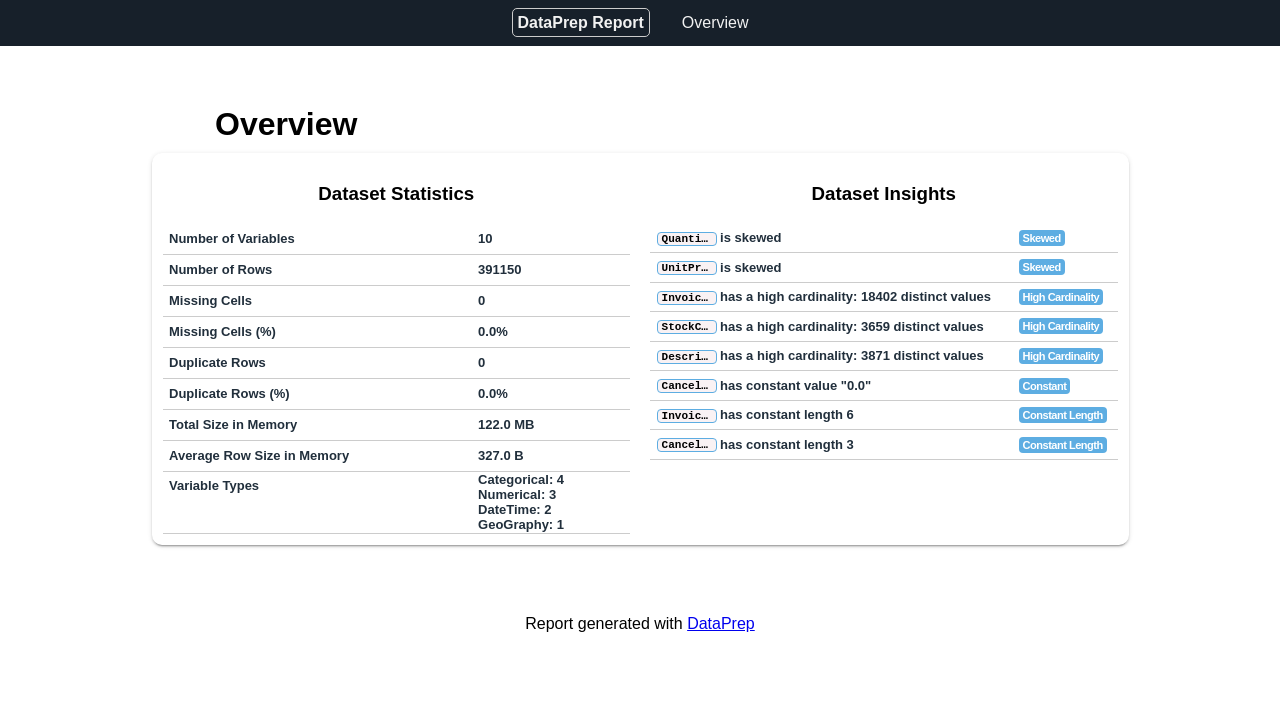

In [ ]:
display(Image(screenshot_path))

In [21]:
basic_statistics = _df1.loc[:, ['Quantity', 'UnitPrice']].describe()
data_table.DataTable(basic_statistics.rename_axis('basic_statistics'))

,Quantity,UnitPrice
basic_statistics,,
count,391150.000000,391150.000000
mean,13.145300,2.874372
std,180.807831,4.284738
min,1.000000,0.040000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,649.500000


<font color = 'white'><font size = 5>.</font>

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/Dxhu9LRH75.png" width = "120">




- <font size =2>'고객 구매 수량<i>(</i>Quantity<i>)</i>', '단가<i>(</i>UnitPrice<i>)</i>'가 <b>상당한 왜도<i>(</i>skewness<i>)</i></b>를 보입니다. 이는, 데이터 분포의 비대칭성을 나타내는 통계적 척도로, <u>1회  구매수량 및 제품의 단가가 특정 범위에 집중되어 있다는 의미</u>입니다.

- <font size =2>특히 구매수량<i>(</i>Quantity<i>)</i>의 경우 '기초 통계량(basic statistics)' 분석표를 통해 '중앙값<i>(</i>50%<i>)</i>'과 '최대값'을 비교해 볼 때, 왜도가 특히 매우 큰 것으로 보이며, 시장 특성상 <b><u>소수의 대량 구매자가 전체 판매 데이터의 왜도를 유발하고 있다고 추정됩니다</u>.</b>

    <font size =2>또한, 여러 가격대의 제품들이 혼재되어 있다고 추정됩니다. 일부 고가 제품<i>(</i>최대 649.5<i>)</i>이 평균 단가<i>(</i>2.87<i>)</i>를 끌어올리는 역할을 하고 있음을 알 수 있습니다.

<img src='https://i.esdrop.com/d/f/BCObuUNf7Q/pS1PbIJNYs.png' width = "115" height = "30">

1. <font size =2><b>'고객 구매 수량(Quantity)'의 왜도:</b>
    - <font size =2><font color = 'grey'><i>『</i> 고주문량 제품 <i>』 : </i>
        * <font size =2>대량 주문이 이루어지는 특정 제품이 몇 가지 존재하는 반면, 대부분의 제품은 소량으로 주문되고 있습니다. 이는 대량 구매가 전체 소비 패턴에서 중요한 의미를 가지며, 특정 고객 또는 제품이 시장에 큰 영향을 미치고 있다고 의심해볼 수 있습니다.
    - <font size =2><font color = 'grey'><i>『</i> 대량구매 빈도 <i>』 : </i>
        * <font size =2>특정 고객이 대량 구매를 주기적으로 하는 경향이 있을 수 있습니다. 예를 들어, B2B 거래에서 주기적인 대량 구매가 일어날 수 있습니다.        
    - <font size =2><font color = 'grey'><i>『</i> 구매 전환 요인 <i>』 : </i>
        * <font size =2>무엇보다, 소극적인 구매 양태를 보이던 고객이 대량구매자로 전환된 사례를 의심해 볼 수 있습니다.
            - <font size =2>본 분석가는 <font color = 'crimeson'><u>대량 구매가 빈번하게 이루어진다는 것은 특정 제품에 대한 시장 수요가 증가하고 있다는 증거</u></font>로 소량 구매자들의 소비 촉진의 원인이 될 수 있다고 판단합니다.

2.  <font size =2><b>단가(UnitPrice)의 왜도:</b>
    - <font size =2><font color = 'grey'><i>『</i> 고가 및 저가 제품의 불균형 <i>』 : </i>
        * <font size =2>고객들의 구매 당시 단가가 불균형하기에, short selling 현상을 의심해보아야 합니다. <u><font color = 'crimeson'>이러한 패턴은 특히 가격 변동이 있을 때 저가 제품을 대량으로 매수하여 재판매하는 현상이 존재할 가능성을 시사합니다. 이는 일부 고객이 가격이 낮을 때 제품을 대량 구매하고, 이후 가격이 상승했을 때 이익을 얻기 위해 재판매하는 전략을 사용하고 있을 수 있음을 의미합니다.</u></font>

<!-- <font color = 'white'>.</font> -->

<center><font color = 'blue'><font size = 2><i><--></i></font></center>

<!-- <font color = 'white'>.</font> -->

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/VfLdaFMOEQ.png" width = "120">

> <font size = 2>기초적인 통계량 분석 결과를 바탕으로, 본 분석가는 고객 구매 수량과 단가의 왜도가 높다는 점이 매우 중요한 인사이트를 제공를 제공한다고 판단합니다. 이는 몇 개의 제품에서 대량 구매가 빈번하게 이루어지며, 이러한 특정 고객군의 구매 패턴이 시장의 소비 행태에 영향일 미칠 가능성이 있습니다. 특히 시장의 요동에 민감하게 반응하는 특정 가격대의 제품들에서 두드러지게 나타날 수 있습니다. 예를 들어, <b>저가 제품의 대량 구매</b>가 <b>재판매 목적일 수 있으며</b>, 이는 시장의 가격 변동에 큰 영향을 줄 수 있고, <u>소매품목이 자주 바뀌고, "가성비 높은 인기품목" 즉, "트랜드"에 민감하게 반응하는 소매업자들의 구매 촉진에 영향을 줄 가능성이 있습니다.</u>

> <font size = 2>본 보고서는 위와 같은 가능성들을 전제로 여러 관점, 가설을 두어 무엇보다 <b>구매양상을 중점적으로 분석합니다.</b> 예를 들어, 특정 지역에서 특정 제품의 선호도가 높아지고, 특정 고객들이 특정 제품을 독점적으로 구매하는 경향을 파악하거나, 이러한 행태가 특정 고객층의 구매를 촉진시킨 것인지, 대량 구매자들의 구매 밀집 현상의 유무를 파악하고 논리적으로 해당 현상의 배경원인을 풀어냅니다.

<font color = 'white'><font size = 10>.</font>

---

# <font color = 'grey'><font size = 3><b>EDA (Exploratory Data Analysis)</b></font>

<img src="https://i.esdrop.com/d/f/BCObuUNf7Q/F3JZkUwjiI.png" width="70"> <img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/MXWNXDqyVd.png" width="800">



<font size = 2>고객의 출처<i>(</i>국가<i>)</i>를 저장하고 있는 Country 열은 같은 국가이더라도, 국가 이름 또는 국가 코드로 입력된 행들이 있습니다. 더불어, 국가별 구매 추이를 시각화하기 위하여는 국가 코드가 필요함으로 국가이름을 코드명으로 병합하는 전처리 과정을 추가로 진행합니다.

<font color = 'crimson'><font size=1>***아래에 첨삭처리 된 부분은 데이터를 스크랩을 위한 코드입니다.***</font>

> <font size = 2>해당 step의 최종 시각화인 plotly의 choropleth map은 **지역(location)구분을 위해 ISO 3166-1의 Alpha-3 code를 사용**합니다.</font>

> <font size = 2>List "country_abbr"에 Alpha-3 code가 저장됩니다. 만약, 새롭게 크롤링 과정이 필요한 상황이라면, 아래 주석란의 생략처리 해제 후 스크랩을 실행하실 수 있습니다.</font>


In [24]:
'''
    # 데이터 준비 단계: Wikipedia에서 ISO 3166-1 alpha-3 국가 코드 데이터를 가져옴
    response = requests.get(url="https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3",)
    soup = BeautifulSoup(response.content, 'html.parser')

    # ISO 3166-1 alpha-3 국가 코드 추출
    country_abbr = soup.find_all("div", class_='plainlist')[0].find_all(class_="monospaced")
    country_abbr = [x.getText() for x in country_abbr]

    # 국가 전체 이름 추출
    contryFullname = []
    for link in soup.find_all("div", class_='plainlist')[0].find_all("a"):
        try:
            contryFullname.append(link['title'])
        except:
            pass

    # 국가 코드와 이름으로 데이터프레임 생성
    country_code_df = pd.DataFrame( columns=['abbreviation', 'country_name'])
    for col, val in zip(range(2), [country_abbr, contryFullname]):
        country_code_df.iloc[:, col] = aval
'''

# 데이터 중복 제거 및 기본 정리
country_code_df = pd.read_csv(f'{os.getcwd()}/contry_code.csv').iloc[:, 1:] # country_code_df.to_csv(f'{wp}/contry_code.csv')

# 국가명을 소문자로 통일하여 병합 준비
country_code_df = country_code_df.drop_duplicates([x for x in country_code_df.columns if x.startswith('a') or x.startswith('c')],keep= 'last').reset_index(drop=True).copy()
_df1['country_lowercase'] = _df1['Country'].str.lower(); country_code_df['country_lowercase'] = country_code_df['country_name'].str.lower()

# 두 데이터프레임 병합: 국가명을 기준으로 판매 데이터를 병합
F_columns = sum([_df1.columns.tolist(), [x for x in country_code_df.columns if x.startswith('a')]], [])
_df1 = pd.merge(_df1, country_code_df, on='country_lowercase', how='left').loc[:, F_columns].copy()

In [25]:
def style_negative(v, props=''):
    return (props if (type(v) == float) else None)

# 병합이 제대로 이루어지지 않은 국가를 샘플링하고, 시각적으로 강조하여 검토합니다.
if _df1['abbreviation'].notnull().sum() !=  len(_df1):
    d1 = _df1[_df1['abbreviation'].isnull() ].sample(n = 1, random_state=int((2*10**3) + 1))
    d2 = _df1[_df1['abbreviation'].notnull()].sample(n = 1, random_state=int((2*10**3) + 2))
    _df1_sampled = pd.concat([d1, d2])
else:
    _df1_sampled = _df1.sample(n=2, random_state=int((2*10**3) + 3))

_df1_sampled.style.applymap(style_negative, props='color:crimson;background-color:lightgrey')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Inv_date,Cancelled,country_lowercase,abbreviation
208207,563237,84012,magic sheep wool growing from paper,24,2011-08-15 09:57:00,0.850000,14321.000000,United Kingdom,2011-08-15 00:00:00,0.000000,united kingdom,nan
110624,550821,22960,jam making set with jars,1,2011-04-21 08:54:00,4.250000,12506.000000,France,2011-04-21 00:00:00,0.000000,france,FRA


In [26]:
# 병합되지 못한 일부 행들의 국가명 출력
print(f'\n\t \033[1m\033[94m- Countries that did not match: \n\033[0m')
for ci in _df1[_df1['abbreviation'].isnull()]['Country'].unique().tolist():
    print(f'\t\t {ci}')


	 - Countries that did not match: 

		 United Kingdom
		 EIRE
		 Channel Islands
		 United Arab Emirates
		 Saudi Arabia
		 Czech Republic
		 Unspecified
		 USA
		 European Community
		 RSA


In [ ]:
'''

    ☑️ 지역정보가 '지정되지 않음'을 의미하는 Unspecified와 유럽공동체를 의미하는 European Community는 제외합니다.
    ☑️ 영국, 아일랜드, 영국왕립예술협회를 나타내는 United Kingdom, EIRE, RSA은 GBR로 통합합니다.

        GBR : United Kingdom of Great Britain and Northern Ireland (영국)
        GBR : EIRE (아일랜드 공화국)
        FRA : Channel Islands (프랑스 북서 해안 인근)
        ARE : United Arab Emirates (아랍 에미리트 연합국)
        SAU : Saudi Arabia (사우디 아라비아)
        CZE : Czech Republic (체코)
        USA : United States of America (미국)
        GBR : United Kingdom of Great Britain and Northern Ireland (영국 왕립 예술 협회)

'''

c_dic = {
    'United Kingdom':'GBR',
    'EIRE':'GBR',
    'Channel Islands':'FRA',
    'United Arab Emirates':'ARE',
    'Saudi Arabia':'SAU',
    'Czech Republic':'CZE',
    'USA':'USA',
    'RSA':'GBR'
};
for ci in c_dic.keys(): _df1.loc[_df1['Country'] == ci, 'abbreviation'] = c_dic[ci]

# 국가 코드와 이름 매핑 딕셔너리 생성
c_dic_fv = [x for x in set(list(map(lambda x: str(x), _df1.loc[:, ['abbreviation', 'Country']].values.tolist()))) if 'nan' not in x]
c_dic_fv = copy.deepcopy(list(map(lambda x: ast.literal_eval(x), c_dic_fv)))

c_dic_fv_ = {}
for i in range(len(c_dic_fv)):
    c_dic_fv_[c_dic_fv[i][0]] = c_dic_fv[i][1]

# 가장 활발한 판매 제품(StockCode) 14개 추출
active_stock = _df1.groupby('StockCode').Quantity.sum().sort_values(ascending=False).head(14).index
active_s_dfL = [_df1[_df1['StockCode'] == x] for x in active_stock]

# 국가별 판매량 집계 및 데이터프레임화
sales_by_region = []
i = 0
for df_i in active_s_dfL:
    y = df_i.groupby('abbreviation').Quantity.sum()
    y = pd.DataFrame(y)
    y = y.reset_index(drop=False)
    y['StockCode'] = active_stock[i]

    sales_by_region.append(y)
    i += 1

sales_by_regionDF = pd.concat(sales_by_region, axis=0).reset_index(drop=True).copy()
sales_by_regionDF['Country'] = sales_by_regionDF.loc[:, 'abbreviation'].apply(lambda x: c_dic_fv_[x])

# 지역별 구매 선호도 현황을 보여주는 지도 시각화
fig = px.choropleth(sales_by_regionDF, locationmode='ISO-3', color='Quantity', facet_col='StockCode', facet_col_wrap=2,
                    facet_row_spacing=0.07, facet_col_spacing=0.01, width=800,
                    locations='abbreviation', projection='natural earth', title='지역별 구매 선호도 현황'
                   )
fig.update_layout(
    autosize=False,
    margin = dict(
        l=30,
        r=30,
        t=100,
        pad=4,
        autoexpand=True
        ),
        height=1050,
        width=700,
    )

fig.show(renderer="colab")

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/Dxhu9LRH75.png" width = "120">

<font size = 2>위 시각화 결과는 제품별 전체 구매량을 높은 순으로 나열하여 확인하고, 해당 상품이 판매된 지역 분포를 확인한 것입니다. 본 시각화 결과를 분석하면 아래과 같은 두 가지 큰 특징을 발견할 수 있습니다 <b>:</b></font>

- <font size = 2>전체 상품군 중 판매량이 최상위 수준인 품번 23843 제품과 22197 제품군의 경우, 여러 지역에서의 고른 선호 현상에 따라 높은 판매량을 기록한 것이 아닌 소수 고객의 대량구매 현상 즉, <b><u>일부 고객에 의한 short selling 현상이 의심</u></b>됩니다.

- <font size = 2>한편, 상품번호 23166, 8509B, 21212, 22492의 경우 <u>유사한 지역들에서 공통적으로 높은 구매 선호도를 보이는 것</u>으로 나타났으며, 84077 및 84879 제품 또한 특정 지역들에서 두드러진 구매 상승세를 나타냈습니다.

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/VfLdaFMOEQ.png" width = "120">

<font size = 2>위와 같은 분석 결과를 종합하여, 아래 두 가지 분석 방향을 고려할 수 있습니다:
1. <font size = 2>일부 제품들(품번 23843, 22197)의 경우 특정 지역에 편중된 구매 패턴을 보이고 있어 <font color = 'crimeson'><u>특정 지역 편중 현상이 특정 집단의 독단적 구매에 기인한 <i><b>'short selling'</b></i> 일지,<font color = 'black'> 아니면 다른 요인에 의한 것인지 파악이 필요</u>합니다.
    - <font size = 2>해당 상품에 대한 대량 구매 현상을 short selling으로 의심하기에 앞서 다음과 같은 가설 입증이 필요합니다:
        * <font size = 2><font color = 'crimeson'>해당 상품의 가격이 평소에 비해 떨어진 상황에서 대량 구매가 이루어져야 합니다.<font color = 'black'> 가격 하락과 동시에 발생한 대량 구매 행태는 공매도 가설을 뒷받침할 수 있는 중요한 증거가 됩니다.

2. <font size = 2>상품번호 <i>(</i>23166, 8509B, 21212, 22492<i>)</i> 와 <i>(</i>84077, 84879<i>)</i> 등의 제품들은 유사한 지역에서 공통적으로 높은 구매 선호도를 보이고 있어, 이들 제품군의 특성과 타겟 고객층에 대한 분석이 필요할 것으로 판단됩니다. 이를 통해 해당 제품들의 마케팅 전략 수립에 활용할 수 있을 것입니다.

<font color = 'white'><font size = 10>.</font>

---

<font color = 'white'><font size = 5>.</font>

<img src="https://i.esdrop.com/d/f/BCObuUNf7Q/F3JZkUwjiI.png" width="70"> <img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/srTtfudpFu.png" width="800">



<font size = 2> 본 <b>[가설2]</b>에 대하여 특정 고객의 독점적 구매 형태가 발견되는지를 관찰하기 위해, 인기상품의 구매량에 집중하여 각 상품별로 구매자별 구매 점유율을 분석하고자 했습니다. 구체적으로, 상위 판매 상품 10개에 대하여, 각 상품을 구매한 고객들 중에서 판매량이 높은 순으로 상위 고객들의 구매 점유율을 파이 차트로 시각화하려는 목적을 가지고 있습니다.

> <font size = 2> 이러한 분석을 통해, 각 상품별로 어떤 고객들이 주요 구매자인지 파악하고, 특정 상품이 소수의 고객에 의해 주로 구매되는지, 아니면 다양한 고객에 의해 균등하게 구매되는지 등의 패턴을 이해할 수 있습니다.

In [ ]:
active_stock = _df1.groupby('StockCode').Quantity.sum().sort_values(ascending=False).head(10).index

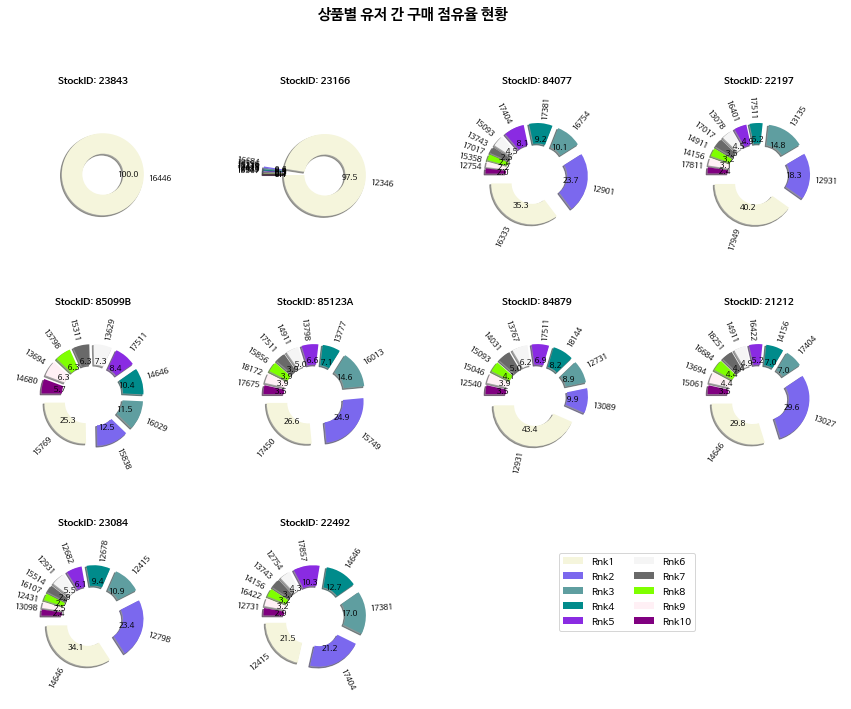

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(13, 13), facecolor='#FFFFFF', sharex=True, sharey=True);
for axi in [2, 3]:
    fig.delaxes(ax= axes[2, axi])

'''
    * Main Variables
        ☑️  active_stock
            : 판매량 데이터를 중심으로 상위 10개 상품의 코드를 저장합니다. 이 코드들은 판매(구매)량이 가장 높은 상품들로, 본 분석의 주요 대상이 됩니다.
        ☑️ top_n
            : 각 상품별 구매한 고객 수의 최대치를 계산하고, 이를 기반으로 차트에 표시할 고객 수를 결정합니다. [최대 10명까지 표시 가능.]
'''
_, c_rank = zip(*matplotlib.colors.cnames.items())
pon = 10
max_id_len = max([len(_df1[_df1.StockCode == x].CustomerID.unique()) for x in active_stock])
if max_id_len > pon:
    top_n = 10
else:
    top_n = max_id_len

random.seed(2001); c_rank = random.sample(c_rank, top_n)
i = 0
for st_c in active_stock:
    sorted = _df1[_df1.StockCode == st_c].groupby('CustomerID').Quantity.sum()
    if len(sorted) > top_n:
        n = top_n
    else:
        n = len(sorted)

    c_rankSUB = c_rank[ :n]
    ax  = axes[i // 4, i % 4]
    row = sorted.sort_values(ascending=False).head(n)
    ax.pie(
        row, labels = pd.Series(row.index).apply(lambda x: str(int(x))),
        colors=c_rankSUB,
        autopct = '%4.1f',
        textprops={'fontsize': 8},
        radius = .6,
        startangle= 180,
        wedgeprops=dict(width=.3),
        shadow = True,
        rotatelabels=True,
        explode = [float(0.15) for x in range(n)]
    )
    ax.set_title(f"StockID: {st_c}", fontweight='bold', fontsize=10)
    ax.set_ylabel("")

    legend = plt.legend([f'Rnk{x}' for x in range(1, 11)],
                        bbox_to_anchor=(1.9, .9),
                        loc='upper left',
                        ncol=2,
                        prop={'size': 10},
                        fancybox=True)

    i += 1
fig.subplots_adjust(wspace=.3)
title = fig.suptitle('상품별 유저 간 구매 점유율 현황', y=.95, fontweight='bold', fontsize=15)
plt.subplots_adjust(bottom=0.3)

In [49]:
def calculateIQRThresholds(scaledValues, target): # 스케일된 구매 빈도 데이터의 사분위 범위(IQR)를 기반으로 원래 구매 빈도의 최소값과 최대값을 계산합니다.
    '''
        ☑️ scaledValues: 각 튜플이 고객 ID와 스케일된 구매 빈도를 포함하는 리스트입니다.
    '''
    scaled = copy.copy(scaledValues)
    customerId, values = zip(*(scaled))
    q1_to_q3_range = [i for i in values if np.quantile(values, 0.25)<i<np.quantile(values, 0.75)]

    bulk_buyer_iqr_min_freq = inverseMinMaxScaler(min(q1_to_q3_range), min(target), max(target))
    bulk_buyer_iqr_max_freq = inverseMinMaxScaler(max(q1_to_q3_range), min(target), max(target))

    return bulk_buyer_iqr_min_freq, bulk_buyer_iqr_max_freq

def minMaxScaler(x, all): # 주어진 데이터 범위에서 값을 0과 1 사이로 스케일링합니다.
    '''
        ☑️ x: 스케일링할 특정 값
        ☑️ all: 전체 데이터 집합으로, 최소값과 최대값을 계산할 때 사용됩니다.
    '''
    return (x - min(all)) / (max(all) - min(all))

def inverseMinMaxScaler(scaled_value, min_val, max_val): # 주어진 스케일된 값과 원본 데이터의 최소값 및 최대값을 사용하여 원래의 단위로 계산합니다.
    '''
        ☑️ scaled_value: 스케일링된 값 (0과 1 사이)
        ☑️ min_val: 원본 데이터의 최소값
        ☑️ max_val: 원본 데이터의 최대값
    '''
    return scaled_value * (max_val - min_val) + min_val

def visDistribution(SD, legend_label, annot_offset=1): # 구매 빈도 분포를 시각화하는 함수입니다.
    global scaledValues, bulk_buyers
    '''
        ☑️ SD: 시각화할 시리즈 데이터
        ☑️ legend_label: 그래프의 범례에 표시될 라벨
        ☑️ annot_offset: 주석 텍스트의 수직 오프셋 조정 파라미터

        ☑️ scaledValues: 벌크 구매자들의 스케일된 구매 빈도 또는 재구매까지의 일수를 저장하는 리스트
    '''
    samples = SD.apply(lambda x: minMaxScaler(x,SD))
    h,e = np.histogram(samples, bins=100, density=True)
    x = np.linspace(e.min(), e.max())

    plt.figure(figsize=(6,8))
    plt.bar(e[:-1], h, width=np.diff(e), ec='k', align='edge')

    kde = sts.gaussian_kde(samples)
    plt.plot(x, kde.pdf(x), c='C1', lw=2)

    resamples = np.random.choice((e[:-1] + e[1:])/2, size=len(samples)*5, p=h/h.sum())
    rkde = sts.gaussian_kde(resamples)

    plt.plot(x, rkde.pdf(x), '--', c='C3', lw=3, label=legend_label)

    bulk_buyers = sum(list(map(lambda x: list(_df1[_df1['StockCode'] == x].sort_values(by='Quantity', ascending=False).head(3).CustomerID), active_stock)), [])
    bulk_buyers = list(set(bulk_buyers))
    customer_purchase_activity_map = {}
    vline_added = False

    scaledValues = []
    for i, c_id in enumerate(set(bulk_buyers)):
        series = SD[SD.index == bulk_buyers[i]]
        if series.empty: continue
        freq = series.values[0]
        X = minMaxScaler(freq, SD)
        scaledValues.append((c_id,X))
        if not vline_added:
            plt.axvline(x=X, color='#800080', linestyle='dotted', alpha=0.1, label='Bulk Buyer Threshold')
            vline_added = not vline_added
        else:
            plt.axvline(x=X, color='#800080', linestyle='dotted', alpha=0.1)

        y_position = plt.ylim()[1] * 0.3; offset = annot_offset
        y_position = y_position + i * ((y_position/len(bulk_buyers))+offset)
        plt.annotate(str(c_id),
                    xy=(X, y_position),
                    xytext=(X + 0.01, y_position),
                    arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle='arc3,rad=.5'),
                    fontsize=8)

    plt.legend(fontsize=8)
    xlab = legend_label.split(' KDE')[0].lower(); plt.xlabel(xlab)
    plt.ylabel('Density')

    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)

    plt.title(f'{legend_label} Distribution with KDE Curve and Resampled KDE', pad=20)
    plt.show()

# 데이터프레임을 복사하고, 날짜 형식을 변경합니다.
'''
    ☑️ _df1: 원본 데이터프레임
    ☑️ timestamp_modified: 날짜 형식이 변경된 데이터프레임 복사본
'''
timestamp_modified = copy.copy(_df1)
timestamp_modified.loc[:, 'InvoiceDate'] = timestamp_modified.InvoiceDate.apply(lambda x: x.strftime('%Y-%m-%d'))

'''
    ☑️ purchase_frequency: 고객별 구매 빈도수
    ☑️ days_since_last_purchase: 각 고객의 마지막 구매 이후 경과일수
'''
purchase_frequency, days_since_last_purchase = (timestamp_modified.drop_duplicates(['CustomerID', 'InvoiceDate']).groupby('CustomerID')['InvoiceDate'].count(),
                                          timestamp_modified.groupby('CustomerID').apply(lambda x: x.sort_values('InvoiceDate', ascending=True)).reset_index(drop=True))

# 구매 날짜 차이를 계산하고, 첫 구매는 0으로 설정합니다.
'''
    ☑️ time_diff: 구매 간 날짜 차이를 계산한 결과
    ☑️ purchase_interval: 구매 간격을 나타내는 시리즈
'''
time_diff = pd.to_datetime(days_since_last_purchase['InvoiceDate']).diff()

days_since_last_purchase['purchase_interval'] = time_diff.dt.days
days_since_last_purchase['purchase_interval'] = days_since_last_purchase.groupby('CustomerID')['purchase_interval'].transform(lambda x: x.replace(x.iloc[0], 0))
days_since_last_purchase = days_since_last_purchase.set_index('CustomerID').purchase_interval
days_since_last_purchase = days_since_last_purchase[days_since_last_purchase != 0]

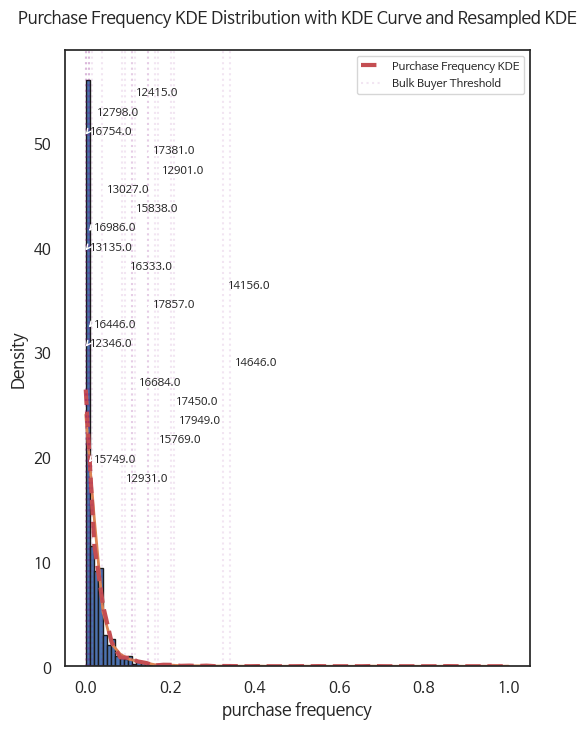

In [50]:
visDistribution(SD = purchase_frequency, legend_label='Purchase Frequency KDE')

In [51]:
bulk_buyer_iqr_min_freq, bulk_buyer_iqr_max_freq = calculateIQRThresholds(scaledValues, purchase_frequency)
print("\n\t\033[94m ☑️ 대량 구매자들의 구매 빈도는 사분위 범위(IQR) 조정 후, 최소 {:.0f}회에서 최대 {:.0f}회까지 분포합니다.\033[0m\n".format(bulk_buyer_iqr_min_freq, bulk_buyer_iqr_max_freq))


	 ☑️ 대량 구매자들의 구매 빈도는 사분위 범위(IQR) 조정 후, 최소 3회에서 최대 20회까지 분포합니다.



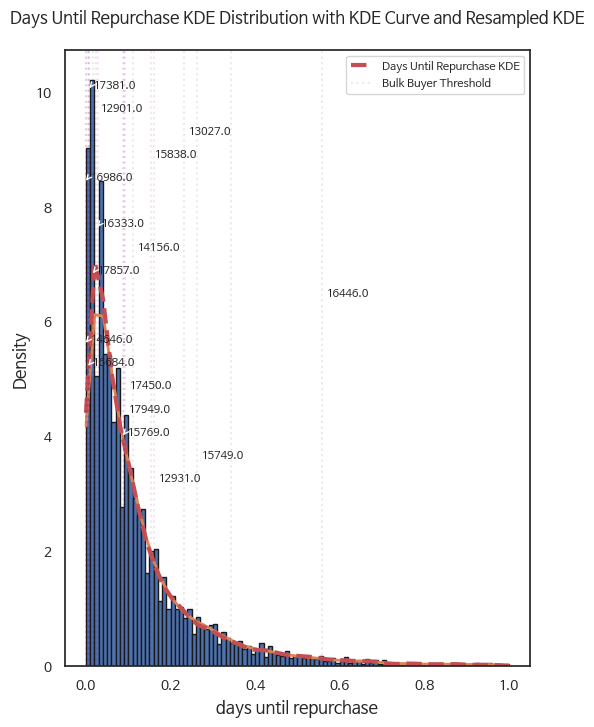

In [52]:
visDistribution(SD = days_since_last_purchase, legend_label='Days Until Repurchase KDE', annot_offset=0.25)

In [53]:
bulk_buyer_iqr_min_days, bulk_buyer_iqr_max_days = calculateIQRThresholds(scaledValues, days_since_last_purchase)
print("\n\t\033[94m ☑️ 대량 구매자들의 다음 구매까지의 일수는 사분위 범위(IQR) 조정 후, 최소 {:.0f}일에서 최대 {:.0f}일까지 분포합니다.\033[0m\n".format(bulk_buyer_iqr_min_days, bulk_buyer_iqr_max_days))


	 ☑️ 대량 구매자들의 다음 구매까지의 일수는 사분위 범위(IQR) 조정 후, 최소 7일에서 최대 57일까지 분포합니다.



In [283]:
def plot_bulk_buyer_price_trends(buyers, plot_data = timestamp_modified, extreme_type = 'max', is_title_updated = False, figsw = 10, figsh = 19):
    ffig, axes = plt.subplots(7, 3, figsize=(figsw, figsh))
    axes = axes.flatten()

    for dfIndex in range(21):
        dfn = plot_data[plot_data['CustomerID'] == buyers[dfIndex]].copy()

        if extreme_type == 'max':
            iso_forest_strict = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
            dfn.loc[:, 'IsolationForest_Strict'] = iso_forest_strict.fit_predict(dfn[['Quantity']])

            dfn.loc[:, 'IF_Outlier_Strict'] = dfn['IsolationForest_Strict'] == -1
            max_quantity_idx = dfn['Quantity'].idxmax()
        elif extreme_type == 'min':
            dbscan_strict = DBSCAN(eps=10, min_samples=2)
            dfn.loc[:, 'dbscan_Strict'] = dbscan_strict.fit_predict(dfn[['Quantity']])

            dfn.loc[:, 'IF_Outlier_Strict'] = dfn['dbscan_Strict'] == -1
            max_quantity_idx = dfn['Quantity'].idxmin()
        else:
            raise ValueError("extreme_type should be either 'max' or 'min'")

        dfn.loc[:, 'DateOrdinal'] = pd.to_datetime(dfn['InvoiceDate']).apply(lambda x: x.toordinal())
        lowess_fitted = lowess(dfn['Quantity'], dfn['DateOrdinal'], frac=0.5)

        dates_for_loess = [str(pd.Timestamp.fromordinal(int(date)).strftime('%Y-%m-%d')) for date in lowess_fitted[:, 0]]

        ax = axes[dfIndex]
        ax.set_title(f'CustomerID: {int(buyers[dfIndex])}', fontsize=8)
        ax.scatter(dfn['InvoiceDate'], dfn['Quantity'],
                    c=dfn.apply(lambda row: 'crimson' if row.name == max_quantity_idx else ('purple' if row['IF_Outlier_Strict'] else 'b'), axis=1),
                    s=dfn.apply(lambda row: 30 if row.name == max_quantity_idx else (20 if row['IF_Outlier_Strict'] else 2), axis=1),
                    alpha=dfn.apply(lambda row: 1 if row.name == max_quantity_idx else (1 if row['IF_Outlier_Strict'] else 0.1), axis=1),
                    label='Actual Quantity')

        ax.plot(dates_for_loess, lowess_fitted[:, 1], color='g', label='LOESS Trend Line',
                linestyle='--', linewidth=2, alpha=0.5)

        if extreme_type == 'max':
            for annot, d, q in dfn[dfn['IF_Outlier_Strict']].loc[:, ['Description', 'InvoiceDate', 'Quantity']].values:
                ax.annotate(annot, (d, q), fontsize=7, color='#808080')
        else:
            most_canceled_item = dfn.loc[max_quantity_idx]['Description']
            for annot, d, q in dfn[dfn['IF_Outlier_Strict']].loc[:, ['Description', 'InvoiceDate', 'Quantity']].values:
                if most_canceled_item == annot:
                    ax.annotate(annot, (d, q), fontsize=7, color='#808080')

        if dfIndex == 0:
            ax.set_ylabel('Quantity')

        ax.grid(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', rotation=-45, labelsize=6)

        if sum(dfn['IF_Outlier_Strict']) > 0:
            date, description = dfn[dfn['IF_Outlier_Strict']].nlargest(1, 'Quantity').loc[:, ['InvoiceDate', 'Description']].values[0]
        else:
            if extreme_type == 'max':
                date, description = dfn.nlargest(1, 'Quantity').loc[:, ['InvoiceDate', 'Description']].values[0]
            else:
                date, description = dfn.nsmallest(1, 'Quantity').loc[:, ['InvoiceDate', 'Description']].values[0]
        price_trend = plot_data[plot_data['Description'] == description].sort_values(by='InvoiceDate')

        dateIndex = np.where(price_trend['InvoiceDate'] == date)[0][0]
        price_trend = price_trend.iloc[max(0, dateIndex-10):min(len(price_trend), dateIndex+10), :]

        sub_axes = ax.inset_axes([0.7, 0.1, 0.28, 0.28])
        sub_axes.plot(price_trend['InvoiceDate'], price_trend['UnitPrice'], color='crimson', linestyle='--', linewidth=1)
        sub_axes.set_xticks([])
        sub_axes.set_xticklabels([])
        sub_axes.tick_params(axis='y', rotation=-45, labelsize=6)

        if dfIndex == 0:
            sub_axes.set_ylabel('Price Trend', fontsize=6)

        for spine in sub_axes.spines.values():
            spine.set_alpha(0.3)
        sub_axes.patch.set_alpha(0.5)
        for line in sub_axes.get_lines():
            line.set_alpha(0.3)

    if not is_title_updated: plt.suptitle('대량 구매자 구매 이상치 탐지와 상품 가격 변동의 상관관계 분석', fontsize=12)
    else: plt.suptitle(is_title_updated, fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

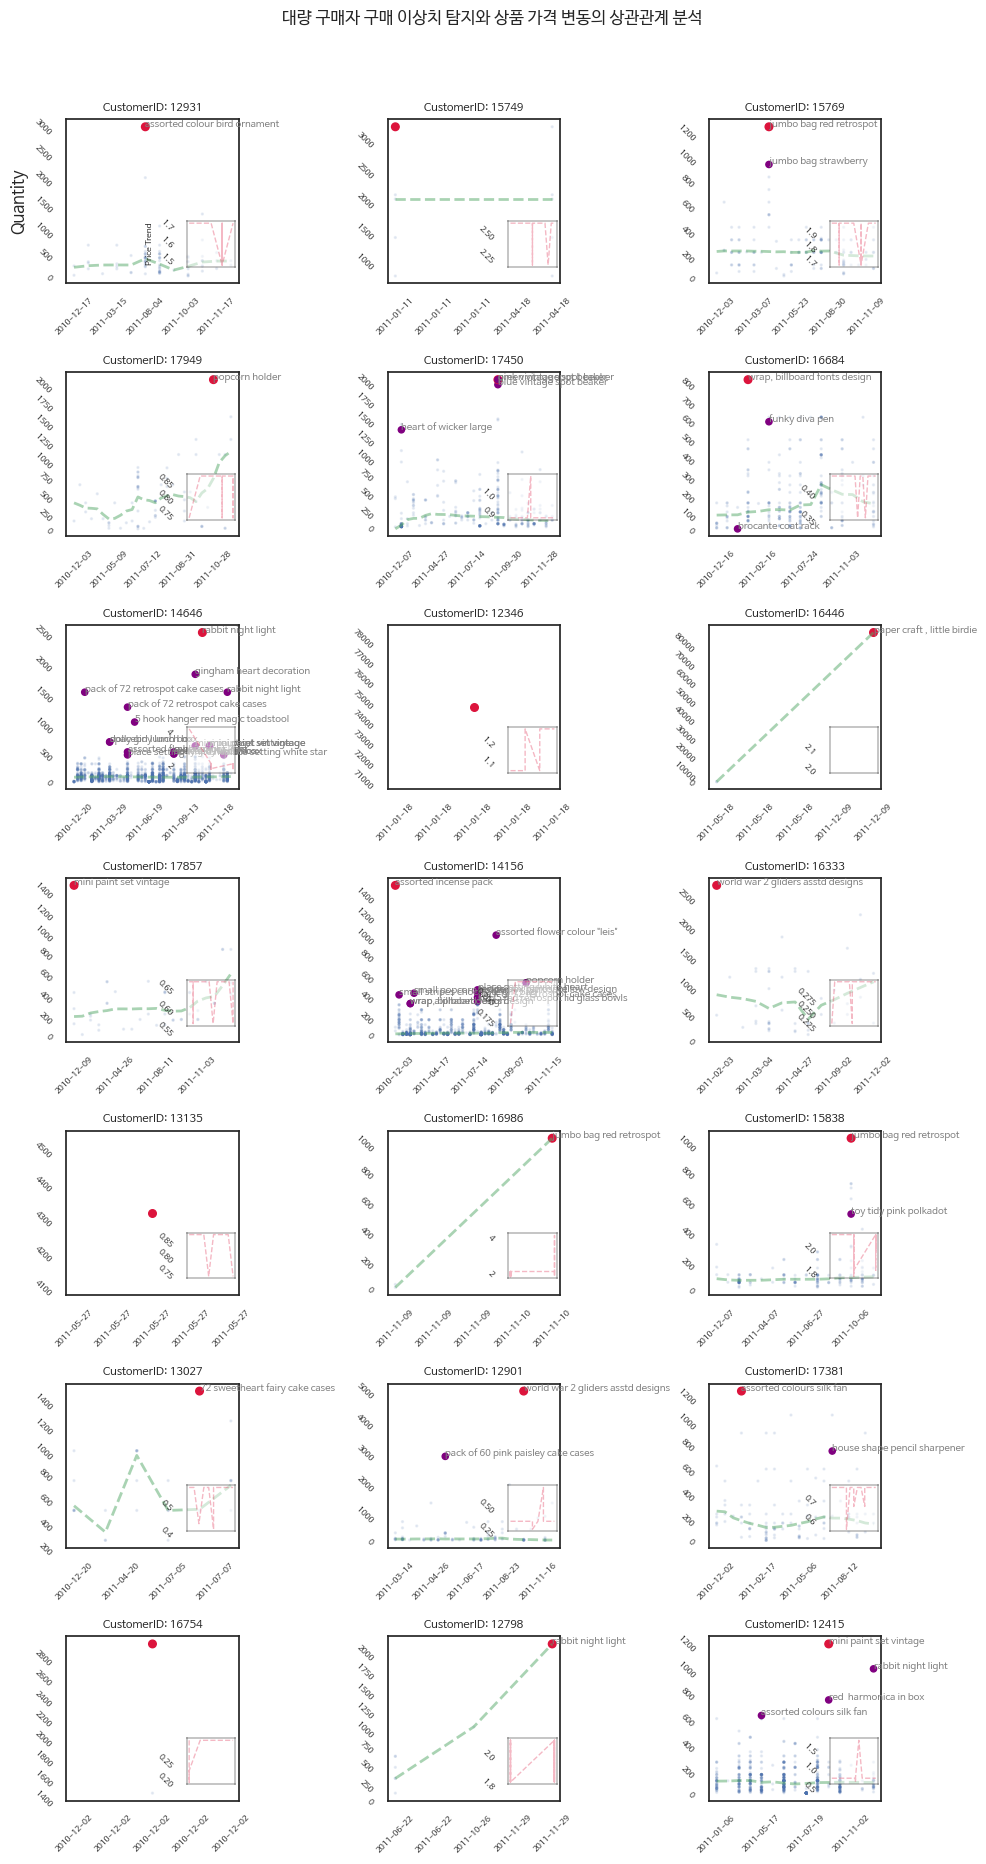

In [216]:
plot_bulk_buyer_price_trends(buyers = bulk_buyers)

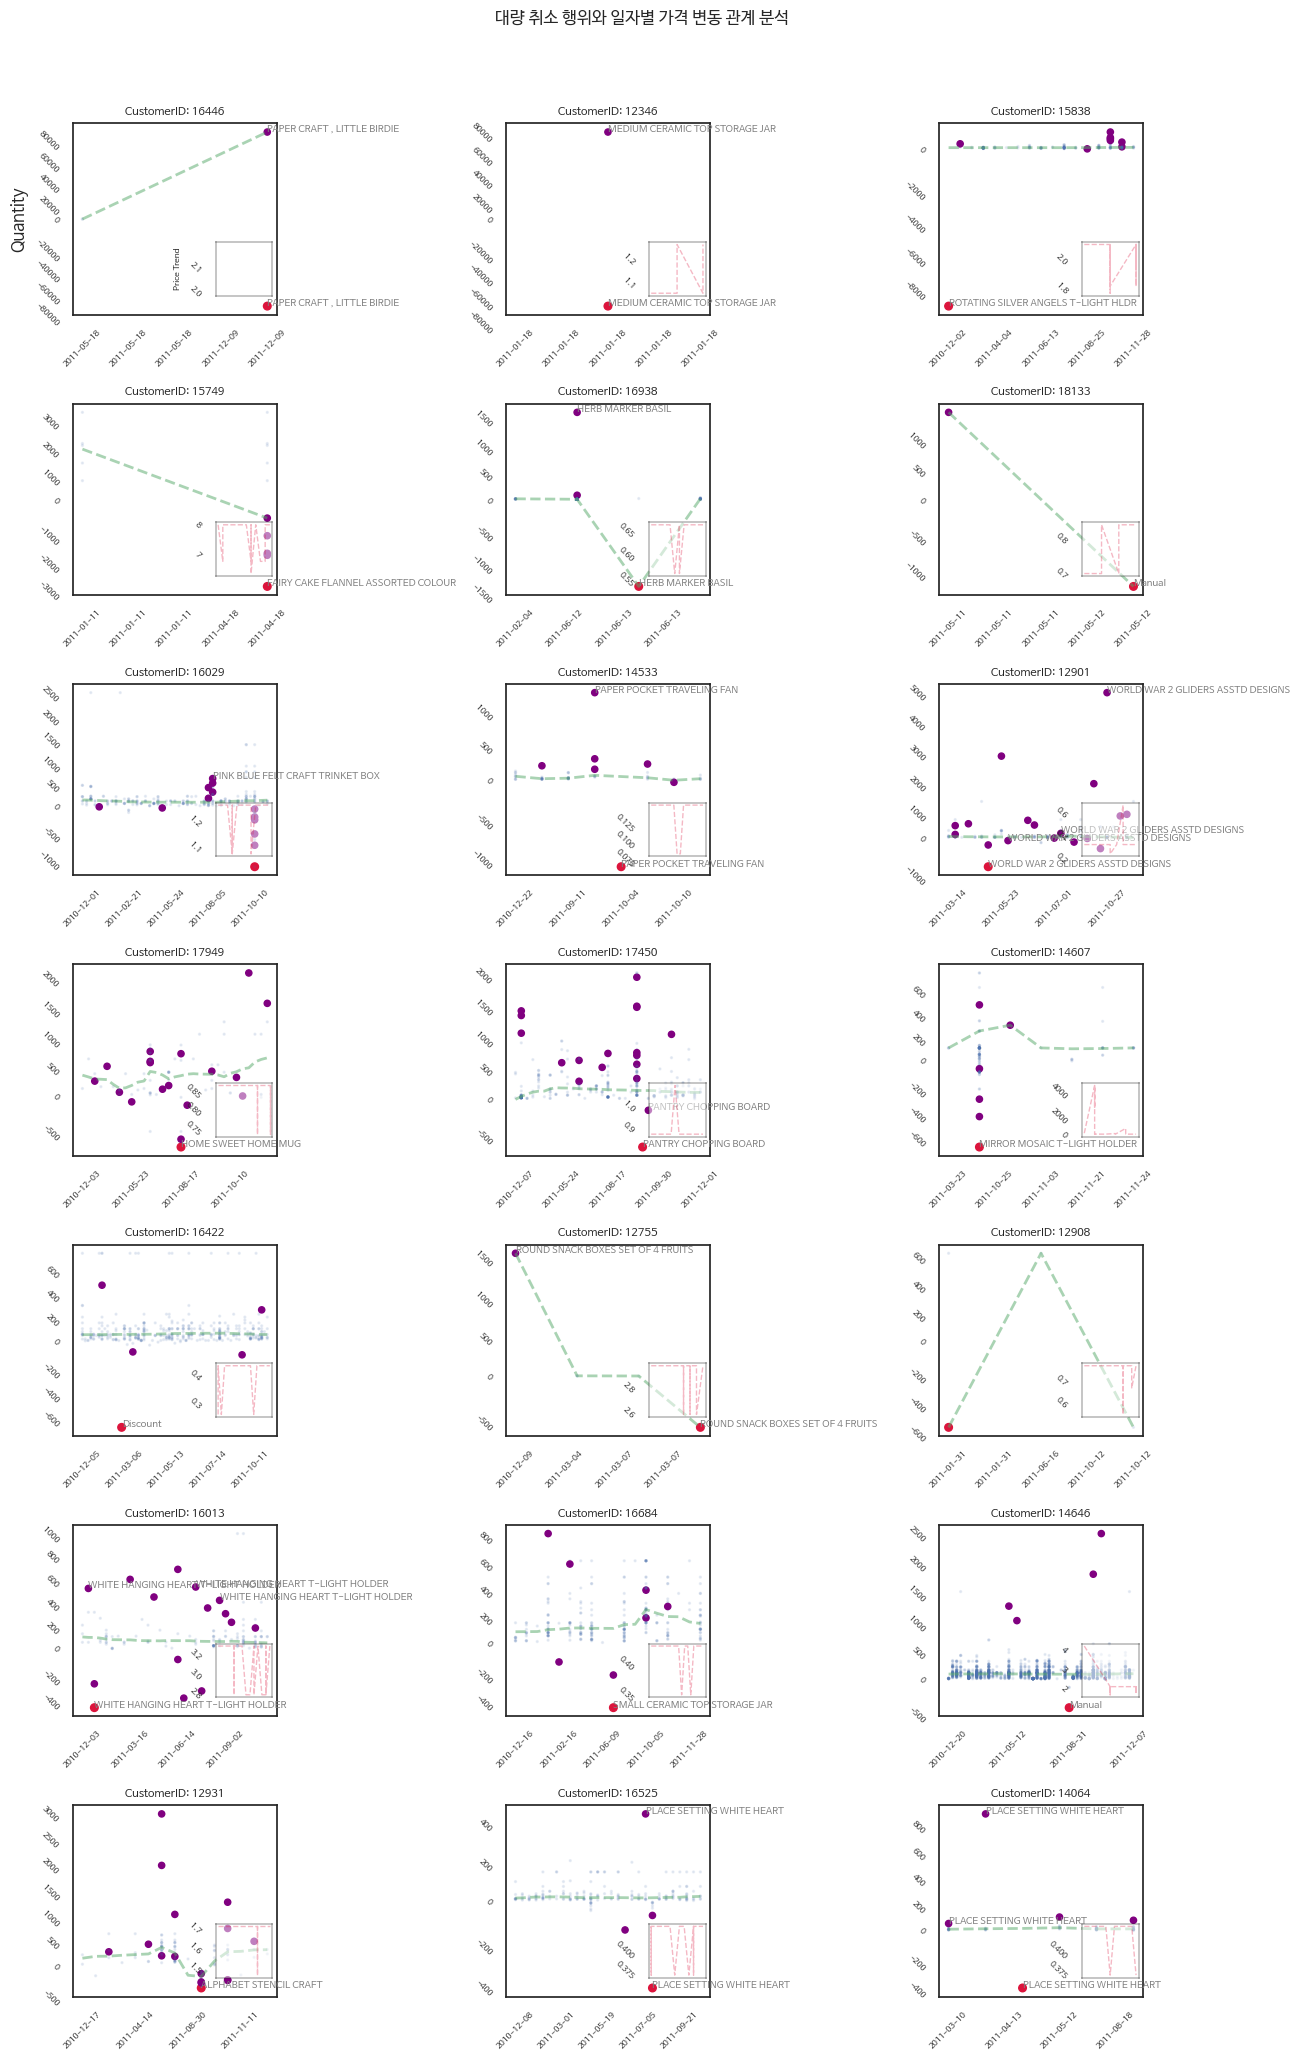

In [284]:
timestamp_modified_cancel_group = copy.copy(df1)
timestamp_modified_cancel_group.loc[:, 'InvoiceDate'] = timestamp_modified_cancel_group.InvoiceDate.apply(lambda x: x.strftime('%Y-%m-%d'))

high_volume_cancellers = timestamp_modified_cancel_group[timestamp_modified_cancel_group['Cancelled'] == 1].sort_values(by='Quantity')

i, topn = 0, 21
dfs, ids = [], []
while len(dfs) < topn:
    data = high_volume_cancellers.iloc[[i]]
    id = data['CustomerID'].values[0]
    if id not in ids:
        ids.append(id)
        dfs.append(data)
    i += 1

high_volume_cancellers = pd.concat(dfs, axis=0).CustomerID.tolist()

plot_bulk_buyer_price_trends(
    buyers = high_volume_cancellers,
    plot_data = timestamp_modified_cancel_group,
    extreme_type = 'min',
    is_title_updated = '대량 취소 행위와 일자별 가격 변동 관계 분석',
    figsw = 13,
    figsh = 21
    )

In [ ]:
# 고객 분류 먼저 다시 진행하여 시각화 진행

In [353]:
colIdx = [i for i, x in enumerate(list(df1.columns)) if x in ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID']]
cancelled_orders_filtered = df1[df1['Cancelled'] == 1].sort_values(by='Quantity').iloc[:, colIdx].drop_duplicates()

# 첫 번째 대량 취소 행의 정보를 추출
d, q, i, p, c = cancelled_orders_filtered.iloc[6].values

# 이후 동일 고객이 동일한 상품을 다시 구매한 경우를 필터링
subsequent_purchases = df1[
    (df1['InvoiceDate'] > i) &
     (df1['Quantity'] > 0) &
      (df1['Description'] == d) &
       (df1['CustomerID'] == c)
       ]

subsequent_purchases

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Inv_date,Cancelled
224420,556523,22920,HERB MARKER BASIL,15,2011-06-13 11:24:00,0.65,16938.0,United Kingdom,2011-06-13,0.0


In [354]:
d, q, i, p, c

('HERB MARKER BASIL', -1515, Timestamp('2011-06-13 11:21:00'), 0.55, 16938.0)

,median,max,std,mean,min
Segment_grp,,,,,
about_to_sleep,54.0,73.0,10.9,54.7,35.0
at_Risk,140.0,374.0,68.4,155.9,74.0
cant_loose,110.0,373.0,66.0,135.8,74.0
champions,6.0,15.0,3.8,7.0,2.0
hibernating,221.5,375.0,91.5,219.4,74.0
loyal_customers,30.0,73.0,16.0,34.8,16.0
need_attention,54.5,73.0,11.5,54.0,35.0
new_customers,8.0,15.0,4.1,8.1,2.0
potential_loyalists,19.0,34.0,9.5,18.1,2.0

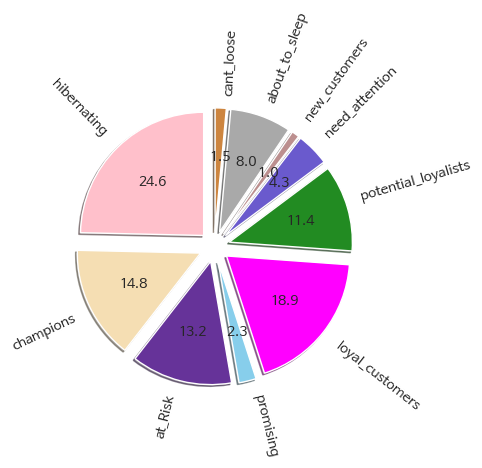

In [76]:
def print_dataframe_with_font_size(df, font_size):
    styles = [
        {'selector': 'td, th', 'props': [('font-size', f'{font_size}px'), ('padding-left', '8px'), ('padding-right', '8px'), ('line-height', '1.4'), ('padding-top', '1px'), ('padding-bottom', '1px')]},
        {'selector': '.row_heading, .index_name', 'props': [('text-align', 'right'), ('padding-right', '20px'), ('line-height', '1.4')]}
    ]
    formatted_df = df.style.format(
        '{:.1f}',
        na_rep='NaN'
    ).set_table_styles(styles)
    formatted_df = formatted_df.set_properties(
        **{'background-color': '#F9F9F9', 'color': '#3f51b5', 'text-align': 'right', 'font-style': 'italic'},
        subset=pd.IndexSlice[:, df.columns]
    )
    html = formatted_df.render()
    return html

T_day = pd.to_datetime(max(_df1['InvoiceDate'])) + timedelta(days=2)

_df1['TotalPrice'] = _df1['UnitPrice'] * _df1['Quantity']
RFM = _df1.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (T_day - x.max()).days,
    'InvoiceNo'  : lambda x: x.nunique(),
    'TotalPrice' : lambda x: x.sum()})

RFM = RFM.reset_index()
RFM.columns = ['ID', 'R', 'F', 'M']

RFM['R_scr'] = pd.qcut(RFM['R'], 5, labels=list(range(1, 6))[::-1])
RFM['F_scr'] = pd.qcut(RFM['F'].rank(method='first'), 5, labels=list(range(1, 6)))
RFM['M_scr'] = pd.qcut(RFM['M'], 5, labels=list(range(1, 6)))

str_typ = lambda colN: RFM[colN].astype(str)
RFM['RF (Segment)'] = str_typ('R_scr') + str_typ('F_scr')
RFM['RFM'] = str_typ('R_scr') + str_typ('F_scr') + str_typ('M_scr')

seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}
RFM['Segment_grp'] = RFM['RF (Segment)'].replace(seg_map, regex=True)

def graph_to_base64():
    _, c_rank = zip(*matplotlib.colors.cnames.items())
    random.seed(11)
    rfm_grp_colors = random.sample(c_rank, 10)
    explodes = [0.25 for _ in range(10)]

    plt.figure(figsize=(2, 2))
    fig = RFM['Segment_grp'].value_counts(sort=False).plot.pie(colors=rfm_grp_colors,
                                                               textprops={'fontsize': 10},
                                                               autopct='%4.1f',
                                                               startangle=90,
                                                               radius=2,
                                                               rotatelabels=True,
                                                               shadow=True,
                                                               explode=explodes)
    plt.ylabel("")

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    buf.close()

    plt.close()
    return img_base64

criteria = ['R', 'F', 'M']
target_name = {'R':'Recency', 'F':'Frequency', 'M':'Monetary'}
RFM_parameters = [RFM.loc[:, ['R', 'F', 'M', 'Segment_grp']].groupby('Segment_grp').agg({'min', 'max', 'std', 'mean', 'median'})[x] for x in criteria]
html_str = f"""
<div style='display: flex; flex-direction: column;'>
    <div style='display: flex; justify-content: space-around; margin-bottom: 20px;'>
        <div style='margin-right: 20px;'>
            <h3 style='color: #804EFF;'>Summary of '{target_name['R'][0]}'{target_name['R'][1:]} Statistics</h3>
            {print_dataframe_with_font_size(RFM_parameters[0], 12)}
        </div>
        <div style='margin-right: 20px;'>
            <h3 style='color: #804EFF;'>Summary of '{target_name['F'][0]}'{target_name['F'][1:]} Statistics</h3>
            {print_dataframe_with_font_size(RFM_parameters[1], 12)}
        </div>
        <div style='margin-right: 20px;'>
            <h3 style='color: #804EFF;'>Summary of '{target_name['M'][0]}'{target_name['M'][1:]} Statistics</h3>
            {print_dataframe_with_font_size(RFM_parameters[2], 12)}
        </div>
    </div>
    <div style='display: flex; justify-content: center; margin-top: 20px;'>
        <div>
            <h3 style='color: #A5A2A2;'>"Customer Segmentation Analysis Using RFM Model"</h3>
            <img src="data:image/png;base64,{graph_to_base64()}" alt="Customer Segmentation Pie Chart" />
        </div>
    </div>
</div>
"""

from IPython.display import display, HTML; display(HTML(html_str));

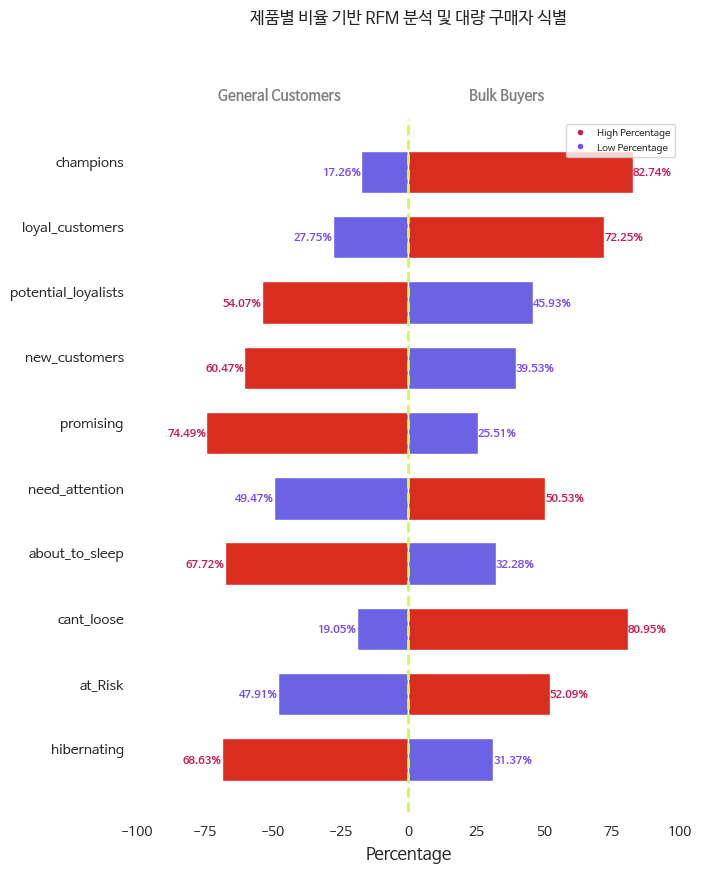

In [ ]:
top_selling_stock_codes = _df1.groupby('StockCode').agg(
    {
        'Quantity':'sum'
        }
    ).sort_values(by='Quantity', ascending=False).index

_df1['StockCode_cat'] = pd.Categorical(_df1['StockCode'], categories=top_selling_stock_codes, ordered=True)
df1_sorted_by_top_selling = _df1.sort_values(by='StockCode_cat').reset_index(drop=True)

grouped_iterator = iter(df1_sorted_by_top_selling.sort_values(['StockCode', 'Inv_date', 'Quantity'], ascending=False).groupby('StockCode'))
auxilary_stack = []
while True:
    try:
        product_id, sampled = next(grouped_iterator)

        # Local Outlier Factor (LOF)를 사용하여 각 제품별로 구매 수량에 대한 이상치(대량 구매자)를 탐지합니다.
        lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
        sampled['LOF_outlier'] = lof.fit_predict(sampled[['Quantity']])
        sampled['LOF_outlier'] = sampled['LOF_outlier'] == -1

        # 이상치로 탐지된 고객 ID를 수집하여 대량 구매자 목록을 만듭니다.
        CustomerIDs = sampled['CustomerID'][sampled['LOF_outlier']].unique()
        auxilary_stack += list(CustomerIDs)

    except ValueError:
        pass
    except StopIteration:
        break

# 중복을 제거하여 최종 대량 구매자 ID 목록을 생성합니다.
lof_detected_bulk_buyers_ids = list(set(auxilary_stack))

# 대량 구매자 정보를 RFM 데이터와 결합하여 각 고객의 RFM 세그먼트 그룹을 분류하고, 이상치 여부를 표시합니다.
bulk_buyers_rfm_levels = pd.merge(pd.DataFrame(map(lambda x: [x, True], lof_detected_bulk_buyers_ids), columns = ['ID', 'Outliers']),
                                  RFM, how='right', on='ID').sort_values('Segment_grp')
bulk_buyers_rfm_levels['Outliers'] = bulk_buyers_rfm_levels['Outliers'].fillna(False)

"""
    ⤹ 미리 설정해둔 RFM 세그먼트 그룹에서 현재 높은 가치를 제공하는 고객 순으로 정보를 재정렬합니다. 일반적으로 고객의 가치는 다음과 같은 순서로 정해집니다:
        1. 잠재적으로 높은 가치를 제공할 수 있는 고객.
        2. 현재는 낮은 가치를 제공하지만 유지가 중요한 고객.
        3. 관리가 필요한 위험 고객.
"""
labels = np.char.array(
    [
        'hibernating',
        'at_Risk',
        'cant_loose',
        'about_to_sleep',
        'need_attention',
        'promising',
        'new_customers',
        'potential_loyalists',
        'loyal_customers',
        'champions'
        ]
    )
color_low, color_high = '#6b63e3', '#DA2D20'; anoot_col_low, anoot_col_high = '#7848F3', '#c71c56'; normal_outlier_groups, colors, txt_colors = {}, {}, [];
for i in range(len(labels)):
    # 각 RFM 세그먼트 그룹별로 일반 고객과 이상치 고객의 비율을 계산합니다.
    subGroupsClassified = bulk_buyers_rfm_levels.loc[bulk_buyers_rfm_levels['Segment_grp'] == labels[i], 'Outliers']
    groupLength = len(subGroupsClassified)
    normal_values = (subGroupsClassified == False).sum()*100/groupLength
    outlier_values = (subGroupsClassified == True).sum()*100/groupLength

    normal_outlier_groups[labels[i]] = (normal_values, outlier_values)
    if outlier_values > normal_values:
        color_map = (color_low, color_high)
        annot_color = (anoot_col_low, anoot_col_high)
    else:
        color_map = (color_high, color_low)
        annot_color = (anoot_col_high, anoot_col_low)
    colors[labels[i]] = color_map
    txt_colors.append(annot_color)

total_length = 100
height, y_position = 13, 10

fig, ax = plt.subplots( figsize=(7,9) )
i = 0
for group, (left_percentage, right_percentage) in normal_outlier_groups.items():
    left_length = total_length * (left_percentage / 100)
    right_length = total_length * (right_percentage / 100)

    ax.broken_barh([(-left_length, left_length)], (y_position, height), facecolors=colors[group][0])
    ax.text(-left_length, y_position + height / 2, f'{left_percentage:.2f}%', va='center', ha='right', size=8, color=txt_colors[i][0], fontweight='bold')

    ax.broken_barh([(0, right_length)], (y_position, height), facecolors=colors[group][1])
    ax.text(right_length, y_position + height / 2, f'{right_percentage:.2f}%', va='center', ha='left', size=8, color=txt_colors[i][1], fontweight='bold')

    y_position += 20
    i += 1

ax.text(-total_length + 30, y_position + 10, 'General Customers', va='center', ha='left', fontsize=10, color='black', fontweight='bold', alpha=0.5)
ax.text(total_length - 50, y_position + 10, 'Bulk Buyers', va='center', ha='right', fontsize=10, color='black', fontweight='bold', alpha=0.5)

low_value_patch = plt.Line2D([0], [0], marker='o', color='w', label='Low Percentage', markerfacecolor=anoot_col_low, markersize=5)
high_value_patch = plt.Line2D([0], [0], marker='o', color='w', label='High Percentage', markerfacecolor=anoot_col_high, markersize=5)

ax.axvline(x=0, linewidth=2, linestyle='--', color='#C9FF4D')

ax.set_xlabel('Percentage')
ax.set_xlim(-total_length, total_length)

ax.set_yticklabels(labels)
ax.set_yticks(list(range(20, 20*11, 20)))

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.grid(False)

ax.set_title('제품별 비율 기반 RFM 분석 및 대량 구매자 식별', pad=70)
ax.legend(handles=[high_value_patch, low_value_patch], loc='upper right', fontsize=7)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

In [ ]:
def visualize_sales_distribution(df, quantile, range_size=100, color_palette="Set2"):
    global product_sales_summary, unique_descriptions

    # 제품 설명별 총 판매량을 계산하여 내림차순으로 정렬
    product_sales_summary = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

    # 지정된 분위수(quantile)에 해당하는 판매량을 계산
    product_sales_quantile = np.quantile(product_sales_summary, quantile)

    # 해당 분위수 이상의 판매량을 가진 제품 중 가장 낮은 판매량의 제품명을 추출
    product_name_quantile = product_sales_summary[product_sales_summary > product_sales_quantile].tail(1).index[0]

    df_sorted_by_top_selling = df.sort_values(by='StockCode_cat').reset_index(drop=True)
    unique_descriptions = df_sorted_by_top_selling['Description'].drop_duplicates().reset_index(drop=True)

    # 지정된 분위수의 제품이 포함된 인덱스를 계산
    start_index_quantile = (unique_descriptions == product_name_quantile).idxmax()
    end_index_quantile = start_index_quantile - range_size if quantile < 0.5 else start_index_quantile + range_size

    # 시작 및 종료 인덱스를 사용하여 설명 필터링
    description_filtered = unique_descriptions.iloc[min(start_index_quantile, end_index_quantile):max(start_index_quantile, end_index_quantile)]

    df_filtered_by_description = df_sorted_by_top_selling[df_sorted_by_top_selling['Description'].isin(description_filtered)]

    sns.set_theme(
        style="white",
        rc={
            "axes.facecolor": (0, 0, 0, 0),
            "axes.linewidth": 1
        }
    )

    palette = sns.color_palette(color_palette, 12)

    g = sns.FacetGrid(df_filtered_by_description, palette=palette, row='Description', hue='Description', aspect=8, height=0.5)
    g.map_dataframe(sns.kdeplot, x="Quantity", fill=True, alpha=1)  # KDE Plot
    g.map_dataframe(sns.kdeplot, x="Quantity", color='black')

    def label(x, color, label):
        ax = plt.gca()
        ax.text(-0.3, .5, label, color='black', fontsize=8,
                ha="left", va="center", transform=ax.transAxes)

    for ax in g.axes.flat:
        ax.tick_params(axis='x', which='major', labelsize=8)
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)

    g.set_titles("")
    g.despine(left=True)
    g.map(label, "Quantity")
    g.fig.subplots_adjust(hspace=-.2)
    g.set(yticks=[], ylabel="", xlabel="Q")

    fontprop = fm.FontProperties(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    stat0 = '이하' if quantile < 0.5 else '이상'
    stat1 = '하위' if quantile < 0.5 else '상위'
    plt.text(0.5, 1, f'{stat1} {int(quantile*100)}% {stat0}의 판매량을 기록한 제품의 판매량 분포',
            horizontalalignment='center',
            verticalalignment='center',
            transform=plt.gcf().transFigure,
            fontweight='bold', fontsize=10, fontproperties=fontprop)

    plt.show()

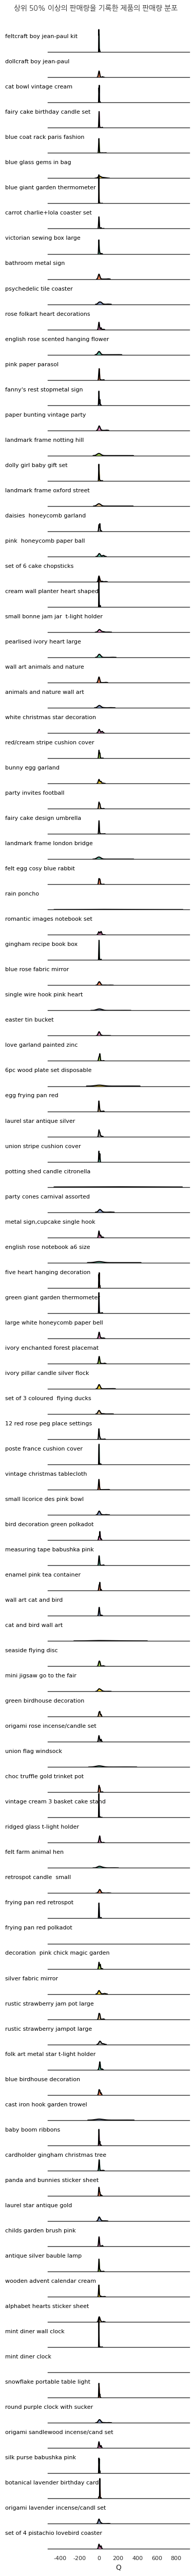

In [ ]:
visualize_sales_distribution(_df1, quantile=0.5)

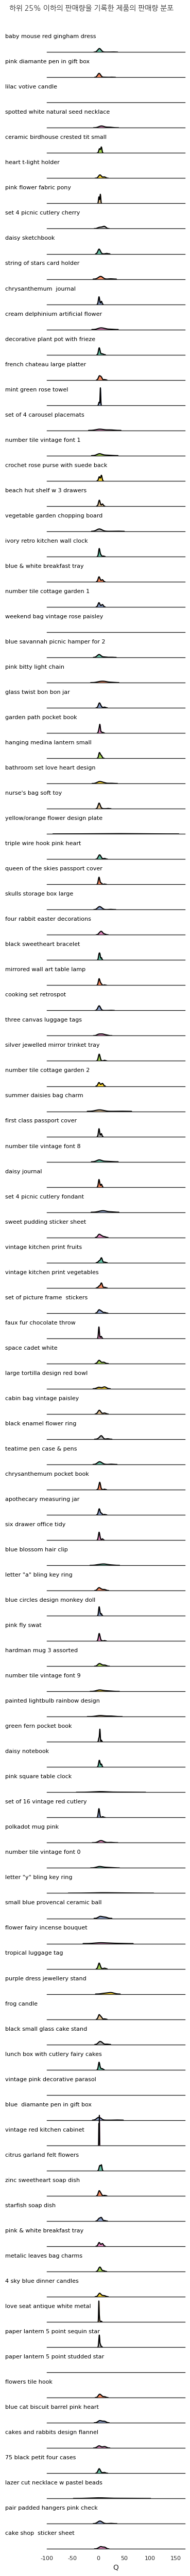

In [ ]:
visualize_sales_distribution(_df1, quantile=0.25)

In [ ]:
# 특정 백분위수와 해당 백분위수를 초과하는 마지막 항목의 인덱스를 반환하는 함수
def get_quantile_and_last_index(product_sales_summary, quantile):
    quantile_value = np.quantile(product_sales_summary, quantile)
    last_high_sales_index = product_sales_summary[product_sales_summary > quantile_value].tail(1).index[0]
    return quantile_value, last_high_sales_index

traces = []
visualization_range = 30

# 상위 25% 판매량에 해당하는 항목의 인덱스를 찾기
quantile_75_index = get_quantile_and_last_index(product_sales_summary, 0.75)[1]
start_index_top_selling = (unique_descriptions == quantile_75_index).idxmax()

# 상위 25% 판매량 항목들의 박스 플롯 데이터 추가
for description in unique_descriptions.iloc[start_index_top_selling : start_index_top_selling + visualization_range]:
    quantities = _df1[_df1.Description == description].Quantity.values.tolist()
    traces.append(go.Box(y=quantities, x=['Top Selling Cluster']*len(quantities), name="Top Selling", marker_color=color_high, yaxis='y1'))

# 하위 25% 판매량에 해당하는 항목의 인덱스를 찾기
quantile_25_index = get_quantile_and_last_index(product_sales_summary, 0.25)[1]
start_index_low_selling = (unique_descriptions == quantile_25_index).idxmax()

# 하위 25% 판매량 항목들의 박스 플롯 데이터 추가
for description in unique_descriptions.iloc[start_index_low_selling - visualization_range : start_index_low_selling]:
    quantities = _df1[_df1.Description == description].Quantity.values.tolist()
    traces.append(go.Box(y=quantities, x=['Low Selling Cluster']*len(quantities), name="Low Selling", marker_color=color_low, yaxis='y2'))


layout = go.Layout(
    title=dict(
        text='판매량 상위 25%와 하위 25% 품목의 분포 차이 비교와 대조',
        y=0.95,
        yanchor='top'
    ),
    yaxis=dict(title="Q (Top Selling Cluster)", zeroline=False, side='left'),
    yaxis2=dict(title="Q (Low Selling Cluster)", zeroline=False, side='right', overlaying='y'),
    boxmode="group",
    boxgap=0.1,
    boxgroupgap=0.5,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    hovermode='x unified',
    height=800,
    width=900,
    margin=dict(
        l=120,
        r=120,
        t=120
    )
)

fig = go.Figure(data=traces, layout=layout)
fig.show(renderer="colab")


In [ ]:
def analyze_customer_purchasing_behavior(description_forTest = 'small popcorn holder'):

    """
    제품 설명에 따라 데이터를 필터링하고 정렬.

    :param df: 데이터프레임
    :param description: 분석할 제품 설명
    :return: 필터링 및 정렬된 데이터프레임
    """
    filtered_product_data = _df1[_df1['Description'] == description_forTest].sort_values(by=['CustomerID', 'Inv_date'])

    """
    가장 이른 송장 날짜와 가장 늦은 송장 날짜를 찾습니다.

    :param filtered_data: 필터링된 데이터프레임
    :return: 가장 이른 송장 날짜와 가장 늦은 송장 날짜
    """
    earliest_invoice_date = filtered_product_data.sort_values(by='Inv_date')['Inv_date'].min()
    latest_invoice_date = filtered_product_data.sort_values(by='Inv_date')['Inv_date'].max()

    """
    가장 이른 송장 날짜와 가장 늦은 송장 날짜 사이의 모든 날짜를 생성합니다.

    :param start_date: 가장 이른 송장 날짜
    :param end_date: 가장 늦은 송장 날짜
    :return: 날짜 범위
    """
    date_range = pd.date_range(start=earliest_invoice_date, end=latest_invoice_date, freq='D')

    """
    고유한 고객 ID를 추출합니다.

    :param filtered_data: 필터링된 데이터프레임
    :return: 고유한 고객 ID 목록
    """
    customer_ids = filtered_product_data['CustomerID'].unique()

    """
    고객별, 날짜별 구매 요약 데이터를 생성합니다.

    :param filtered_data: 필터링된 데이터프레임
    :return: 구매 요약 데이터프레임
    """
    customer_purchase_summary = filtered_product_data.loc[:, ['CustomerID', 'Inv_date', 'Quantity']].groupby(['CustomerID', 'Inv_date'], as_index=False).sum()

    """
    고객 ID와 날짜의 모든 조합을 생성합니다.

    :param customers: 고유한 고객 ID 목록
    :param dates: 날짜 범위
    :return: 고객 ID와 날짜의 모든 조합 데이터프레임
    """
    all_combinations = pd.MultiIndex.from_product([customer_ids, date_range], names=['CustomerID', 'Inv_date']).to_frame(index=False)

    """
    모든 조합과 구매 요약 데이터를 병합하고, 없는 값을 0으로 채웁니다.

    :param all_combinations: 고객 ID와 날짜의 모든 조합 데이터프레임
    :param summary: 구매 요약 데이터프레임
    :return: 병합된 데이터프레임
    """
    merged_data = pd.merge(all_combinations, customer_purchase_summary, on=['CustomerID', 'Inv_date'], how='left').fillna(0)

    # 모든 행에 대해 x_steps 열을 1로 설정
    merged_data['x_steps'] = [1]*len(merged_data)

    # 스케일링 함수 정의
    def scale_feature(x):
        specific_value = np.array([[x]])
        return scaler.transform(specific_value)[0][0]

    """
    각 고객에 대해 MinMaxScaler를 사용하여 Quantity 값을 스케일링합니다.

    :param merged_data: 병합된 데이터프레임
    :param customer_ids: 고유한 고객 ID 목록
    :param original_data: 원본 데이터프레임
    :return: 스케일링이 적용된 데이터프레임
    """
    for customer_id in customer_ids:
        # 특정 고객의 Quantity 값에 대해 스케일러 학습
        scaler = MinMaxScaler()

        # 특정 고객의 Quantity 값을 추출하여 2차원 배열로 변환
        customer_quantities = _df1[_df1['CustomerID'] == customer_id]['Quantity'].values.reshape(-1, 1)

        # 특정 고객의 데이터를 필터링하여 스케일링 적용
        if len(customer_quantities) > 1:
            scaler.fit(customer_quantities)
            filtered_customer_ids = merged_data['CustomerID'] == customer_id
            merged_data.loc[filtered_customer_ids, 'ScaledQuantity'] = merged_data.loc[filtered_customer_ids, 'Quantity'].apply(scale_feature)
        else:
            filtered_customer_ids = merged_data['CustomerID'] == customer_id
            merged_data.loc[filtered_customer_ids, 'ScaledQuantity'] = 1

    # 스케일된 값 중 누락된 값을 -1로 채움
    merged_data['ScaledQuantity'] = merged_data['ScaledQuantity'].fillna(-1)

    merged_data.loc[merged_data['Quantity'] == 0, 'ScaledQuantity'] = 0
    merged_data['ScaledQuantity'] = merged_data['ScaledQuantity'].apply(lambda value: round(value, 1))
    merged_data['CustomerID'] = merged_data['CustomerID'].apply(lambda x: str(int(x)))


    """
    고객별 구매 활동을 시각화합니다.

    :param data: 시각화할 데이터프레임
    :param date_range: 날짜 범위
    :param customer_ids: 고유한 고객 ID 목록
    """

    # 색상 스케일 설정 - ScaledQuantity 값에 따라 색상 변경
    custom_color_scale = [
        [0.0, '#cfe2f3'],
        [0.2, '#8fce00'],
        [0.5, '#ff11ea'],
        [0.7, '#ff943a'],
        [1.0, '#f44336']
    ]

    data = pd.concat([merged_data.iloc[:len(date_range)*5], merged_data.iloc[len(date_range)*-10:]]).reset_index(drop=True)

    fig = px.bar(
        data,
        x="x_steps",
        y="CustomerID",
        color='ScaledQuantity',
        orientation='h',
        hover_data=["Inv_date", "Quantity", "ScaledQuantity"],
        color_continuous_scale=custom_color_scale,
        height=350,
        width=1000,
        title=''
    )

    """
    고객별 피크 구매 날짜를 기반으로 구매 활동을 계산합니다.

    :param merged_data: 고객 구매 데이터가 포함된 병합된 데이터프레임
    :param customer_ids: 분석할 고객들의 고유 ID 목록
    :param days_range: 피크 구매 날짜 주변의 기간(일 단위), 기본값은 7일입니다.
    :return: 전체 최댓값에 해당하는 고객 ID와 유효 구매 활동 수
    """

    # 초기값 설정: 모든 고객에 대해 최댓값을 찾기 위해 루프 외부에서 초기화
    overall_max_activity = (None, 0)  # (CustomerID, max_count)

    for i in range(5):
        # 특정 고객의 최대 구매량을 갖는 인덱스 찾기
        current_customer_id = str(int(customer_ids[i]))
        customer_data = merged_data[merged_data.CustomerID == current_customer_id]
        peak_purchase_index = customer_data['Quantity'].idxmax()

        # 피크 구매 날짜
        peak_purchase_date = merged_data.iloc[peak_purchase_index, 1]

        # 변수 초기화
        days_range = 7
        significant_activity_count = 0

        # 각 고객의 구매 활동을 계산
        for j in range(len(customer_ids)):  # 내부 루프 인덱스 변경

            # 특정 고객의 데이터 가져오기
            other_customer_id = str(int(customer_ids[j]))
            other_customer_data = merged_data[merged_data.CustomerID == other_customer_id]

            # 유효 구매 활동 계산
            valid_purchase_count = (
                other_customer_data[
                    (other_customer_data.iloc[:, 1] >= peak_purchase_date - pd.Timedelta(days=days_range)) &
                    (other_customer_data.iloc[:, 1] <= peak_purchase_date + pd.Timedelta(days=days_range)) &
                    (other_customer_data['ScaledQuantity'] >= 0.2)
                ].shape[0]
            )

            # 활동 수치에 추가
            significant_activity_count += valid_purchase_count

        # 전체 최댓값 업데이트
        if significant_activity_count > overall_max_activity[1]:
            overall_max_activity = (current_customer_id, significant_activity_count)

    # 고객의 구매 피크에 원형 도형 추가
    for i in range(5):

        # 최댓값을 발생시킨 고객에 대한 조건 검사
        if overall_max_activity[0] == str(int(customer_ids[i])):
            circle_color = "#f44336"  # 최댓값 고객인 경우 빨간색
        else:
            circle_color = "#ac2c95"  # 다른 고객은 보라색

        customer_peak_y_index = i
        customer_peak_x_index = merged_data[merged_data.CustomerID == str(int(customer_ids[i]))]['Quantity'].idxmax()
        days_since_peak = (merged_data.iloc[customer_peak_x_index, 1] - date_range[0]).days

        # 원형 도형 추가: 피크 구매 위치를 시각적으로 강조
        fig.add_shape(
            type="circle",
            xref="x",
            yref="y",
            x0=days_since_peak-2,
            y0=customer_peak_y_index-1,
            x1=days_since_peak+3,
            y1=customer_peak_y_index+1,
            line=dict(
                color=circle_color,
                width=5,
                dash="dot"
                )
            )

    x_labels = [x.strftime('%Y-%m-%d') for x in date_range]
    if len(x_labels) > 9:
        indL = list(range(len(x_labels)))
        a, c = 0, int(len(x_labels) - 1)
        b = int(pd.Series(indL).median(skipna=True))
        x_labels_ = ['']*len(x_labels)
        for dt_i in [a, b, c]:
            x_labels_[dt_i] = x_labels[dt_i]
        x_labels = copy.deepcopy(x_labels_)

    fig.update_xaxes(
        tickvals=np.arange(len(x_labels)),
        ticktext=x_labels,
        tickfont_size=9,
        ticks="outside",
        ticklen=1,
        tickwidth=1,
        tickangle=45
    )

    fig.update_yaxes(
        tickvals=customer_ids[:5],
        ticktext=customer_ids[:5],
        categoryorder='total ascending',
        categoryarray=merged_data['CustomerID'],
        tickfont_size=9,
        ticks="outside",
        ticklen=1,
        tickwidth=1,
        automargin=True
    )

    sub_title = f"- 상품: {description_forTest}. 주요 구매 활동: 고객 {overall_max_activity[0]}, 해당 고객 대량 구매일 중심 14일 간 괄목할만한 주요 구매 활동량 {overall_max_activity[1]}회"
    fig.update_layout(
        title=sub_title,
        xaxis=dict(
            rangeslider=dict(
                autorange=True,
                range=[x_labels[0], x_labels[-1]],
                visible=True
            ),
            type="linear"
        ),
        font=dict(
            family="Courier New, monospace",
            size=9,
            color="gray"
        ),
        width=1200,
    )

    fig.show(renderer="colab")

In [ ]:
analyze_customer_purchasing_behavior(description_forTest = df1_sorted_by_top_selling.groupby('Description').head(1).iloc[1].Description)

In [ ]:
analyze_customer_purchasing_behavior(description_forTest = df1_sorted_by_top_selling.groupby('Description').head(1).iloc[2].Description)

In [ ]:
analyze_customer_purchasing_behavior(description_forTest = df1_sorted_by_top_selling.groupby('Description').head(1).iloc[3].Description)

<font color = 'white'>.</font>

<center><font color = 'grey'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>


In [ ]:
analyze_customer_purchasing_behavior(description_forTest = 'rose folkart heart decorations')

In [ ]:
analyze_customer_purchasing_behavior(description_forTest = 'bunny egg garland')

In [ ]:
analyze_customer_purchasing_behavior(description_forTest = 'union stripe cushion cover ')

<font color = 'white'>.</font>

<center><font color = 'pink'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>


In [ ]:
D = _df1.loc[:, 'Quantity']; data_std = D.std(); print( f'\n\t - Purchase Volume Variation(std): {data_std} \n' )


	 - Purchase Volume Variation(std): 180.80783083125107 



In [ ]:
class SteepnessDetector:
    def initialize_properties(self, data, x, y):
        self.stat_dict = data.describe().reset_index().set_index('index').T.reset_index(drop=True).to_dict('index')[0]

        self.probability_x_coords = x

        self.x_lower_bound = min(x)
        self.x_upper_bound = max(x)

        self.values = np.gradient(y, x)

    def find_peak_std_offset(self):
        def shift_by_std(i, M=self.stat_dict['mean'], S=self.stat_dict['std']*2, direction=True):
            if direction:
                return M + (S * i)
            else:
                return M - (S * i)

        std_offset_value = []
        i = 0
        direction = True
        while True:
            offset = shift_by_std(i=i, direction=direction)
            std_offset_value.append(offset)
            if direction and offset > self.x_upper_bound:
                direction = False
                i = 0
            elif not direction and offset < self.x_lower_bound:
                break

            i += 1
        return std_offset_value

    def arg_as_expected(self):
        self.values = np.asarray(self.values, dtype=np.float64)
        if self.values.ndim != 1:
            raise ValueError("'Input Value' must be a 1-D array")
        return self.values

    def local_maxima(self):
        '''
            * Purpose:
                : 지역 최대값의 인덱스를 찾아 반환하는 함수

            * Returns:
                ☑️ Lef_Points : Index of the left end of the local maximum.
                ☑️ Rig_Points : Index of the right end of the local maximum.
                ☑️ Mid_Points(Peaks) : Index of the middle of the local maximum.
        '''
        X = self.arg_as_expected()

        # 입력 데이터의 크기에 기반해 지역 최대값의 예상 개수 계산
        estimated_local_maxima_count = math.trunc(X.shape[0] / 2)

        # 각 지역 최대값의 왼쪽 끝, 오른쪽 끝, 중간 인덱스를 저장할 배열 초기화
        Mid_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)
        Lef_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)
        Rig_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)

        m, i = 0, 1
        imax = X.shape[0] - 1
        while i < imax:
            # 현재 값이 이전 값보다 클 때 (증가 추세)
            if X[i - 1] < X[i]:
                i_ahead = i + 1

                # 연속된 동일한 값에 대해 넘어감
                while (i_ahead < imax) and (X[i] == X[i_ahead]):
                    i_ahead += 1

                # 다음 값이 현재 값보다 작을 때 (감소 추세 -> 지역 최대값)
                if X[i_ahead] < X[i]:
                    Lef_Points[m] = i
                    Rig_Points[m] = i_ahead-1

                    Mid_Points[m] = (Lef_Points[m] + Rig_Points[m]) // 2

                    m += 1
                    i = i_ahead

            i += 1

        Mid_Points.resize(m, refcheck=False)
        Lef_Points.resize(m, refcheck=False)
        Rig_Points.resize(m, refcheck=False)

        self.Peaks = Mid_Points

        return Lef_Points, Rig_Points, Mid_Points

    def calculate_steep_boundaries(self):
        steep_boundaries = [self.probability_x_coords[i] for i in self.Peaks]
        self.steep_boundaries = steep_boundaries
        return steep_boundaries

    def filtering_steeps(self):
        '''
            * Purpose:
                : 기울기 경사도를 기반으로 중요한 'peak'값들을 필터링하는 메서드.

                    이 메서드의 핵심은 표준 편차를 이용해 데이터 분포에서 각 'peak'의 상대적 중요성을 판단하는 것입니다.
                    표준 편차는 데이터의 분포를 나타내는 통계적 지표로, 이를 통해 어떤 'peak'값이 전체 분포에서 얼마나 두드러지는지를 판단합니다.

                        1. `find_peak_std_offset` 메서드를 통해 각 'peak'의 표준 편차 기반의 offset 값 획득.
                        2. offset 값들을 기반으로 각 'peak' 값이 어느 범위에 속하는지 결정.
                        3. 해당 범위에 속하는 'peak'값 중 중요하다고 판단되는 값을 선택.

            * Returns:
                ☑️ significant_peaks: 각 범위(bin)의 번호를 key로 하고, 그 범위에 속하는 중요한 'peak'의 값을 value로 하는 딕셔너리.
        '''

        # 표준 편차에 기반한 offset 값을 계산
        std_offset_value = self.find_peak_std_offset()
        std_offset_value.sort()

        le = len(std_offset_value)

        # 범위를 저장하는 리스트 생성. 여기서 각 범위는 연속된 두 표준 편차 offset 값 사이의 범위다.
        interval_bins = [range(int(std_offset_value[i-1]), int(std_offset_value[i])) for i in range(1, le)]

        significant_peaks = {}  # 중요한 'peak'값들을 저장할 딕셔너리 초기화
        steep_boundaries_reversed = self.steep_boundaries[::-1]  # 경사도 경계값들을 역순으로 정렬

        # 각 경사도 경계값에 대해서...
        for sb in steep_boundaries_reversed:
            steep_boundarie = int(sb)

            # 해당 경사도 경계값이 어느 범위에 속하는지 확인
            group_number = np.where(list(map(lambda x: steep_boundarie in x, interval_bins)))[0][0]

            # 해당 범위에 속하는 'peak'값을 딕셔너리에 추가
            significant_peaks[group_number] = steep_boundarie

        return significant_peaks

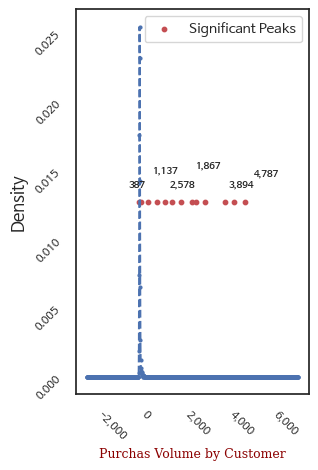

In [ ]:
mask = ( D < 5*10**4 )
filtered = D[ mask ]

# Kernel Density
plt.figure( figsize=(3, 5) )
estimate_PDF = filtered.plot.kde(
    bw_method=0.3,
    linewidth=1.5, markersize=2,
    marker='o', linestyle='dashed', color='b',
)

X, y = estimate_PDF.lines[0].get_xdata(), estimate_PDF.lines[0].get_ydata()

# Analyzing the steepness of a Kernel density estimation using the SteepnessDetector class
s_detec = SteepnessDetector()
s_detec.initialize_properties(data=D, x=X, y=y)
peaks, left_edges, right_edges = s_detec.local_maxima()
steep_boundaries = s_detec.calculate_steep_boundaries()
significant_peaks = s_detec.filtering_steeps()

# visualization
density_max   = max(y)
height = density_max * 0.5
x_coords = list(significant_peaks.values())
y_coords = [height] * len(significant_peaks)
plt.scatter(x_coords, y_coords, marker='o', color='r', s=10, label="Significant Peaks")

texts = []
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    if (i % 2 == 0) and (x > 0):
        texts.append(plt.text(x, y+0.001, f'{x:,.0f}', fontsize=7, ha='center', va='bottom', weight='bold'))
adjust_text(texts, force_points=0.2, force_text=(0.2, 0.2), expand_points=(1, 1), expand_text=(1, 1))


current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

prop = FontProperties(); prop.set_size('small')
handles, labels = plt.gca().get_legend_handles_labels()
handles_ = [handle for idx, handle in enumerate(handles) if labels[idx] != 'Quantity']
plt.legend(handles_, ['Significant Peaks'], prop=prop)

plt.xticks(rotation=-45, ha='left')
plt.yticks(rotation=45, ha='right')

plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)

plt.xlabel(
    'Purchas Volume by Customer',
    fontdict = {
        'size'  : 9,
        'family': 'serif',
        'weight': 'normal',
        'color' : 'darkred',
        }
    )

plt.show()

In [ ]:
print('\n\t\033[91m\033[1m - 고객별 구매량 분포에서 발견한 중요 판매량 지점 \033[0;0m', end=':\n ')
significant_peaks_list = list(significant_peaks.values())[::-1][1:]
for val in significant_peaks_list: print(f"\033[3m \t\t\t\t\t\t{val} \033[0;0m", end=',\n ')


'''
    - 판매량 기준 분류 조건을 저장할 딕셔너리 생성
    - 최초로 나타나는 중요한 판매량 피크 값보다 낮은 판매량을 가진 데이터를 분류하기 위한 조건
    - 중요한 판매량 피크 리스트를 순회하며, 연속적인 피크 값 사이의 판매량을 가진 데이터를 분류하기 위한 조건을 추가
'''
sales_classification_criteria = {
    f'under_{significant_peaks_list[0]}_sales' : _df1.Quantity < significant_peaks_list[0]
}
for i in range(1, len(significant_peaks_list)):
    sales_classification_criteria[f'between_{significant_peaks_list[i-1]}_{significant_peaks_list[i]}_sales'] = (
        (_df1.Quantity > significant_peaks_list[i-1]) & (_df1.Quantity < significant_peaks_list[i])
    )

print('\n\t\033[91m\033[1m - 중요 판매량 지점으로 고객 ID 군집을 생성 \033[0;0m', end=':\n ')
criteriaKeys = list(sales_classification_criteria.keys())
for key in criteriaKeys: print(f"\033[3m \t\t\t\t\t\t{key} \033[0;0m", end=',\n ')


	 - 고객별 구매량 분포에서 발견한 중요 판매량 지점 :
  						89 ,
  						387 ,
  						791 ,
  						1137 ,
  						1482 ,
  						1867 ,
  						2386 ,
  						2578 ,
  						2981 ,
  						3894 ,
  						4288 ,
  						4787 ,
 
	 - 중요 판매량 지점으로 고객 ID 군집을 생성 :
  						under_89_sales ,
  						between_89_387_sales ,
  						between_387_791_sales ,
  						between_791_1137_sales ,
  						between_1137_1482_sales ,
  						between_1482_1867_sales ,
  						between_1867_2386_sales ,
  						between_2386_2578_sales ,
  						between_2578_2981_sales ,
  						between_2981_3894_sales ,
  						between_3894_4288_sales ,
  						between_4288_4787_sales ,
 

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/PulLv2TShL.png" width = "170">



<font color = 'white'><font size = 2>**"가격이 저렴할수록 적정량 구입을 주기적으로 진행할 것이다."** 에 대한 회귀계수 유의성 검정(단측검정)에 대해, 유의수준 0.05(5%)에 대한 각 유의 확률 (-1.1341156342551404, 0.2568180208905173) 모두 통계적으로 유의하지 않음으로 귀무가설을 기각할 수 없습니다.</font>

<font color = 'white'><font size = 2>**"즉, 낮은 단가가 주기적 구매양상에 간접적 영향을 미친다고 볼 수 없다"** 라고 해석할 수 있습니다.</font>


---

In [ ]:
from IPython.display import display, HTML, Javascript

# Visualization
def display_datatables(dfs, titles, significantPeriodsInfo, rows_per_page=18, font_size='10px'):
    global data_KeyTimeRanges
    display(HTML("""
        <link rel="stylesheet" type="text/css" href="https://cdn.datatables.net/1.10.21/css/jquery.dataTables.css">
        <script type="text/javascript" charset="utf8" src="https://code.jquery.com/jquery-3.5.1.min.js"></script>
        <script type="text/javascript" charset="utf8" src="https://cdn.datatables.net/1.10.21/js/jquery.dataTables.js"></script>
    """))

    dropdown_html = "<div style='margin-left: 10px; margin-top: 40px; margin-bottom: 40px; display: inline-block;'>"
    dropdown_html += "<span style='font-weight: normal; color: #6A5ACD; font-size: 10px; display: block; margin-bottom: 5px;'>데이터 항목을 선택하세요</span>"
    dropdown_html += "<select id='datatableDropdown' style='font-style: italic; padding: 10px; border: dashed 1px blue; border-radius: 5px; text-align:center;' onchange='showSelectedDatatable()'>"

    for key in dfs.keys():
        title = titles[key].split()
        title = f"* {title[0]}  &rarr;  {title[3]}"
        dropdown_html += f"<option value='{key}'>{title}</option>"
    dropdown_html += "</select></div>"

    display(HTML(dropdown_html))
    display(HTML("""
        <style>
            .datatableDiv {
                display: none;
            }
            .stats-datatable th, .stats-datatable td {
                font-size: 12px;
            }
        </style>
        <script>
            function showSelectedDatatable() {
                var selected = document.getElementById("datatableDropdown").value;
                var tables = document.getElementsByClassName("datatableDiv");
                for(var i=0; i<tables.length; i++) {
                    if(tables[i].id == selected) {
                        tables[i].style.display = "block";
                    } else {
                        tables[i].style.display = "none";
                    }
                }
            }
        </script>
    """))

    first_key = list(dfs.keys())[0]
    for key, data in dfs.items():
        data = data.sort_values(by="repurchaseDates")
        column_names = list(data.columns)

        # Data Describe
        stats = list(map(lambda x: [np.nan]*2 + list(x) + [np.nan], data.describe().loc[['mean', 'std']].iloc[:, 1:].values))
        stats_ = stats + [[np.nan]*(len(column_names)) + [f"{len(data):.0f}"]]
        stats_df = pd.DataFrame(stats_,
                                columns = column_names + [''],
                                index = ['Mean', 'Std','dataSize'])
        stats_html = stats_df.to_html(classes='stats-datatable', border=1)

        fig       = plt.figure(figsize=(7, 7))
        grid_spec = plt.GridSpec(2, 1, height_ratios=[2, 1])

        ax0 = plt.subplot(grid_spec[0, :])
        sns.scatterplot(
            data=data, x="repurchaseDates", y="Purchase_Growth",
            marker='+',
            color='b',
            alpha = 0.5,
            ax=ax0
            )

        # lowess
        smoothed = lowess(data['Purchase_Growth'], range(len(data)), frac=0.3)
        dates, data_smoothed = data['repurchaseDates'], smoothed[:, 1]
        ax0.plot(dates, data_smoothed, color='red', label="LOWESS Smoothing")

        # vline
        auto_corr_dates = significantPeriodsInfo[key]['verified_auto_corr']['periods_merged']
        linearity_dates = significantPeriodsInfo[key]['linear_fit_details']['periods_merged']

        iter, step = 1, 0
        xycoords, textcoords, xytext, ha, fontsize, rotation = ('data', 'axes fraction'), 'offset points', (0, 5), 'center', 7, 90
        colorB,colorE  = ('b', 'crimson')
        for d_cor, d_lin in zip(auto_corr_dates, linearity_dates):
            for i in range(2):
                if i == 0:
                    x_TXT = ax0.annotate(
                        f'Begin of Linear Trend at {pd.to_datetime(d_lin[i]).strftime("%Y-%m-%d")}',
                        xy=(d_lin[i], 1.005), xycoords=xycoords,
                        textcoords=textcoords, xytext=xytext,
                        ha=ha, fontsize=fontsize, color=colorB,
                        rotation=rotation
                        )
                    Alpha = 1
                else:
                    x_TXT = ax0.annotate(
                        f'End of Linear Trend at {pd.to_datetime(d_lin[i]).strftime("%Y-%m-%d")}',
                        xy=(d_lin[i], 1.07), xycoords=xycoords,
                        textcoords=textcoords, xytext=xytext,
                        ha=ha, fontsize=fontsize, color=colorE,
                        rotation=rotation

                        )
                    Alpha = 0.5

                last_box, buffer_factor = None, 0.01
                renderer = fig.canvas.get_renderer()

                bounding_box = x_TXT.get_window_extent(renderer).transformed(ax0.transData.inverted())
                bounding_box_add_buffer = bounding_box.from_bounds(
                    bounding_box.x0,
                    bounding_box.y0,
                    bounding_box.width * buffer_factor,
                    bounding_box.height * buffer_factor
                )

                if (last_box is not None) and (bounding_box_add_buffer.overlaps(last_box)):
                    new_yoffset = x_TXT.get_position()[1] + 30
                else:
                    new_yoffset = x_TXT.get_position()[1]

                x_TXT.set_position((3, new_yoffset))
                last_box = bounding_box_add_buffer

                if step == 0:
                    ax0.axvline(d_cor[i], color='purple', linestyle='--', alpha=Alpha, label="Temporal Autocorrelation Group")
                    ax0.axvline(d_lin[i], color='y', linestyle='--', alpha=Alpha, label="Linear Trend Cluster")
                else:
                    ax0.axvline(d_cor[i], color='purple', linestyle='--', alpha=Alpha)
                    ax0.axvline(d_lin[i], color='y', linestyle='--', alpha=Alpha)
                step += 1
            iter += 1

        ax0.set_xticklabels("")
        ax0.set_yticklabels(ax0.get_yticks(), rotation=45, fontsize=7)
        ax0.set_xlabel(xlabel="", fontsize=8); ax0.set_ylabel(ylabel="재구매 시점의 구매량 상승 분석(Purchase Growth)", fontsize=9)
        ax0.legend(fontsize='x-small')

        # 하단에 추가로 그릴 그래프들의 공간 확보
        ax1 = plt.subplot(grid_spec[1, :])

        linear_fit_details = significantPeriodsInfo[key]['linear_fit_details']
        if 'StrongLinearPhase' in linear_fit_details:
            linearity_dates = linear_fit_details['StrongLinearPhase']

        data_KeyTimeRanges = data[(data['repurchaseDates'] >= linearity_dates[0]) & (data['repurchaseDates'] <= linearity_dates[1])]
        Previous2Weeks     = data[(data['repurchaseDates'] >= (linearity_dates[0] - np.timedelta64(14,'D'))) & (data['repurchaseDates'] < linearity_dates[0])]
        data_Next2Weeks    = data[(data['repurchaseDates'] > linearity_dates[1]) & (data['repurchaseDates'] <= (linearity_dates[1] + np.timedelta64(14,'D')))]

        sns.scatterplot(data=data_KeyTimeRanges, x="repurchaseDates", y="Purchase_Growth",
            marker='+',
            color='crimson',
            alpha = 0.5,
            ax=ax1
            )
        for subData in [Previous2Weeks, data_Next2Weeks]:
            sns.scatterplot(data=subData, x="repurchaseDates", y="Purchase_Growth",
                marker='+',
                color='b',
                alpha = 0.2,
                ax=ax1
                )

        smoothed = lowess(data_KeyTimeRanges['Purchase_Growth'], range(len(data_KeyTimeRanges)), frac=1)
        dates, data_smoothed = data_KeyTimeRanges['repurchaseDates'], smoothed[:, 1]
        ax1.plot(dates, data_smoothed,
                 linestyle='dashed',
                 linewidth=0.5,
                 color='crimson')

        ax1.set_title('')
        ax1.set_yticklabels(ax1.get_yticks(), rotation=45, fontsize=7)
        ax1.set_ylabel(ylabel='')
        ax1.set_xticks(data_KeyTimeRanges.repurchaseDates)
        ax1.set_xticklabels(data_KeyTimeRanges.repurchaseDates.dt.strftime("%Y-%m-%d"))

        currentXTicks, currentXLabels = ax1.get_xticks(), ax1.get_xticklabels()
        newXTicks = np.insert(currentXTicks, 0, currentXTicks[0]-10)
        newXTicks = np.append(newXTicks, currentXTicks[-1]+10)
        newXLabels = ['Previous2Weeks <<  '] + [label.get_text() for label in currentXLabels] + [ ' >> Next2Weeks']

        ax1.set_xticks(newXTicks)
        ax1.set_xticklabels(newXLabels, rotation=-45, fontsize=7, fontweight='bold')

        getLabels = ax1.get_xticklabels()
        for i, xlabel in enumerate(getLabels):
            if (i == 0) or (i == len(getLabels)-1):
                xlabel.set_rotation(0)
                xlabel.set_color('darkgrey')
            else:
                xlabel.set_rotation(-45)
                xlabel.set_color('black')

        ax1.set_xlabel(
            xlabel="Highlighting Maximum Linear Growth in Repurchase Growth",
            fontdict = {
                'size'  : 9,
                'family': 'serif',
                'weight': 'normal',
                'color' : 'darkred',
                }
        )

        for i, w in zip(range(2), [1, 0.5]):
            xyA, xyB = (linearity_dates[i], ax0.get_ylim()[0]), (linearity_dates[i], ax1.get_ylim()[1])
            conAB  = ConnectionPatch(xyA=xyA, xyB=xyB, axesA=ax0, axesB=ax1,
                                    coordsA="data", coordsB="data",
                                    linewidth=w, color="y", linestyle='--', arrowstyle="->")
            ax0.add_artist(conAB)

        plt.subplots_adjust(wspace=0.3) # hspace=0.9
        plt.tight_layout(pad=3)

        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')
        buf.close()

        chart_html = f'<img src="data:image/png;base64,{img_base64}" />'
        plt.close()

        #;
        dfP   = copy.copy(Previous2Weeks);
        dfP   = dfP.set_index('CustomerID');

        dfP.columns = ["·"*len(dfP.columns[i]) for i in range(len(dfP.columns))]

        Title = "Previous2Weeks"
        dfP.index = pd.MultiIndex.from_product([[Title], dfP.index], names=['', 'CustomerID'])

        dfP_html = dfP.to_html(classes='datatable')
        dfP_html = dfP_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfP_html = dfP_html.replace('<td>', f'<td style="font-size:{font_size};">')

        #;
        dfMain = copy.copy(data_KeyTimeRanges)
        dfMain = dfMain.set_index('CustomerID')

        Title = 'KeyTimeRanges'
        dfMain.index = pd.MultiIndex.from_product([[Title], dfMain.index], names=['', 'CustomerID'])

        dfMain_html = dfMain.to_html(classes='datatable')
        dfMain_html = dfMain_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfMain_html = dfMain_html.replace('<td>', f'<td style="font-size:{font_size};">')

        #;
        dfNext = copy.copy(data_KeyTimeRanges)
        dfNext = dfNext.set_index('CustomerID')

        Title = "Next2Weeks"
        dfNext.index = pd.MultiIndex.from_product([[Title], dfNext.index], names=['', 'CustomerID'])

        dfNext.columns = ["·"*len(dfNext.columns[i]) for i in range(len(dfNext.columns))]
        dfNext_html = dfNext.to_html(classes='datatable')
        dfNext_html = dfNext_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfNext_html = dfNext_html.replace('<td>', f'<td style="font-size:{font_size};">')

        display_style = "block" if key == first_key else "none"
        display(HTML(f"""
            <div id='{key}' class='datatableDiv' style='margin-bottom: 30px; display: {display_style};'>
                <h2 style='font-family:Arial; color: #6A5ACD; font-size: 13px; margin-bottom: 10px;'>{titles[key]}</h2>
                <div class='stats-container' style="background-color: rgba(75, 0, 130, 0.2); border: 1px solid #ccc; padding: 20px; margin-bottom: 30px; display: inline-block; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);">
                    {stats_html}
                </div>
                <div style='display: flex; flex-direction: row; justify-content: space-between;'>
                    <div style='display: flex; flex-direction: row; justify-content: space-between;'>
                        <div style='display: flex; flex-direction: column; gap: 20px; width: 70%;'>
                            <button class="customToggleBtn" onclick="toggleContent('{key}_dfP')">View Data from Previous 2 Weeks ⤴</button>
                            <div id='{key}_dfP' class='main_data_container' style='display: none; background-color: rgba(255, 255, 0, 0.2); border: 2px solid grey; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfP_html}
                            </div>
                            <div class='main_data_container' style='background-color: rgba(255, 255, 0, 0.2); border: 2px solid red; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfMain_html}
                            </div>
                            <button class="customToggleBtn" onclick="toggleContent('{key}_dfNext')">Explore Data for Upcoming 2 Weeks ⤵</button>
                            <div id='{key}_dfNext' class='main_data_container' style='display: none; background-color: rgba(255, 255, 0, 0.2); border: 2px solid grey; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfNext_html}
                            </div>
                        </div>
                    <div class='bar-container' style='flex-grow: 1; padding-left: 30px;'>
                        {chart_html}
                    </div>
                </div>
            </div>
        """))

    display(HTML("""
        <style>
            .customToggleBtn {
                padding: 8px 12px;
                color: #808080;
                background-color: transparent;
                border: 2px dashed #6A5ACD;
                border-radius: 8px;
                cursor: pointer;
                margin-right: 5px;
                font-weight: bold;
                font-style: italic;
                transition: all 0.3s;
            }
            .customToggleBtn:hover {
                background-color: #f0f0f0;
            }
        </style>

        <script type="text/javascript">
            function toggleContent(contentId) {
                var content = document.getElementById(contentId);
                if (content.style.display === "none") {
                    content.style.display = "block";
                } else {
                    content.style.display = "none";
                }
            }
            $(document).ready(function() {
                $('.datatable').DataTable({
                    "pageLength": {rows_per_page}
                });
                showSelectedDatatable();
            });
        </script>
    """))


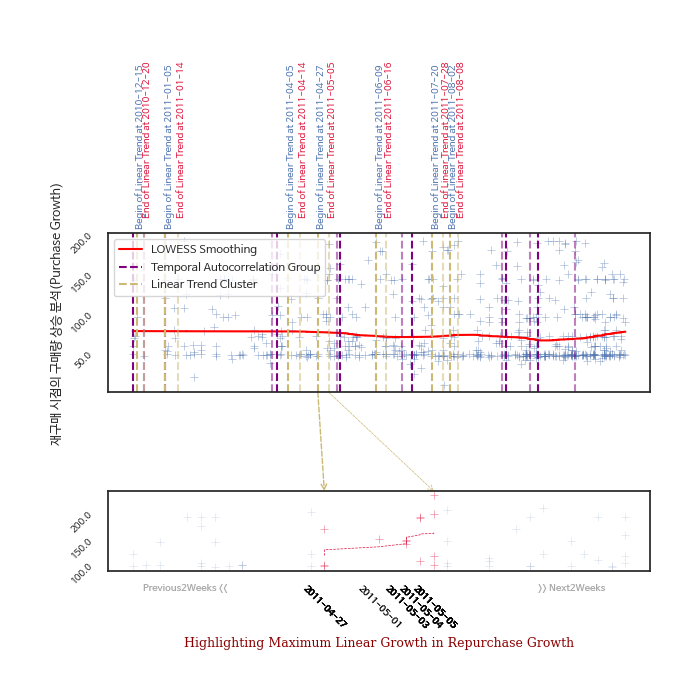


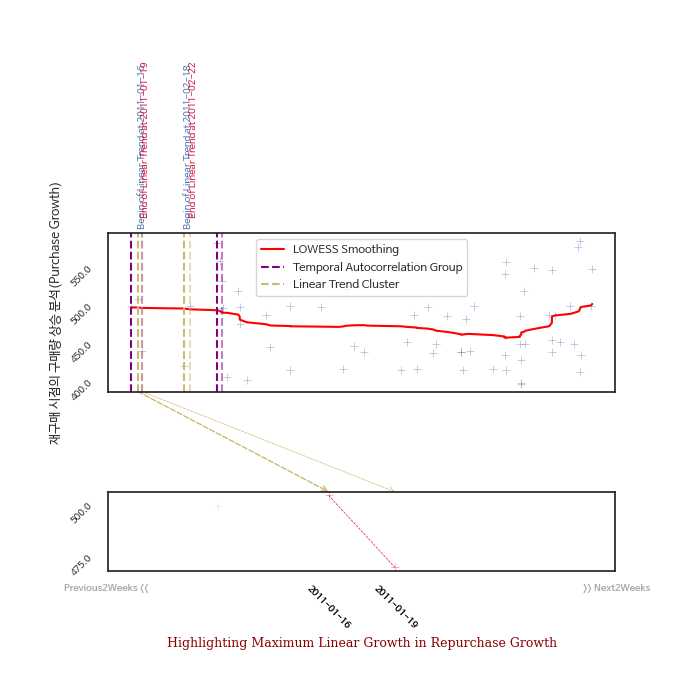


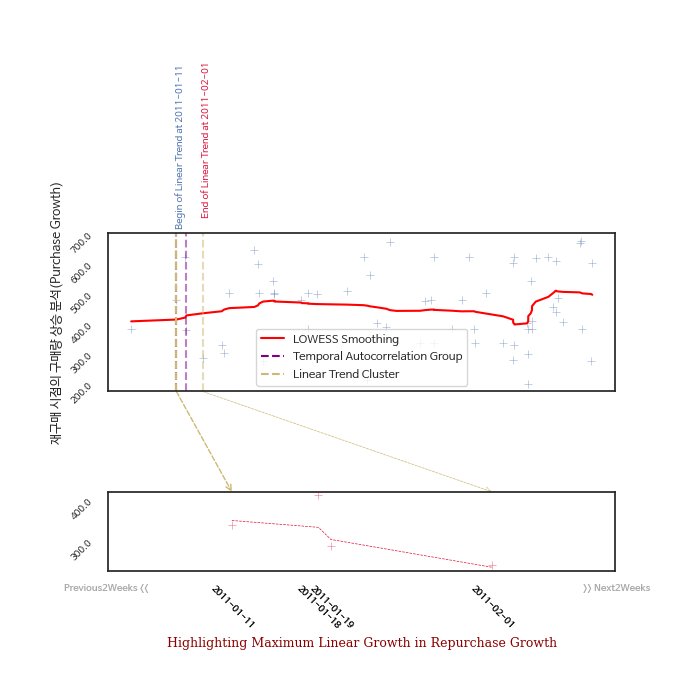

In [ ]:
extracted = _df1.loc[:, ['CustomerID', 'StockCode', 'Quantity', 'Inv_date']]
extracted = extracted.rename(
    columns = {'Inv_date': 'Purchase_date'}
)

extracted_aggregated = extracted.groupby(['CustomerID', 'Purchase_date'], as_index=False).agg(
    {
        'Quantity':'sum',
        'Purchase_date':'first'
        }
    )

def calculate_growth_and_find_optimal(i, j, extracted, sales_classification_criteria, criteriaKeys, isFirstPair):

    """

        [ 분석의 개요 ]
                - 해당 함수는 주어진 두 구매량 그룹의 판매량 증가량을 계산합니다.
                - 또한, 고객별 최적의 판매량 증가를 확인하기 위한 분석도 수행합니다.
                - 고객들이 한 판매량 그룹에서 *다른 판매량 그룹으로 전환될 때의 구매 성장률을 분석하기 위함입니다.

        [ 가능한 적용 ]
                - 기업은 고객들이 어떠한 판매량 그룹에서 다른 판매량 그룹으로 얼마나 빠르게 전환되는지, 그리고 그 전환을 통해 얼마나 많은 판매량 증가가 발생하는지 파악하기 원합니다.
                - 이를 통해, 시장 내에서의 고객의 구매 패턴 변화나 선호도의 증가 등의 현상을 분석할 수 있습니다.

        [ 파라미터 설명 ]
                - i, j: 판매량 그룹 인덱스
                - extracted: 고객ID, 상품코드, 구매량, 구매 날짜 정보가 들어 있는 데이터프레임
                - sales_classification_criteria: 판매량 그룹을 분류하는 조건들의 딕셔너리
                - criteriaKeys: 판매량 그룹의 키 목록
                - isFirstPair: 첫 번째 판매량 그룹 페어인지의 여부 (bool)

        [ 주요 계산 로직 ]

                1. 두 판매량 그룹의 데이터를 병합(merge)합니다.
                   : 이를 통해 같은 고객이 어떻게 다른 판매량 그룹에서 구매하는지를 분석할 수 있습니다.

                2. 두 구매 사이의 날짜 차이(Days_Between_Rebuy)를 계산하여 새로운 열로 추가합니다.
                   : 고객이 얼마나 빠르게 한 판매량 그룹에서 다른 판매량 그룹으로 전환되는지 분석하는 데 사용됩니다.

                3. 판매량의 성장률(Purchase_Growth)을 계산하여 새로운 열로 추가합니다.
                   : 얼마나 많은 판매량 증가가 있는지를 파악하기 위해 사용됩니다.

                4. 고객별로 최대 판매량 성장률을 가진 데이터를 추출합니다.
                   : 이를 통해 각 고객별로 어떤 판매량 그룹 전환에서 최대의 판매량 증가가 발생하는지 파악할 수 있습니다.

        [ 반환하는 결과 ]
                - 판매량 그룹 페어의 이름(key_name), 판매량 증가 데이터(customer_sales_by_peak_criteria), 최적의 판매량 증가 데이터(optimal_growth_per_customer), 제목(title)을 반환합니다.

    """

    # 두 판매량 그룹 간의 데이터를 병합하여 고객별 구매 패턴을 분석합니다.
    customer_sales_by_peak_criteria = extracted[
        sales_classification_criteria[criteriaKeys[i]]
        ].merge(
            extracted[
                sales_classification_criteria[criteriaKeys[j]]],
                on='CustomerID', how='left'
                ).dropna().query("Purchase_date_x < Purchase_date_y").reset_index(drop=True)
    customer_sales_by_peak_criteria = customer_sales_by_peak_criteria.rename(
        columns={
            'StockCode_x'     :'StockCode',
            'Quantity_x'      :'Initial_Purchase_Quantity',
            'Purchase_date_y' : 'repurchaseDates'
            }
        )

    # 두 구매 사이의 날짜 차이를 계산하여, 고객이 판매량 그룹을 얼마나 빠르게 전환하는지 파악합니다.
    customer_sales_by_peak_criteria['Days_Between_Rebuy'] =  (customer_sales_by_peak_criteria['repurchaseDates'] - customer_sales_by_peak_criteria['Purchase_date_x']).dt.days

    # 판매량의 증가량을 계산하여, 고객이 어떤 판매량 그룹 전환에서 얼마나 많은 판매량 증가를 보이는지 분석합니다.
    customer_sales_by_peak_criteria['Purchase_Growth'] = customer_sales_by_peak_criteria['Quantity_y'] - customer_sales_by_peak_criteria['Initial_Purchase_Quantity']
    customer_sales_by_peak_criteria = customer_sales_by_peak_criteria.iloc[:, [0,1,2, -1,-2,-3]]

    # 고객별 최대 판매량 성장률을 계산하여, 각 고객이 어떤 판매량 그룹 전환에서 가장 높은 성장률을 보이는지 파악합니다.
    best_growth_indices = customer_sales_by_peak_criteria.groupby('CustomerID')['Purchase_Growth'].idxmax()
    optimal_growth_per_customer = customer_sales_by_peak_criteria.loc[best_growth_indices].sort_values(by=['repurchaseDates'])

    key_name = f'Rebuy_{criteriaKeys[i]}_to_{criteriaKeys[j]}'
    title = f"{criteriaKeys[i]} 구매량 그룹에서 {criteriaKeys[j]} 구매량 그룹으로 이동 - 시장 선호도(Market Preference)가 상승"

    return key_name, customer_sales_by_peak_criteria, optimal_growth_per_customer, title

def Identify_and_merge_market_interest_periods(Input = input):
    """
        [ 주요 계산 로직 ]

                1. 본 분석에서의 Durbin-Watson test 결과는 특별한 상황입니다.
                일반적으로 자기상관성은 예측의 어려움을 의미할 수 있으나, 이 경우에는 시장 선호도를 반영하는 중요한 신호로 해석됩니다.
                즉, 특정 기간 동안 일관된 성장과 유사한 특성을 나타내는 주요 지표로 볼 수 있습니다.

                2. 회귀모델의 p-value가 0.05보다 작은 구간, 즉. 통계적으로 유의한 선형 관계 여부를 탐지하며, *본 분석에서는 해당 현상을 시장(서비스)에 대한 전반적인 관심도가 상승된 것으로 간주합니다.

    """
    def merge_overlapping_periods(significant_windows, syncedValue, synced=False):
        """
            * 함수 'merge_overlapping_periods'는, 입력된 날짜 기간 목록에서 서로 중첩되는 기간들을 찾아 하나의 연속된 기간으로 병합하고, 중첩되지 않는 기간들은 그대로 유지한 새로운 목록을 반환하는 함수입니다.
        """
        while True:
            isOverlapping_cnt = 0
            le = len(significant_windows)

            for i in range(1, le):
                combind_period = [significant_windows[i-1], significant_windows[i]]
                startDates, endDates = zip(*combind_period)
                if (combind_period[0][0] <= combind_period[1][1]) and (combind_period[1][0] <= combind_period[0][1]):
                    significant_windows[i-1] = np.nan
                    if synced:
                        syncedValue[i]   = (syncedValue[i] + syncedValue[i-1]) / 2
                        syncedValue[i-1] = np.nan

                    significant_windows[i] = [min(startDates), max(endDates)]

                    isOverlapping_cnt += 1

            significant_windows = list(filter(lambda x: type(x) != float, significant_windows))
            if synced: syncedValue = list(filter(lambda x: type(x) != float, syncedValue))
            if isOverlapping_cnt == 0:
                significant_windows_ret = copy.copy(significant_windows)
                syncedValue_ret = copy.copy(syncedValue)
                break

        if synced:
            return significant_windows_ret, syncedValue
        else:
            return significant_windows_ret


    earliestRepurchase, latestRepurchase = Input['repurchaseDates'][:1].values[0], Input['repurchaseDates'][-1:].values[0]

    dataRange = pd.Series(pd.date_range(earliestRepurchase, latestRepurchase, freq='D'))
    missingDates = dataRange[~dataRange.isin(Input['repurchaseDates'])]

    missingDatesDf = pd.DataFrame(
        {
            'repurchaseDates': missingDates,
        }
    ); dfWithNulls = pd.concat([Input, missingDatesDf], axis=0).sort_values(by='repurchaseDates').reset_index(drop=True)

    verified_auto_corr = {
        'significant_periods': [],
    }
    linear_fit_details = {
        'significant_periods': [],
        'linearity_strength'   : [],
    }
    window_size = 14
    for start in range(0, len(Input)-window_size):
        window_data      = dfWithNulls.iloc[start:start+window_size, :].dropna().reset_index(drop=True)
        if len(window_data) > 1:
            valid_date_range = [window_data['repurchaseDates'][:1].values[0], window_data['repurchaseDates'][-1:].values[0]]

            '''
                - slope: 회귀분석의 결과로, 재구매 시 상승된 구매량의 변화량.
                - R_squared: 선형특성의 strength 및 방향을 측정 -1과 1은 완벅한 음, 양의 선형관계를 의미하며, 0은 선형관계가 없음을 의미. (상관계수, 범위: (-1 < value < 1))
                - p-value(the hypothesis test on the slope): 0.05보다 작은 값이어야 기울기가 0과 유의하게 다름을 의미.
                - error_of_the_estimated_slope: 추정 기울기의 "표준오차"이며, "표준오차"는 작을수록 추정치가 정확함을 의미.
            '''
            slope, starting_value, R_squared, p_value, error_of_the_estimated_slope = linregress(range(len(window_data)), window_data.Purchase_Growth)

            Residuals = window_data.Purchase_Growth - (starting_value + slope * np.arange(len(window_data)))
            DW_result = durbin_watson(Residuals)
            if (DW_result < 1.5) or (DW_result > 2.5): verified_auto_corr['significant_periods'].append(valid_date_range)
            elif p_value < 5/(10**2):
                linear_fit_details['significant_periods'].append(valid_date_range)
                linear_fit_details['linearity_strength'].append(R_squared)

    verified_auto_corr['periods_merged'] = merge_overlapping_periods(
        verified_auto_corr['significant_periods'],
         [], synced=False)
    linear_fit_details['periods_merged'], linear_fit_details['linearity_strength'] = merge_overlapping_periods(
        linear_fit_details['significant_periods'],
        linear_fit_details['linearity_strength'],
        synced=True
        )

    strength, dates = linear_fit_details['linearity_strength'], linear_fit_details['significant_periods']
    try:
        strength_ = list(filter(lambda x: x<1, strength))
        if sum(map(lambda x: x>0, strength_)):
            linear_fit_details['StrongLinearPhase'] = linear_fit_details['periods_merged'][strength_.index(max(strength_))]
        else:
            linear_fit_details['StrongLinearPhase'] = linear_fit_details['periods_merged'][strength_.index(min(strength_))]
    except:
        pass

    return verified_auto_corr, linear_fit_details

num_criteriaKeys = len(criteriaKeys)
pairs = [(i, j) for i in range(num_criteriaKeys-1) for j in range(i+1, num_criteriaKeys)]

with Pool(processes=mp.cpu_count()) as pool:
    results = pool.starmap(calculate_growth_and_find_optimal, [(i, j, extracted, sales_classification_criteria, criteriaKeys, pairs.index((i, j)) == 0) for i, j in pairs])

dfs, dfsBestgrowth, titles = {}, {}, {}
significantPeriodsInfo = {}

for key_name, df, optimal_growth_per_customer, title in results:
    if len(df) > 3: dfs[key_name] = df
    if len(optimal_growth_per_customer) > 3:
            verified_auto_corr, linear_fit_details = Identify_and_merge_market_interest_periods(Input=optimal_growth_per_customer)

            # 2주. 14일씩 탐색하여, 구매의 성장률이 선형성을 띄는 기간이 탐지되는(not empty) '구매량 상승 고객그룹'만을 유의미한 데이터셋으로 취급합니다.
            if  (len(verified_auto_corr['periods_merged']) > 0) & (len(linear_fit_details['periods_merged']) > 0):
                significantPeriodsInfo[key_name] = {
                    'verified_auto_corr' : verified_auto_corr,
                    'linear_fit_details' : linear_fit_details
                    }
                titles[key_name] = title; dfsBestgrowth[key_name] = optimal_growth_per_customer;

display_datatables(dfsBestgrowth, titles, significantPeriodsInfo)

## <font size = 3>Cohort analysis</font>

### <font size = 3>Cohort analysis_ 1. Retention rate</font>

<!DOCTYPE html>
<html>

<head>
    <meta charset="utf-8" />
    <meta http-equiv="X-UA-Compatible" content="IE=edge">
    <meta name="viewport" content="width=device-width, initial-scale=1">
</head>

<body>
    <img src="https://www.customerthermometer.com/img/customer-retention-formula-1500x560.jpg" width="500">
</body>

</html>



In [ ]:
# 각 고객의 구매 시점을 월 단위로 정리합니다.
_df1['get_YearMonth'] = _df1['InvoiceDate'].apply(lambda x: datetime(x.year, x.month, 1))

# 각 고객의 첫 구매 시점을 기록하여 고객의 코호트를 정의합니다.
_df1['dt_Firstpurchase'] = _df1.groupby('CustomerID')['get_YearMonth'].transform('min')

# 분석에 필요한 연도와 월 정보를 추출합니다.
cohort_TargetcolL = ['get_YearMonth', 'dt_Firstpurchase']

# 각 구매의 연도와 월을 별도 열로 분리하여 저장합니다.
_df1['Y'], _df1['M'], _df1['D1'] = pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).year, pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).month, pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).day

# 각 고객의 첫 구매 시점의 연도와 월을 별도 열로 분리하여 저장합니다.
_df1['F_purche_Y'], _df1['F_purche_M'], _df1['F_purche_D1'] = pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).year, pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).month, pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).day

# 첫 구매와 현재 구매 사이의 월 단위 간격을 계산합니다.
Y_interval = _df1['Y'] - _df1['F_purche_Y']
M_interval = _df1['M'] - _df1['F_purche_M']

# 각 고객의 코호트 내에서 구매 간격을 정리하여, 몇 번째 월인지 나타냅니다.
_df1['cohort_M_period'] = 12*Y_interval + M_interval + 1

# 코호트 월간 고객 수를 계산하여 데이터프레임으로 만듭니다.
cohort_df = _df1.groupby(['cohort_M_period', 'dt_Firstpurchase'])['CustomerID'].nunique().reset_index()

# 피벗 테이블을 사용하여 첫 구매 시점을 기준으로 코호트를 형성합니다.
cohort_pivot = cohort_df.pivot(index='dt_Firstpurchase', columns='cohort_M_period', values='CustomerID')

# 각 코호트의 첫 달 대비 유지율을 계산합니다.
cohort_Retentionrt = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)

# 유지율을 보기 좋게 월별 형식으로 변환합니다.
cohort_Retentionrt = cohort_Retentionrt.set_index(cohort_Retentionrt.index.strftime("%Y-%m"))

# 유지율을 퍼센트로 변환하여 데이터 테이블로 시각화합니다.
data_table.DataTable(cohort_Retentionrt.applymap(lambda x: str(round(x*100, 2))+'%' if pd.notnull(x) else ''), include_index=True, num_rows_per_page=13)

cohort_M_period,1,2,3,4,5,6,7,8,9,10,11,12,13
dt_Firstpurchase,,,,,,,,,,,,,
2010-12,100.0%,36.54%,32.35%,38.35%,36.2%,39.82%,36.2%,34.84%,35.29%,39.48%,37.33%,50.23%,26.47%
2011-01,100.0%,21.88%,26.68%,22.84%,31.73%,28.85%,24.76%,24.04%,29.57%,32.69%,36.54%,11.78%,
2011-02,100.0%,18.68%,18.68%,28.68%,27.11%,24.47%,25.53%,27.37%,24.74%,30.53%,6.84%,,
2011-03,100.0%,14.82%,25.22%,19.91%,22.35%,16.81%,26.77%,23.01%,27.88%,8.63%,,,
2011-04,100.0%,21.0%,20.33%,21.0%,19.67%,22.67%,21.67%,26.0%,7.33%,,,,
2011-05,100.0%,19.01%,17.25%,17.25%,20.77%,23.24%,26.41%,9.51%,,,,,
2011-06,100.0%,17.36%,15.7%,26.45%,23.14%,33.06%,9.5%,,,,,,
2011-07,100.0%,17.65%,20.32%,22.46%,27.27%,11.23%,,,,,,,
2011-08,100.0%,20.12%,24.26%,24.26%,12.43%,,,,,,,,


In [ ]:
def comp_2_grp(y2, y1, X, y2lab, y1lab, tlt, dtick2, dtick1, annot_inter_x2, annot_inter_x1, upload_code):
    fig = make_subplots(rows=1, cols=2, specs=[[{}, {}]], shared_xaxes=True,
                        shared_yaxes=False, vertical_spacing=0.001)

    fig.append_trace(go.Bar(
        x=y2,
        y=X,
        marker=dict(
            color='rgba(50, 171, 96, 0.6)',
            line=dict(
                color='rgba(50, 171, 96, 0.6)',
                width=1
            )
        ),
        name=y2lab,
        orientation='h'
    ), 1, 1)

    fig.append_trace(go.Scatter(
        x=y1,
        y=X,
        mode='lines+markers',
        line_color='rgb(128, 0, 128)',
        name=y1lab
    ), 1, 2)

    fig.update_layout(
        title=tlt,
        yaxis=dict(
            showgrid=False,
            showline=False,
            showticklabels=True,
            domain=[0, 0.85],
        ),
        yaxis2=dict(
            showgrid=False,
            showline=True,
            showticklabels=False,
            linecolor='rgba(102, 102, 102, 0.8)',
            linewidth=2,
            domain=[0, 0.85],
        ),
        xaxis=dict(
            zeroline=False,
            showline=False,
            showticklabels=True,
            showgrid=True,
            domain=[0, 0.42],
            dtick=dtick2
        ),
        xaxis2=dict(
            zeroline=False,
            showline=False,
            showticklabels=True,
            showgrid=True,
            domain=[0.47, 1],
            side='top',
            dtick=dtick2,
        ),
        legend=dict(x=0.029, y=1.038, font_size=10),
        margin=dict(l=100, r=20, t=70, b=70),
        paper_bgcolor='rgb(255, 255, 255)',
        plot_bgcolor='rgb(255, 255, 255)',
        height=500,
        width=1200,
    )
    annot = []
    y1_percent = list(map(lambda x: int(x*100), y1st))
    for y1_i, y1p_i, y2_i, xi in zip(y1, y1_percent, y2, X):
        annot.append(dict(
            xref='x2', yref='y2',
            x=y1_i+annot_inter_x2, y=xi+0.25,
            text='{:}%'.format(y1p_i), textangle=-7,
            font=dict(family='Arial', size=12, color='rgb(128, 0, 128)'),
            showarrow=False)
        )
        annot.append(dict(
            xref='x1', yref='y1',
            x=y2_i+annot_inter_x1, y=xi+0.25,
            text=str(y2_i), textangle=-7,
            font=dict(family='Arial', size=12, color='rgb(50, 171, 96)'),
            showarrow=False)
        )

    fig.update_layout(annotations=annot)
    fig.show(renderer="colab")

In [ ]:
'''
    * rep_pb: repeated purchasing behavior
        ☑️ rep_pb_cumsum_sorted: 각 코호트 그룹 별 거래(신규거래) 발생에 대한 누적현황 계산합니다.
        ☑️ rep_pb_in_month: 각 시간경과(13 단계) 별 거래현황을 계산합니다.
'''

rep_pb_cumsum_sorted = _df1.groupby('dt_Firstpurchase')['CustomerID'].nunique().cumsum().reset_index().sort_values(by='CustomerID', ascending=False).set_index('dt_Firstpurchase')
rep_pb_in_month = _df1.groupby('cohort_M_period')['CustomerID'].nunique().reset_index()

x    = rep_pb_in_month['cohort_M_period'].values
y1st = list(rep_pb_in_month['CustomerID'] / rep_pb_cumsum_sorted.reset_index()['CustomerID']) # 전체 유저를 대상으로 월 기준 유지율(retention rates)
y2nd = cohort_df[cohort_df['cohort_M_period'] == 1].loc[:, 'CustomerID'].tolist()

In [ ]:
comp_2_grp(y2=y2nd, y1=y1st, X=x, y2lab='new transaction', y1lab='retention rate', tlt='최초 거래발생일 기준 코호트(Cohort) 집단 별 신규거래 변화 및 전체고객 거래 유지율에 대한 추이', dtick2=100, dtick1=0.1, annot_inter_x2=0.07, annot_inter_x1=0, upload_code=1)

In [ ]:
_df1['TotalPrice'] = _df1['UnitPrice'] * _df1['Quantity']
Monthly_consumption = _df1.groupby("get_YearMonth").agg({"TotalPrice": "sum",
                                                         "CustomerID": "nunique"})
Monthly_consumption['Index'] = range(1, len(Monthly_consumption)+1)

y2, y1, x = zip(*Monthly_consumption.values)
x = pd.Series(x).apply(lambda x: int(x))

In [ ]:
comp_2_grp(y2, y1, X=x, y2lab='consumption', y1lab='trading inquiry', tlt='2010년 12월 ~ 2011년 12월 사이 월별 거래현황 및 소비량에 대한 추이', dtick2=10 ** 5, dtick1=2*(10 ** 2), annot_inter_x2=10 ** 2, annot_inter_x1=5*(10 ** 4), upload_code=2)

#### <font size = 3>2. Change Pattern Analysis</font>

<font size = 2>위 과정에서 주장했던 바 **Customer Segmentation**을 본격적으로 수행하기에 앞서, **Unit Price**, **Quantity**, **Total Price**의 **시간적 변화에 따른 값의 변화 경향** (Trend)를 **분석**, **예측**해봅니다.</font>

<font size = 2>먼저, **상품** (StockCode)에 기준하여 전체 데이터셋을 그룹화 하였습니다. 이 후, 각 데이터셋들의 **표준편차의 평균($\\E({S})$)**보다 ${S}$가 큰 **표본** (Sample)만을 선별하여 시계열 그래프로 시각화 하였습니다.</font>

<font color = 'crimson'><font size=1>***(위의 과정은, 의미적으로 '분산'(편차의 평균)보다 큰 편차를 가진 값들을 선별한 것과 같습니다. 해당 이론에 대한 자세한 자료가 필요하시다면, 다음의 정리문서가 도움이 될 것입니다. https://docs.google.com/document/d/1CQYD6uHHizdy0iAXMeQI7rL2WzbaAA2htFThV1mSJog/edit?usp=sharing)***</font>


In [ ]:
price_nunq  = _df1.groupby('StockCode').UnitPrice.nunique()
over3_codes = list(set(price_nunq[price_nunq >= 3].index))
indexes = list(map(lambda x: np.where(_df1.reset_index(drop=True).StockCode == x)[0].tolist(), over3_codes)); m_indexes = sum(indexes, [])
indexes.sort()

over3_df = _df1.reset_index(drop=True).iloc[m_indexes].reset_index(drop=True)
over3_df.loc[:, 'InvoiceDate'] = over3_df.InvoiceDate.apply(lambda x: pd.to_datetime(x))
over3_dfFv = over3_df.loc[:, ['InvoiceDate', 'StockCode',	'Quantity',	'UnitPrice', 'TotalPrice']].copy()

<font color = 'white'>.</font>

<center><font color = 'blue'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

In [ ]:
indexL = []
over3_dfFv['extr_date'] = over3_dfFv.InvoiceDate.apply(lambda x: x.date())
y = over3_dfFv.groupby('extr_date')['TotalPrice'].max().reset_index().values
for X in y:
    X1, X2 = X; idx = over3_dfFv[(over3_dfFv['extr_date'] == X1) & (over3_dfFv['TotalPrice'] == X2)].index[0]
    indexL.append(idx)

In [ ]:
X = over3_dfFv.iloc[indexL].iloc[:, 1:]['extr_date']
def YD(y):
    return over3_dfFv.iloc[indexL].iloc[:, 1:][y]

data_dic = {
    'Date':X,
    'UnitPrice':YD('UnitPrice'),
    'Quantity':YD('Quantity'),
    'TotalPrice':YD('TotalPrice')
}; df = pd.DataFrame(data_dic)

df = df.reset_index(drop=True); filename='max_value_grp.csv'
df.to_csv(filename)

In [ ]:
#@title <font color = 'grey'><font size = 3><b>Kalman Filtering</b></font>

'''
    ☑️ 해당 필터는 '계측치'와 '예측치'에 대한 신뢰의 정도를 조절하여 Next state의 예측값을 결정하는 구조입니다.
    ☑️ 하여,  predict function(예측치), update function(계측치)로 나누어 하단에 식을 전개하겠습니다.
    ☑️ 더불어, predict과 update 모두, X, P 즉, 데이터 값, 공분산을 함께 고려합니다.
'''
class kalman_filter():
    # State Update, Covariance Update를 Tuple에 저장합니다. 한 예로, State_t1 = State(X_t1, P_t1)이라면, ((State_t1.X == X_t1) & (State_t1.P == P_t1)) == True가 성립합니다.
    State = namedtuple('State', 'X, P')

    def predict(state, F, Q):
        # F는 해당 시간 t에서의  t-1 상태에 기반한 상태 전이행렬이며, x의 t-1에서의 예측값과 결합됨으로 아래와 같은 '가정 설정문'을 지정합니다.
        assert state.X.shape[0] == F.shape[1]
        assert state.X.shape[1] == 1
        # 전이행렬 'F'와 Process Noise 'Q'값은 대칭행렬이어야 함으로 아래와 같은 '가정 설정문'을 지정합니다.
        assert F.shape[0] == F.shape[1]
        assert Q.shape[0] == Q.shape[1]
        assert Q.shape[0] == F.shape[0]

        x_pred = np.matmul(F, state.X)
        p_pred = np.matmul(F, np.matmul(state.P, F.T)) + Q
        return kalman_filter.State(x_pred, p_pred)

    def update(prior, z, R, H):
        assert prior.X.shape[1] == 1
        assert prior.X.shape[0] == H.shape[1]
        assert H.shape[0] == z.shape[0]
        assert z.shape[1] == 1
        assert prior.P.shape[0] == prior.P.shape[1]
        assert prior.P.shape[1] == H.shape[1]

        z_pred = np.matmul(H, prior.X)
        y = z - z_pred
        # 오차(추정치) 공분산 행렬인 P의 크기가 최소일 때의 K 값을 단계별 K 값으로 결정합니다. 더불어, S의 '역행렬'과 P의 곱을 통해 K(Kalman gain)을 계산합니다. (코드 전개에 대한 수학적 원리를 확인코자 하신다면, 꼭 상단의 첨부문서를 확인해주세요.)
        S = np.matmul(H, np.matmul(prior.P, H.T)) + R
        K = np.matmul(prior.P, np.matmul(H.T, np.linalg.inv(S)))
        x_posterior = prior.X + np.matmul(K, y)
        # P의 Update 값은 P(-)-KHP(-) 값이며, P(-)(1-KH)로 변환할 수 있습니다. (identity를 사용하여 I(단위행렬)을 생성할 수 있습니다.))
        p_posterior = np.matmul((np.identity(prior.P.shape[0]) - np.matmul(K, H)), prior.P)
        return kalman_filter.State(x_posterior, p_posterior)

def main(R_multiplied, target_col, upload_code):
    global gt, res, vel, img_bytes
    tr_intrim, tr_results = [], []
    for Ti in [0, R_multiplied]:
        data, index = [], 0
        target_col = target_col
        with open(filename) as data_file:
            data_reader = csv.DictReader(data_file, delimiter=',')
            for row in data_reader:
                data.append(np.array([[float(row[target_col])]]))

        gt  = {'price': [], 'trend': []}
        res = {'price': [], 'trend': []}
        vel = []

        x = np.full((2, 1), 2)
        P = np.full((2, 2), 2 ** 2)
        state = kalman_filter.State(x, P)

        Q = np.full((2, 2), 1 ** 2)
        F = np.array([[1, 1],
                    [0, 1]])

        # default value is 0
        multiplied_by_any = Ti
        R = np.array([[(0.5 + multiplied_by_any) ** 2]]) #
        H = np.array([[1, 0]])

        counter = 0
        while index < len(data):
            index += 1
            z = data[index - 1]

            if counter == 0:
                x = np.array([[z[0][0]],
                            [0]])
                state = kalman_filter.State(x, P)

            prior = kalman_filter.predict(state, F, Q)
            posterior = kalman_filter.update(prior, z, R, H)
            state = posterior

            gt['price'].append(z[0][0])
            res['price'].append(prior.X[0][0])
            vel.append(prior.X[1][0])

            if counter == 0:
                gt['trend'].append(1)
                res['trend'].append(1)
            else:
                # 현재 시점(state)의 예측값이 이전 시점의 예측 결과값과 비교하여 크면(즉, 증가추세를 보이면) +1, 작으면(동일하거나 감소추세를 보이면) -1로 predicted_trend를 결정합니다.
                predicted_trend = 1 if prior.X[0][0] > res['price'][counter - 1] else -1
                res['trend'].append(predicted_trend)

                gt_trend = 1 if z[0][0] > gt['price'][counter - 1] else -1
                gt['trend'].append(gt_trend)

            counter += 1

        correct_predictions = 0
        for x, y in zip(res['trend'], gt['trend']):
            if x == y:
                correct_predictions += 1

        if Ti == 0:
            print(f"\t \033[1m- data length:\033[0m {len(gt['trend'])} \n")

        print_cp  = f'number of correct_predictions: {correct_predictions}'
        print_acc = f"forcast accuracy: {np.round(float(correct_predictions/len(gt['trend'])), 2) * 10**2}%"

        tr_intrim.append([gt, res, vel])
        tr_results.append([print_cp, print_acc])

    print('\n')
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=(f"<i><b>{tr_results[0][0]}, {tr_results[0][1]}  <br><sup>R=default option</b></i></sup>", f"<i><b>{tr_results[1][0]}, {tr_results[1][1]}</b></i>")
                        )

    def to_arr(input_val):
        return np.array(input_val)
    X = pd.to_datetime(df.Date, format='%Y-%m-%d')

    tag = ''
    for i in range(2):
        if i == 1:
            tag = ' - R=default'
        fig.add_trace(go.Scatter(x=X, y=to_arr(tr_intrim[i][0]['price']), name=f'actual price{tag}',
                                 line=dict(color='royalblue', width=3, dash='dot')),
                      row=1, col=i+1)
        fig.add_trace(go.Scatter(x=X, y=to_arr(tr_intrim[i][1]['price']), name=f'predicted price{tag}',
                                 line=dict(color='red', width=2)),
                      row=1, col=i+1)
        if i == 1:
            fig.add_trace(go.Scatter(x=X, y=np.log(tr_intrim[i][2])+10, mode='lines', name=f'actual trend(log scale){tag}',
                                    line=dict(color='grey', width=3)),
                        row=1, col=i+1)

    fig.update_layout(showlegend=False, autosize=False, width=800, height=600,
                      margin=dict(l=5, r=15, b=10, t=30, pad=4), xaxis_title='date time', yaxis_title='', paper_bgcolor='white' )
    fig.update_annotations(font=dict(family='Arial', size=13, color='grey'))
    fig.layout.annotations[0].update(x=0.20, y=0.99)
    fig.layout.annotations[1].update(x=0.75, y=1.001)

    fig.show(render='colab')

In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'UnitPrice'

main(R_multiplied, target_col, upload_code=1)

	 - data length: 305 





In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'Quantity'

main(R_multiplied, target_col, upload_code=2)

	 - data length: 305 





In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'TotalPrice'

main(R_multiplied, target_col, upload_code=3)

	 - data length: 305 





In [ ]:
# 위 분석에서 괄목할만한 움직임은 갑자기 오른 abnormal value보다도 5월 말부터 시작하여 증가하고 있는 움직임이다 구매량과 고객별 구매활동 금액 점진적으로 증가였으니
# 매축적으로는 성수기라고 볼 수 있다.

# retention 역시 5월에서 6월 경 증가추이를 보인 것으로 해석한다.

# 반대로 년 말에 대한 증가 추이는 신규 고객 유입에 대한

## <font size = 3>Variance Analysis</i></font>

<img src="https://i.esdrop.com/d/f/BCObuUNf7Q/F3JZkUwjiI.png" width="70"> <img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/wcbIDhFq4s.png" width="800">


In [ ]:
def statistics(In, _stat_highlight=[], fc='yellow'):
    color_code = {
        'black': '30',
        'red': '31',
        'green': '32',
        'yellow': '33',
        'blue': '34',
        'magenta': '35',
        'cyan': '36',
        'white': '37'
    }

    for i, v in zip(In.index, In.values):
        if i in _stat_highlight:
            underline_prefix = '\033[4m'
            color_prefix = '\033[' + color_code[fc] + 'm'
            suffix = '\033[0m'
        else:
            underline_prefix = ''
            color_prefix = ''
            suffix = ''
        print('{}{:>12}: {}{:.1f}{}'.format(color_prefix, i, underline_prefix, v, suffix))

def vis_Distribution_quantity(range_m='min', range_M='max', cutoff_min=0, cutoff_max=max(_df1.Quantity), stat_highlight_=[], with_vis=True):
    global sales_volume_stat, sales_volume
    D = _df1[(_df1.Quantity > cutoff_min) & (_df1.Quantity <= cutoff_max)]

    sales_volume = D.groupby('StockCode').Quantity.sum().sort_values( ascending=False ).reset_index()
    sales_volume_stat = sales_volume.Quantity.agg(['count', 'median', 'mean', 'std', 'max', 'min'])

    fig, axes = plt.subplots( figsize=(2, 4))
    sales_volume.Quantity.plot.kde(bw_method=0.3,
                                   linewidth=0.5, markersize=1,
                                   marker='o', linestyle='dashed', color='crimson')


    current_values = plt.gca().get_xticks()
    plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

    plt.xticks(rotation=-45, ha='left')
    plt.yticks(rotation=45, ha='right')

    plt.rc('xtick', labelsize=8)
    plt.rc('ytick', labelsize=8)

    plt.grid()
    if with_vis == True:
        print(f'\n\t \033[1m- Distribution: Sales volume of product, \033[94m\033[3m Range _ {range_m.upper()} to {range_M.upper()} \033[0;0m')
        statistics(In=sales_volume_stat, _stat_highlight=stat_highlight_)

        plt.show()
    else: plt.close()



	 - Distribution: Sales volume of product,  Range _ MIN to MAX 
       count: 3659.0
      median: 393.0
        mean: 1405.2
         std: 3508.3
         max: 80995.0
         min: 1.0


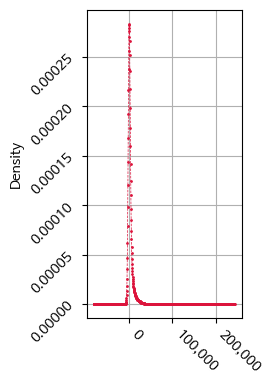


	 - Distribution: Sales volume of product,  Range _ MEAN to MAX 
       count: 33.0
      median: 2160.0
        mean: 7966.6
         std: 18172.3
         max: 80995.0
         min: 1412.0


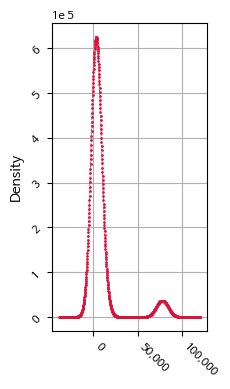

In [ ]:
vis_Distribution_quantity()
vis_Distribution_quantity(
    range_m='mean', range_M='max',
    cutoff_min = sales_volume_stat['mean'],
    stat_highlight_=['mean', 'min','std']
)


	 - Purchase Volume Variation(std): 180.80783083125107 



<center>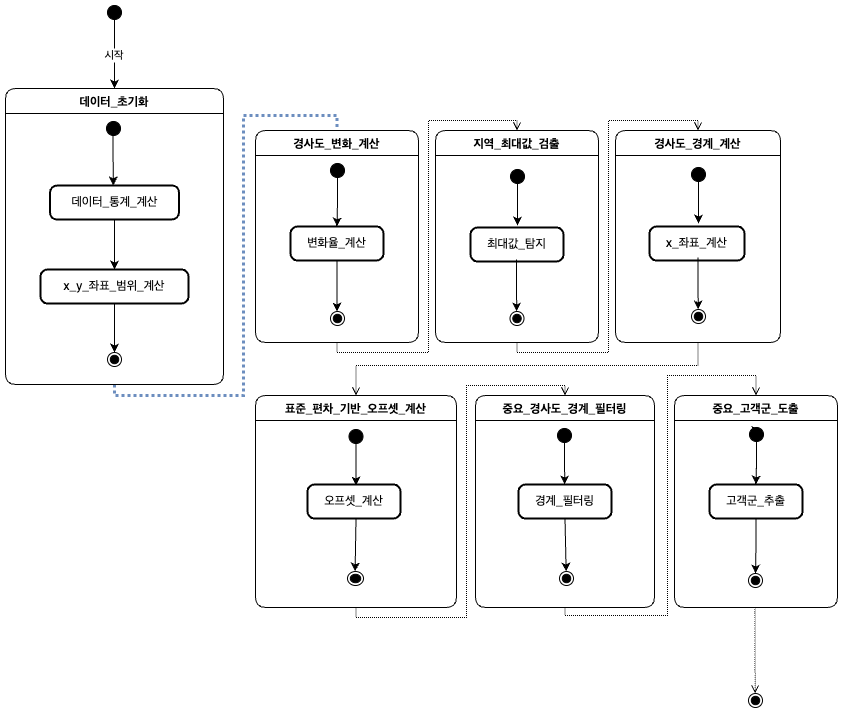</center>

1. <font size = 2>initialize_properties(data, x, y)
    * <font size = 2>클래스 초기화 메서드로, 데이터의 통계 정보를 설정하고, x와 y 좌표값을 기반으로 다양한 속성을 초기화.

    > <font size = 2>주요내용:
        - <font size = 2>Set x_lower_bound, x_upper_bound: x 좌표값의 하한선과 상한선을 설정
        - <font size = 2>Set values: y 값의 기울기(gradient)를 계산하여 설정합니다.

2. <font size = 2>find_peak_std_offset()
    * <font size = 2>표준 편차 기반의 오프셋 값을 찾는 메서드.
    > <font size = 2>내용:
        - <font size = 2>shift_by_std: 표준 편차를 이용하여 값을 이동.


3. <font size = 2>local_maxima()
    * <font size = 2>지역 최대값을 찾는 메서드.
    > <font size = 2>주요내용:
        - <font size = 2>Calculate estimated_local_maxima_count: 예상되는 지역 최대값 개수를 계산합니다.

5. <font size = 2>calculate_steep_boundaries()
    * <font size = 2>경사도의 경계값을 계산하는 메서드입니다.
    > <font size = 2>주요내용:
        - <font size = 2>Set steep_boundaries: 경사도의 경계값을 설정.

6. <font size = 2>filtering_steeps()
    * <font size = 2>경사도를 기반으로 중요한 'peak' 값을 필터링.
    > <font size = 2>주요내용:
        - <font size = 2>find_peak_std_offset(): 표준 편차 기반의 오프셋 값을 탐색
        - <font size = 2>Determine significant peaks: 정렬 및 중요한 'peak' 값을 결정.

In [ ]:
D = _df1.loc[:, 'Quantity']; data_std = D.std(); print( f'\n\t - Purchase Volume Variation(std): {data_std} \n' )


	 - Purchase Volume Variation(std): 180.80783083125107 



In [ ]:
class SteepnessDetector:
    def initialize_properties(self, data, x, y):
        self.stat_dict = data.describe().reset_index().set_index('index').T.reset_index(drop=True).to_dict('index')[0]

        self.probability_x_coords = x

        self.x_lower_bound = min(x)
        self.x_upper_bound = max(x)

        self.values = np.gradient(y, x)

    def find_peak_std_offset(self):
        def shift_by_std(i, M=self.stat_dict['mean'], S=self.stat_dict['std']*2, direction=True):
            if direction:
                return M + (S * i)
            else:
                return M - (S * i)

        std_offset_value = []
        i = 0
        direction = True
        while True:
            offset = shift_by_std(i=i, direction=direction)
            std_offset_value.append(offset)
            if direction and offset > self.x_upper_bound:
                direction = False
                i = 0
            elif not direction and offset < self.x_lower_bound:
                break

            i += 1
        return std_offset_value

    def arg_as_expected(self):
        self.values = np.asarray(self.values)
        if self.values.ndim != 1:
            raise ValueError("'Input Value' must be a 1-D array")
        return self.values

    def local_maxima(self):
        '''
            * Purpose:
                : 지역 최대값의 인덱스를 찾아 반환하는 함수

            * Returns:
                ☑️ Lef_Points : Index of the left end of the local maximum.
                ☑️ Rig_Points : Index of the right end of the local maximum.
                ☑️ Mid_Points(Peaks) : Index of the middle of the local maximum.
        '''
        X = self.arg_as_expected()

        # 입력 데이터의 크기에 기반해 지역 최대값의 예상 개수 계산
        estimated_local_maxima_count = math.trunc(X.shape[0] / 2)

        # 각 지역 최대값의 왼쪽 끝, 오른쪽 끝, 중간 인덱스를 저장할 배열 초기화
        Mid_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)
        Lef_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)
        Rig_Points = np.empty(estimated_local_maxima_count, dtype=np.intp)

        m, i = 0, 1
        imax = X.shape[0] - 1
        while i < imax:
            # 현재 값이 이전 값보다 클 때 (증가 추세)
            if X[i - 1] < X[i]:
                i_ahead = i + 1

                # 연속된 동일한 값에 대해 넘어감
                while (i_ahead < imax) and (X[i] == X[i_ahead]):
                    i_ahead += 1

                # 다음 값이 현재 값보다 작을 때 (감소 추세 -> 지역 최대값)
                if X[i_ahead] < X[i]:
                    Lef_Points[m] = i
                    Rig_Points[m] = i_ahead-1

                    Mid_Points[m] = (Lef_Points[m] + Rig_Points[m]) // 2

                    m += 1
                    i = i_ahead

            i += 1

        Mid_Points.resize(m, refcheck=False)
        Lef_Points.resize(m, refcheck=False)
        Rig_Points.resize(m, refcheck=False)

        self.Peaks = Mid_Points

        return Lef_Points, Rig_Points, Mid_Points

    def calculate_steep_boundaries(self):
        steep_boundaries = [self.probability_x_coords[i] for i in self.Peaks]
        self.steep_boundaries = steep_boundaries
        return steep_boundaries

    def filtering_steeps(self):
        '''
            * Purpose:
                : 기울기 경사도를 기반으로 중요한 'peak'값들을 필터링하는 메서드.

                    이 메서드의 핵심은 표준 편차를 이용해 데이터 분포에서 각 'peak'의 상대적 중요성을 판단하는 것입니다.
                    표준 편차는 데이터의 분포를 나타내는 통계적 지표로, 이를 통해 어떤 'peak'값이 전체 분포에서 얼마나 두드러지는지를 판단합니다.

                        1. `find_peak_std_offset` 메서드를 통해 각 'peak'의 표준 편차 기반의 offset 값 획득.
                        2. offset 값들을 기반으로 각 'peak' 값이 어느 범위에 속하는지 결정.
                        3. 해당 범위에 속하는 'peak'값 중 중요하다고 판단되는 값을 선택.

            * Returns:
                ☑️ significant_peaks: 각 범위(bin)의 번호를 key로 하고, 그 범위에 속하는 중요한 'peak'의 값을 value로 하는 딕셔너리.
        '''

        # 표준 편차에 기반한 offset 값을 계산
        std_offset_value = self.find_peak_std_offset()
        std_offset_value.sort()

        le = len(std_offset_value)

        # 범위를 저장하는 리스트 생성. 여기서 각 범위는 연속된 두 표준 편차 offset 값 사이의 범위다.
        interval_bins = [range(int(std_offset_value[i-1]), int(std_offset_value[i])) for i in range(1, le)]

        significant_peaks = {}  # 중요한 'peak'값들을 저장할 딕셔너리 초기화
        steep_boundaries_reversed = self.steep_boundaries[::-1]  # 경사도 경계값들을 역순으로 정렬

        # 각 경사도 경계값에 대해서...
        for sb in steep_boundaries_reversed:
            steep_boundarie = int(sb)

            # 해당 경사도 경계값이 어느 범위에 속하는지 확인
            group_number = np.where(list(map(lambda x: steep_boundarie in x, interval_bins)))[0][0]

            # 해당 범위에 속하는 'peak'값을 딕셔너리에 추가
            significant_peaks[group_number] = steep_boundarie

        return significant_peaks

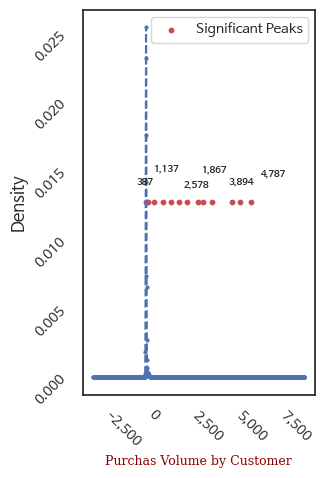

In [ ]:
mask = ( D < 5*10**4 )
filtered = D[ mask ]

# Kernel Density
plt.figure( figsize=(3, 5) )
estimate_PDF = filtered.plot.kde(
    bw_method=0.3,
    linewidth=1.5, markersize=2,
    marker='o', linestyle='dashed', color='b',
)

X, y = estimate_PDF.lines[0].get_xdata(), estimate_PDF.lines[0].get_ydata()

# Analyzing the steepness of a Kernel density estimation using the SteepnessDetector class
s_detec = SteepnessDetector()
s_detec.initialize_properties(data=D, x=X, y=y)
peaks, left_edges, right_edges = s_detec.local_maxima()
steep_boundaries = s_detec.calculate_steep_boundaries()
significant_peaks = s_detec.filtering_steeps()

# visualization
density_max   = max(y)
height = density_max * 0.5
x_coords = list(significant_peaks.values())
y_coords = [height] * len(significant_peaks)
plt.scatter(x_coords, y_coords, marker='o', color='r', s=10, label="Significant Peaks")

texts = []
for i, (x, y) in enumerate(zip(x_coords, y_coords)):
    if (i % 2 == 0) and (x > 0):
        texts.append(plt.text(x, y+0.001, f'{x:,.0f}', fontsize=7, ha='center', va='bottom', weight='bold'))
adjust_text(texts, force_points=0.2, force_text=(0.2, 0.2), expand_points=(1, 1), expand_text=(1, 1))


current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

prop = FontProperties(); prop.set_size('small')
handles, labels = plt.gca().get_legend_handles_labels()
handles_ = [handle for idx, handle in enumerate(handles) if labels[idx] != 'Quantity']
plt.legend(handles_, ['Significant Peaks'], prop=prop)

plt.xticks(rotation=-45, ha='left')
plt.yticks(rotation=45, ha='right')

plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)

plt.xlabel(
    'Purchas Volume by Customer',
    fontdict = {
        'size'  : 9,
        'family': 'serif',
        'weight': 'normal',
        'color' : 'darkred',
        }
    )

plt.show()

In [ ]:
print('\n\t\033[91m\033[1m - 고객별 구매량 분포에서 발견한 중요 판매량 지점 \033[0;0m', end=':\n ')
significant_peaks_list = list(significant_peaks.values())[::-1][1:]
for val in significant_peaks_list: print(f"\033[3m \t\t\t\t\t\t{val} \033[0;0m", end=',\n ')


'''
    - 판매량 기준 분류 조건을 저장할 딕셔너리 생성
    - 최초로 나타나는 중요한 판매량 피크 값보다 낮은 판매량을 가진 데이터를 분류하기 위한 조건
    - 중요한 판매량 피크 리스트를 순회하며, 연속적인 피크 값 사이의 판매량을 가진 데이터를 분류하기 위한 조건을 추가
'''
sales_classification_criteria = {
    f'under_{significant_peaks_list[0]}_sales' : _df1.Quantity < significant_peaks_list[0]
}
for i in range(1, len(significant_peaks_list)):
    sales_classification_criteria[f'between_{significant_peaks_list[i-1]}_{significant_peaks_list[i]}_sales'] = (
        (_df1.Quantity > significant_peaks_list[i-1]) & (_df1.Quantity < significant_peaks_list[i])
    )

print('\n\t\033[91m\033[1m - 중요 판매량 지점으로 고객 ID 군집을 생성 \033[0;0m', end=':\n ')
criteriaKeys = list(sales_classification_criteria.keys())
for key in criteriaKeys: print(f"\033[3m \t\t\t\t\t\t{key} \033[0;0m", end=',\n ')


	 - 고객별 구매량 분포에서 발견한 중요 판매량 지점 :
  						89 ,
  						387 ,
  						791 ,
  						1137 ,
  						1482 ,
  						1867 ,
  						2386 ,
  						2578 ,
  						2981 ,
  						3894 ,
  						4288 ,
  						4787 ,
 
	 - 중요 판매량 지점으로 고객 ID 군집을 생성 :
  						under_89_sales ,
  						between_89_387_sales ,
  						between_387_791_sales ,
  						between_791_1137_sales ,
  						between_1137_1482_sales ,
  						between_1482_1867_sales ,
  						between_1867_2386_sales ,
  						between_2386_2578_sales ,
  						between_2578_2981_sales ,
  						between_2981_3894_sales ,
  						between_3894_4288_sales ,
  						between_4288_4787_sales ,
 

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/PulLv2TShL.png" width = "170">



<font color = 'white'><font size = 2>**"가격이 저렴할수록 적정량 구입을 주기적으로 진행할 것이다."** 에 대한 회귀계수 유의성 검정(단측검정)에 대해, 유의수준 0.05(5%)에 대한 각 유의 확률 (-1.1341156342551404, 0.2568180208905173) 모두 통계적으로 유의하지 않음으로 귀무가설을 기각할 수 없습니다.</font>

<font color = 'white'><font size = 2>**"즉, 낮은 단가가 주기적 구매양상에 간접적 영향을 미친다고 볼 수 없다"** 라고 해석할 수 있습니다.</font>


---

In [ ]:
from IPython.display import display, HTML, Javascript

# Visualization
def display_datatables(dfs, titles, significantPeriodsInfo, rows_per_page=18, font_size='10px'):
    global data_KeyTimeRanges
    display(HTML("""
        <link rel="stylesheet" type="text/css" href="https://cdn.datatables.net/1.10.21/css/jquery.dataTables.css">
        <script type="text/javascript" charset="utf8" src="https://code.jquery.com/jquery-3.5.1.min.js"></script>
        <script type="text/javascript" charset="utf8" src="https://cdn.datatables.net/1.10.21/js/jquery.dataTables.js"></script>
    """))

    dropdown_html = "<div style='margin-left: 10px; margin-top: 40px; margin-bottom: 40px; display: inline-block;'>"
    dropdown_html += "<span style='font-weight: normal; color: #6A5ACD; font-size: 10px; display: block; margin-bottom: 5px;'>데이터 항목을 선택하세요</span>"
    dropdown_html += "<select id='datatableDropdown' style='font-style: italic; padding: 10px; border: dashed 1px blue; border-radius: 5px; text-align:center;' onchange='showSelectedDatatable()'>"

    for key in dfs.keys():
        title = titles[key].split()
        title = f"* {title[0]}  &rarr;  {title[3]}"
        dropdown_html += f"<option value='{key}'>{title}</option>"
    dropdown_html += "</select></div>"

    display(HTML(dropdown_html))
    display(HTML("""
        <style>
            .datatableDiv {
                display: none;
            }
            .stats-datatable th, .stats-datatable td {
                font-size: 12px;
            }
        </style>
        <script>
            function showSelectedDatatable() {
                var selected = document.getElementById("datatableDropdown").value;
                var tables = document.getElementsByClassName("datatableDiv");
                for(var i=0; i<tables.length; i++) {
                    if(tables[i].id == selected) {
                        tables[i].style.display = "block";
                    } else {
                        tables[i].style.display = "none";
                    }
                }
            }
        </script>
    """))

    first_key = list(dfs.keys())[0]
    for key, data in dfs.items():
        data = data.sort_values(by="repurchaseDates")
        column_names = list(data.columns)

        # Data Describe
        stats = list(map(lambda x: [np.nan]*2 + list(x) + [np.nan], data.describe().loc[['mean', 'std']].iloc[:, 1:].values))
        stats_ = stats + [[np.nan]*(len(column_names)) + [f"{len(data):.0f}"]]
        stats_df = pd.DataFrame(stats_,
                                columns = column_names + [''],
                                index = ['Mean', 'Std','dataSize'])
        stats_html = stats_df.to_html(classes='stats-datatable', border=1)

        fig       = plt.figure(figsize=(7, 7))
        grid_spec = plt.GridSpec(2, 1, height_ratios=[2, 1])

        ax0 = plt.subplot(grid_spec[0, :])
        sns.scatterplot(
            data=data, x="repurchaseDates", y="Purchase_Growth",
            marker='+',
            color='b',
            alpha = 0.5,
            ax=ax0
            )

        # lowess
        smoothed = lowess(data['Purchase_Growth'], range(len(data)), frac=0.3)
        dates, data_smoothed = data['repurchaseDates'], smoothed[:, 1]
        ax0.plot(dates, data_smoothed, color='red', label="LOWESS Smoothing")

        # vline
        auto_corr_dates = significantPeriodsInfo[key]['verified_auto_corr']['periods_merged']
        linearity_dates = significantPeriodsInfo[key]['linear_fit_details']['periods_merged']

        iter, step = 1, 0
        xycoords, textcoords, xytext, ha, fontsize, rotation = ('data', 'axes fraction'), 'offset points', (0, 5), 'center', 7, 90
        colorB,colorE  = ('b', 'crimson')
        for d_cor, d_lin in zip(auto_corr_dates, linearity_dates):
            for i in range(2):
                if i == 0:
                    x_TXT = ax0.annotate(
                        f'Begin of Linear Trend at {pd.to_datetime(d_lin[i]).strftime("%Y-%m-%d")}',
                        xy=(d_lin[i], 1.005), xycoords=xycoords,
                        textcoords=textcoords, xytext=xytext,
                        ha=ha, fontsize=fontsize, color=colorB,
                        rotation=rotation
                        )
                    Alpha = 1
                else:
                    x_TXT = ax0.annotate(
                        f'End of Linear Trend at {pd.to_datetime(d_lin[i]).strftime("%Y-%m-%d")}',
                        xy=(d_lin[i], 1.07), xycoords=xycoords,
                        textcoords=textcoords, xytext=xytext,
                        ha=ha, fontsize=fontsize, color=colorE,
                        rotation=rotation

                        )
                    Alpha = 0.5

                last_box, buffer_factor = None, 0.01
                renderer = fig.canvas.get_renderer()

                bounding_box = x_TXT.get_window_extent(renderer).transformed(ax0.transData.inverted())
                bounding_box_add_buffer = bounding_box.from_bounds(
                    bounding_box.x0,
                    bounding_box.y0,
                    bounding_box.width * buffer_factor,
                    bounding_box.height * buffer_factor
                )

                if (last_box is not None) and (bounding_box_add_buffer.overlaps(last_box)):
                    new_yoffset = x_TXT.get_position()[1] + 30
                else:
                    new_yoffset = x_TXT.get_position()[1]

                x_TXT.set_position((3, new_yoffset))
                last_box = bounding_box_add_buffer

                if step == 0:
                    ax0.axvline(d_cor[i], color='purple', linestyle='--', alpha=Alpha, label="Temporal Autocorrelation Group")
                    ax0.axvline(d_lin[i], color='y', linestyle='--', alpha=Alpha, label="Linear Trend Cluster")
                else:
                    ax0.axvline(d_cor[i], color='purple', linestyle='--', alpha=Alpha)
                    ax0.axvline(d_lin[i], color='y', linestyle='--', alpha=Alpha)
                step += 1
            iter += 1

        ax0.set_xticklabels("")
        ax0.set_yticklabels(ax0.get_yticks(), rotation=45, fontsize=7)
        ax0.set_xlabel(xlabel="", fontsize=8); ax0.set_ylabel(ylabel="재구매 시점의 구매량 상승 분석(Purchase Growth)", fontsize=9)
        ax0.legend(fontsize='x-small')

        # 하단에 추가로 그릴 그래프들의 공간 확보
        ax1 = plt.subplot(grid_spec[1, :])

        linear_fit_details = significantPeriodsInfo[key]['linear_fit_details']
        if 'StrongLinearPhase' in linear_fit_details:
            linearity_dates = linear_fit_details['StrongLinearPhase']

        data_KeyTimeRanges = data[(data['repurchaseDates'] >= linearity_dates[0]) & (data['repurchaseDates'] <= linearity_dates[1])]
        Previous2Weeks     = data[(data['repurchaseDates'] >= (linearity_dates[0] - np.timedelta64(14,'D'))) & (data['repurchaseDates'] < linearity_dates[0])]
        data_Next2Weeks    = data[(data['repurchaseDates'] > linearity_dates[1]) & (data['repurchaseDates'] <= (linearity_dates[1] + np.timedelta64(14,'D')))]

        sns.scatterplot(data=data_KeyTimeRanges, x="repurchaseDates", y="Purchase_Growth",
            marker='+',
            color='crimson',
            alpha = 0.5,
            ax=ax1
            )
        for subData in [Previous2Weeks, data_Next2Weeks]:
            sns.scatterplot(data=subData, x="repurchaseDates", y="Purchase_Growth",
                marker='+',
                color='b',
                alpha = 0.2,
                ax=ax1
                )

        smoothed = lowess(data_KeyTimeRanges['Purchase_Growth'], range(len(data_KeyTimeRanges)), frac=1)
        dates, data_smoothed = data_KeyTimeRanges['repurchaseDates'], smoothed[:, 1]
        ax1.plot(dates, data_smoothed,
                 linestyle='dashed',
                 linewidth=0.5,
                 color='crimson')

        ax1.set_title('')
        ax1.set_yticklabels(ax1.get_yticks(), rotation=45, fontsize=7)
        ax1.set_ylabel(ylabel='')
        ax1.set_xticks(data_KeyTimeRanges.repurchaseDates)
        ax1.set_xticklabels(data_KeyTimeRanges.repurchaseDates.dt.strftime("%Y-%m-%d"))

        currentXTicks, currentXLabels = ax1.get_xticks(), ax1.get_xticklabels()
        newXTicks = np.insert(currentXTicks, 0, currentXTicks[0]-10)
        newXTicks = np.append(newXTicks, currentXTicks[-1]+10)
        newXLabels = ['Previous2Weeks <<  '] + [label.get_text() for label in currentXLabels] + [ ' >> Next2Weeks']

        ax1.set_xticks(newXTicks)
        ax1.set_xticklabels(newXLabels, rotation=-45, fontsize=7, fontweight='bold')

        getLabels = ax1.get_xticklabels()
        for i, xlabel in enumerate(getLabels):
            if (i == 0) or (i == len(getLabels)-1):
                xlabel.set_rotation(0)
                xlabel.set_color('darkgrey')
            else:
                xlabel.set_rotation(-45)
                xlabel.set_color('black')

        ax1.set_xlabel(
            xlabel="Highlighting Maximum Linear Growth in Repurchase Growth",
            fontdict = {
                'size'  : 9,
                'family': 'serif',
                'weight': 'normal',
                'color' : 'darkred',
                }
        )

        for i, w in zip(range(2), [1, 0.5]):
            xyA, xyB = (linearity_dates[i], ax0.get_ylim()[0]), (linearity_dates[i], ax1.get_ylim()[1])
            conAB  = ConnectionPatch(xyA=xyA, xyB=xyB, axesA=ax0, axesB=ax1,
                                    coordsA="data", coordsB="data",
                                    linewidth=w, color="y", linestyle='--', arrowstyle="->")
            ax0.add_artist(conAB)

        plt.subplots_adjust(wspace=0.3) # hspace=0.9
        plt.tight_layout(pad=3)

        buf = BytesIO()
        plt.savefig(buf, format="png")
        buf.seek(0)
        img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')
        buf.close()

        chart_html = f'<img src="data:image/png;base64,{img_base64}" />'
        plt.close()

        #;
        dfP   = copy.copy(Previous2Weeks);
        dfP   = dfP.set_index('CustomerID');

        dfP.columns = ["·"*len(dfP.columns[i]) for i in range(len(dfP.columns))]

        Title = "Previous2Weeks"
        dfP.index = pd.MultiIndex.from_product([[Title], dfP.index], names=['', 'CustomerID'])

        dfP_html = dfP.to_html(classes='datatable')
        dfP_html = dfP_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfP_html = dfP_html.replace('<td>', f'<td style="font-size:{font_size};">')

        #;
        dfMain = copy.copy(data_KeyTimeRanges)
        dfMain = dfMain.set_index('CustomerID')

        Title = 'KeyTimeRanges'
        dfMain.index = pd.MultiIndex.from_product([[Title], dfMain.index], names=['', 'CustomerID'])

        dfMain_html = dfMain.to_html(classes='datatable')
        dfMain_html = dfMain_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfMain_html = dfMain_html.replace('<td>', f'<td style="font-size:{font_size};">')

        #;
        dfNext = copy.copy(data_KeyTimeRanges)
        dfNext = dfNext.set_index('CustomerID')

        Title = "Next2Weeks"
        dfNext.index = pd.MultiIndex.from_product([[Title], dfNext.index], names=['', 'CustomerID'])

        dfNext.columns = ["·"*len(dfNext.columns[i]) for i in range(len(dfNext.columns))]
        dfNext_html = dfNext.to_html(classes='datatable')
        dfNext_html = dfNext_html.replace('<th>', f'<th style="font-size:{font_size};">')
        dfNext_html = dfNext_html.replace('<td>', f'<td style="font-size:{font_size};">')

        display_style = "block" if key == first_key else "none"
        display(HTML(f"""
            <div id='{key}' class='datatableDiv' style='margin-bottom: 30px; display: {display_style};'>
                <h2 style='font-family:Arial; color: #6A5ACD; font-size: 13px; margin-bottom: 10px;'>{titles[key]}</h2>
                <div class='stats-container' style="background-color: rgba(75, 0, 130, 0.2); border: 1px solid #ccc; padding: 20px; margin-bottom: 30px; display: inline-block; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);">
                    {stats_html}
                </div>
                <div style='display: flex; flex-direction: row; justify-content: space-between;'>
                    <div style='display: flex; flex-direction: row; justify-content: space-between;'>
                        <div style='display: flex; flex-direction: column; gap: 20px; width: 70%;'>
                            <button class="customToggleBtn" onclick="toggleContent('{key}_dfP')">View Data from Previous 2 Weeks ⤴</button>
                            <div id='{key}_dfP' class='main_data_container' style='display: none; background-color: rgba(255, 255, 0, 0.2); border: 2px solid grey; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfP_html}
                            </div>
                            <div class='main_data_container' style='background-color: rgba(255, 255, 0, 0.2); border: 2px solid red; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfMain_html}
                            </div>
                            <button class="customToggleBtn" onclick="toggleContent('{key}_dfNext')">Explore Data for Upcoming 2 Weeks ⤵</button>
                            <div id='{key}_dfNext' class='main_data_container' style='display: none; background-color: rgba(255, 255, 0, 0.2); border: 2px solid grey; padding: 20px; border-radius: 10px; box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);'>
                                {dfNext_html}
                            </div>
                        </div>
                    <div class='bar-container' style='flex-grow: 1; padding-left: 30px;'>
                        {chart_html}
                    </div>
                </div>
            </div>
        """))

    display(HTML("""
        <style>
            .customToggleBtn {
                padding: 8px 12px;
                color: #808080;
                background-color: transparent;
                border: 2px dashed #6A5ACD;
                border-radius: 8px;
                cursor: pointer;
                margin-right: 5px;
                font-weight: bold;
                font-style: italic;
                transition: all 0.3s;
            }
            .customToggleBtn:hover {
                background-color: #f0f0f0;
            }
        </style>

        <script type="text/javascript">
            function toggleContent(contentId) {
                var content = document.getElementById(contentId);
                if (content.style.display === "none") {
                    content.style.display = "block";
                } else {
                    content.style.display = "none";
                }
            }
            $(document).ready(function() {
                $('.datatable').DataTable({
                    "pageLength": {rows_per_page}
                });
                showSelectedDatatable();
            });
        </script>
    """))


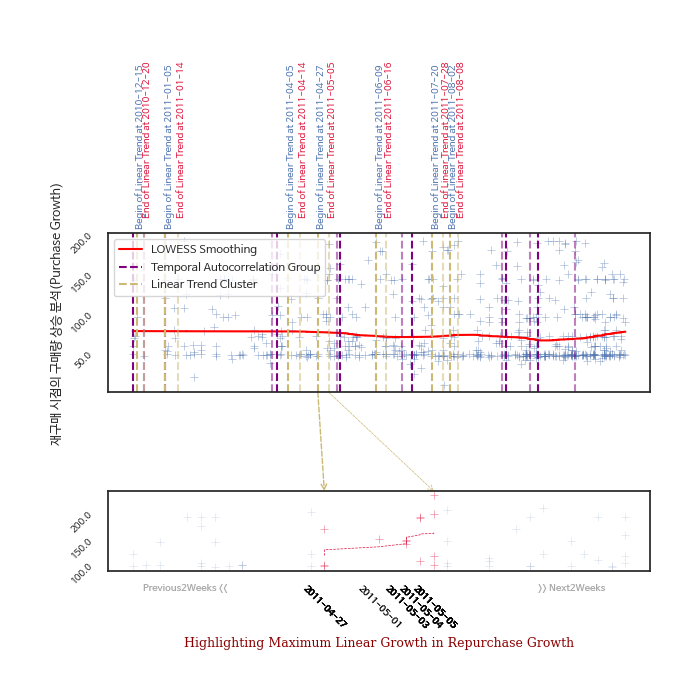


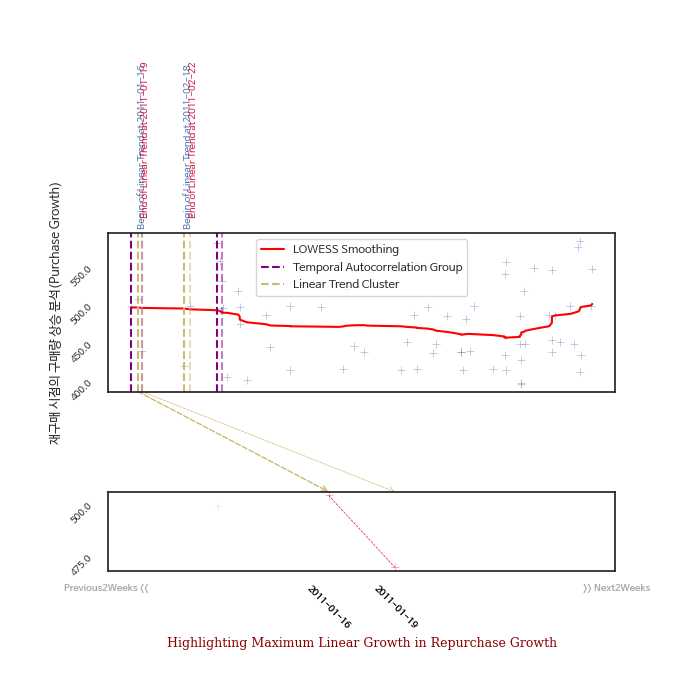


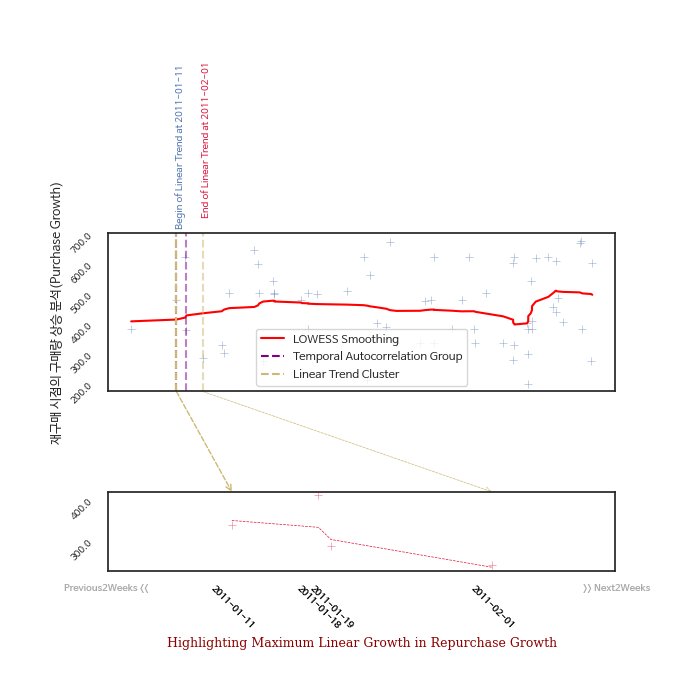

In [ ]:
extracted = _df1.loc[:, ['CustomerID', 'StockCode', 'Quantity', 'Inv_date']]
extracted = extracted.rename(
    columns = {'Inv_date': 'Purchase_date'}
)

extracted_aggregated = extracted.groupby(['CustomerID', 'Purchase_date'], as_index=False).agg(
    {
        'Quantity':'sum',
        'Purchase_date':'first'
        }
    )

def calculate_growth_and_find_optimal(i, j, extracted, sales_classification_criteria, criteriaKeys, isFirstPair):

    """

        [ 분석의 개요 ]
                - 해당 함수는 주어진 두 구매량 그룹의 판매량 증가량을 계산합니다.
                - 또한, 고객별 최적의 판매량 증가를 확인하기 위한 분석도 수행합니다.
                - 고객들이 한 판매량 그룹에서 *다른 판매량 그룹으로 전환될 때의 구매 성장률을 분석하기 위함입니다.

        [ 가능한 적용 ]
                - 기업은 고객들이 어떠한 판매량 그룹에서 다른 판매량 그룹으로 얼마나 빠르게 전환되는지, 그리고 그 전환을 통해 얼마나 많은 판매량 증가가 발생하는지 파악하기 원합니다.
                - 이를 통해, 시장 내에서의 고객의 구매 패턴 변화나 선호도의 증가 등의 현상을 분석할 수 있습니다.

        [ 파라미터 설명 ]
                - i, j: 판매량 그룹 인덱스
                - extracted: 고객ID, 상품코드, 구매량, 구매 날짜 정보가 들어 있는 데이터프레임
                - sales_classification_criteria: 판매량 그룹을 분류하는 조건들의 딕셔너리
                - criteriaKeys: 판매량 그룹의 키 목록
                - isFirstPair: 첫 번째 판매량 그룹 페어인지의 여부 (bool)

        [ 주요 계산 로직 ]

                1. 두 판매량 그룹의 데이터를 병합(merge)합니다.
                   : 이를 통해 같은 고객이 어떻게 다른 판매량 그룹에서 구매하는지를 분석할 수 있습니다.

                2. 두 구매 사이의 날짜 차이(Days_Between_Rebuy)를 계산하여 새로운 열로 추가합니다.
                   : 고객이 얼마나 빠르게 한 판매량 그룹에서 다른 판매량 그룹으로 전환되는지 분석하는 데 사용됩니다.

                3. 판매량의 성장률(Purchase_Growth)을 계산하여 새로운 열로 추가합니다.
                   : 얼마나 많은 판매량 증가가 있는지를 파악하기 위해 사용됩니다.

                4. 고객별로 최대 판매량 성장률을 가진 데이터를 추출합니다.
                   : 이를 통해 각 고객별로 어떤 판매량 그룹 전환에서 최대의 판매량 증가가 발생하는지 파악할 수 있습니다.

        [ 반환하는 결과 ]
                - 판매량 그룹 페어의 이름(key_name), 판매량 증가 데이터(customer_sales_by_peak_criteria), 최적의 판매량 증가 데이터(optimal_growth_per_customer), 제목(title)을 반환합니다.

    """

    # 두 판매량 그룹 간의 데이터를 병합하여 고객별 구매 패턴을 분석합니다.
    customer_sales_by_peak_criteria = extracted[
        sales_classification_criteria[criteriaKeys[i]]
        ].merge(
            extracted[
                sales_classification_criteria[criteriaKeys[j]]],
                on='CustomerID', how='left'
                ).dropna().query("Purchase_date_x < Purchase_date_y").reset_index(drop=True)
    customer_sales_by_peak_criteria = customer_sales_by_peak_criteria.rename(
        columns={
            'StockCode_x'     :'StockCode',
            'Quantity_x'      :'Initial_Purchase_Quantity',
            'Purchase_date_y' : 'repurchaseDates'
            }
        )

    # 두 구매 사이의 날짜 차이를 계산하여, 고객이 판매량 그룹을 얼마나 빠르게 전환하는지 파악합니다.
    customer_sales_by_peak_criteria['Days_Between_Rebuy'] =  (customer_sales_by_peak_criteria['repurchaseDates'] - customer_sales_by_peak_criteria['Purchase_date_x']).dt.days

    # 판매량의 증가량을 계산하여, 고객이 어떤 판매량 그룹 전환에서 얼마나 많은 판매량 증가를 보이는지 분석합니다.
    customer_sales_by_peak_criteria['Purchase_Growth'] = customer_sales_by_peak_criteria['Quantity_y'] - customer_sales_by_peak_criteria['Initial_Purchase_Quantity']
    customer_sales_by_peak_criteria = customer_sales_by_peak_criteria.iloc[:, [0,1,2, -1,-2,-3]]

    # 고객별 최대 판매량 성장률을 계산하여, 각 고객이 어떤 판매량 그룹 전환에서 가장 높은 성장률을 보이는지 파악합니다.
    best_growth_indices = customer_sales_by_peak_criteria.groupby('CustomerID')['Purchase_Growth'].idxmax()
    optimal_growth_per_customer = customer_sales_by_peak_criteria.loc[best_growth_indices].sort_values(by=['repurchaseDates'])

    key_name = f'Rebuy_{criteriaKeys[i]}_to_{criteriaKeys[j]}'
    title = f"{criteriaKeys[i]} 구매량 그룹에서 {criteriaKeys[j]} 구매량 그룹으로 이동 - 시장 선호도(Market Preference)가 상승"

    return key_name, customer_sales_by_peak_criteria, optimal_growth_per_customer, title

def Identify_and_merge_market_interest_periods(Input = input):
    """
        [ 주요 계산 로직 ]

                1. 본 분석에서의 Durbin-Watson test 결과는 특별한 상황입니다.
                일반적으로 자기상관성은 예측의 어려움을 의미할 수 있으나, 이 경우에는 시장 선호도를 반영하는 중요한 신호로 해석됩니다.
                즉, 특정 기간 동안 일관된 성장과 유사한 특성을 나타내는 주요 지표로 볼 수 있습니다.

                2. 회귀모델의 p-value가 0.05보다 작은 구간, 즉. 통계적으로 유의한 선형 관계 여부를 탐지하며, *본 분석에서는 해당 현상을 시장(서비스)에 대한 전반적인 관심도가 상승된 것으로 간주합니다.

    """
    def merge_overlapping_periods(significant_windows, syncedValue, synced=False):
        """
            * 함수 'merge_overlapping_periods'는, 입력된 날짜 기간 목록에서 서로 중첩되는 기간들을 찾아 하나의 연속된 기간으로 병합하고, 중첩되지 않는 기간들은 그대로 유지한 새로운 목록을 반환하는 함수입니다.
        """
        while True:
            isOverlapping_cnt = 0
            le = len(significant_windows)

            for i in range(1, le):
                combind_period = [significant_windows[i-1], significant_windows[i]]
                startDates, endDates = zip(*combind_period)
                if (combind_period[0][0] <= combind_period[1][1]) and (combind_period[1][0] <= combind_period[0][1]):
                    significant_windows[i-1] = np.nan
                    if synced:
                        syncedValue[i]   = (syncedValue[i] + syncedValue[i-1]) / 2
                        syncedValue[i-1] = np.nan

                    significant_windows[i] = [min(startDates), max(endDates)]

                    isOverlapping_cnt += 1

            significant_windows = list(filter(lambda x: type(x) != float, significant_windows))
            if synced: syncedValue = list(filter(lambda x: type(x) != float, syncedValue))
            if isOverlapping_cnt == 0:
                significant_windows_ret = copy.copy(significant_windows)
                syncedValue_ret = copy.copy(syncedValue)
                break

        if synced:
            return significant_windows_ret, syncedValue
        else:
            return significant_windows_ret


    earliestRepurchase, latestRepurchase = Input['repurchaseDates'][:1].values[0], Input['repurchaseDates'][-1:].values[0]

    dataRange = pd.Series(pd.date_range(earliestRepurchase, latestRepurchase, freq='D'))
    missingDates = dataRange[~dataRange.isin(Input['repurchaseDates'])]

    missingDatesDf = pd.DataFrame(
        {
            'repurchaseDates': missingDates,
        }
    ); dfWithNulls = pd.concat([Input, missingDatesDf], axis=0).sort_values(by='repurchaseDates').reset_index(drop=True)

    verified_auto_corr = {
        'significant_periods': [],
    }
    linear_fit_details = {
        'significant_periods': [],
        'linearity_strength'   : [],
    }
    window_size = 14
    for start in range(0, len(Input)-window_size):
        window_data      = dfWithNulls.iloc[start:start+window_size, :].dropna().reset_index(drop=True)
        if len(window_data) > 1:
            valid_date_range = [window_data['repurchaseDates'][:1].values[0], window_data['repurchaseDates'][-1:].values[0]]

            '''
                - slope: 회귀분석의 결과로, 재구매 시 상승된 구매량의 변화량.
                - R_squared: 선형특성의 strength 및 방향을 측정 -1과 1은 완벅한 음, 양의 선형관계를 의미하며, 0은 선형관계가 없음을 의미. (상관계수, 범위: (-1 < value < 1))
                - p-value(the hypothesis test on the slope): 0.05보다 작은 값이어야 기울기가 0과 유의하게 다름을 의미.
                - error_of_the_estimated_slope: 추정 기울기의 "표준오차"이며, "표준오차"는 작을수록 추정치가 정확함을 의미.
            '''
            slope, starting_value, R_squared, p_value, error_of_the_estimated_slope = linregress(range(len(window_data)), window_data.Purchase_Growth)

            Residuals = window_data.Purchase_Growth - (starting_value + slope * np.arange(len(window_data)))
            DW_result = durbin_watson(Residuals)
            if (DW_result < 1.5) or (DW_result > 2.5): verified_auto_corr['significant_periods'].append(valid_date_range)
            elif p_value < 5/(10**2):
                linear_fit_details['significant_periods'].append(valid_date_range)
                linear_fit_details['linearity_strength'].append(R_squared)

    verified_auto_corr['periods_merged'] = merge_overlapping_periods(
        verified_auto_corr['significant_periods'],
         [], synced=False)
    linear_fit_details['periods_merged'], linear_fit_details['linearity_strength'] = merge_overlapping_periods(
        linear_fit_details['significant_periods'],
        linear_fit_details['linearity_strength'],
        synced=True
        )

    strength, dates = linear_fit_details['linearity_strength'], linear_fit_details['significant_periods']
    try:
        strength_ = list(filter(lambda x: x<1, strength))
        if sum(map(lambda x: x>0, strength_)):
            linear_fit_details['StrongLinearPhase'] = linear_fit_details['periods_merged'][strength_.index(max(strength_))]
        else:
            linear_fit_details['StrongLinearPhase'] = linear_fit_details['periods_merged'][strength_.index(min(strength_))]
    except:
        pass

    return verified_auto_corr, linear_fit_details

num_criteriaKeys = len(criteriaKeys)
pairs = [(i, j) for i in range(num_criteriaKeys-1) for j in range(i+1, num_criteriaKeys)]

with Pool(processes=mp.cpu_count()) as pool:
    results = pool.starmap(calculate_growth_and_find_optimal, [(i, j, extracted, sales_classification_criteria, criteriaKeys, pairs.index((i, j)) == 0) for i, j in pairs])

dfs, dfsBestgrowth, titles = {}, {}, {}
significantPeriodsInfo = {}

for key_name, df, optimal_growth_per_customer, title in results:
    if len(df) > 3: dfs[key_name] = df
    if len(optimal_growth_per_customer) > 3:
            verified_auto_corr, linear_fit_details = Identify_and_merge_market_interest_periods(Input=optimal_growth_per_customer)

            # 2주. 14일씩 탐색하여, 구매의 성장률이 선형성을 띄는 기간이 탐지되는(not empty) '구매량 상승 고객그룹'만을 유의미한 데이터셋으로 취급합니다.
            if  (len(verified_auto_corr['periods_merged']) > 0) & (len(linear_fit_details['periods_merged']) > 0):
                significantPeriodsInfo[key_name] = {
                    'verified_auto_corr' : verified_auto_corr,
                    'linear_fit_details' : linear_fit_details
                    }
                titles[key_name] = title; dfsBestgrowth[key_name] = optimal_growth_per_customer;

display_datatables(dfsBestgrowth, titles, significantPeriodsInfo)

In [ ]:
importantRebuyKey = 'Rebuy_under_89_sales_to_between_89_387_sales'
dfBestgrowth = dfsBestgrowth[importantRebuyKey].reset_index( drop=True )

earliestRepurchase, latestRepurchase = dfBestgrowth['repurchaseDates'].iloc[:1].values[0], dfBestgrowth['repurchaseDates'].iloc[-1:].values[0]
extracted_ = extracted[(extracted['Purchase_date'] >= earliestRepurchase) & (extracted['Purchase_date'] <= latestRepurchase)]

In [ ]:
i = 2

In [ ]:
earliestAutocorr, latestAutocorr = significantPeriodsInfo[importantRebuyKey]['verified_auto_corr']['periods_merged'][i]
extracted_ByAutocorr = extracted_[(extracted_.Purchase_date >= earliestAutocorr) & (extracted_.Purchase_date <= latestAutocorr)]

dataRange      = pd.Series(pd.date_range(earliestAutocorr, latestAutocorr, freq='D'))
missingDates   = dataRange[~dataRange.isin(extracted_ByAutocorr['Purchase_date'])]
missingDatesDf = pd.DataFrame(
    {
        'Purchase_date': missingDates,
    }
); ByAutocorrWithNulls = pd.concat([extracted_ByAutocorr, missingDatesDf], axis=0).sort_values(by='Purchase_date').reset_index(drop=True)

def between_Loess_Curve(In, targetY, targetX):
    '''
        [ 주요 계산 로직 ]
            - 데이터의 결측값을 로에스(Loess) 기법으로 예측하고, 그 결과를 다시 선형보간하여 결측값을 예측합니다.
    '''
    non_na = In[In[targetY].notna()]

    targetInterpol = targetY + '_'
    Predicted = pd.DataFrame(lowess(non_na[targetY], non_na[targetX], frac=0.3), columns=[targetX, targetInterpol])
    Predicted[targetX] = pd.to_datetime(Predicted[targetX], unit='ns')

    ret = pd.merge(In, Predicted, on=targetX, how='left')
    ret[targetInterpol] = ret[targetInterpol].interpolate(method='linear', limit_direction='forward')
    ret[targetY].fillna(ret[targetInterpol], inplace=True)
    ret.drop(targetInterpol, axis=1, inplace=True)

    return ret

ByAutocorrInterpolated = between_Loess_Curve(In=ByAutocorrWithNulls, targetY='Quantity', targetX='Purchase_date')
ByAutocorrInterpolated

<font color = 'white'>.</font>

<center><font color = 'pink'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

<font size = 2></font>

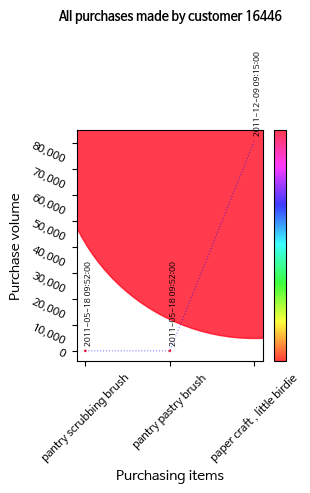

In [ ]:
customer16446_info = _df1[_df1.CustomerID == 16446].loc[:, ['Description', 'Quantity', 'InvoiceDate']]
customer16446_info['magnitude'] = customer16446_info.Quantity / 10 ** 3

axes = customer16446_info.plot.scatter(
    x='Description',
    y='Quantity',
    c='magnitude',
    s='Quantity',
    cmap='hsv',
    alpha=0.77,
    figsize=(3, 3)
    );
axes_1 = customer16446_info.plot(
    x='Description',
    y='Quantity',
    ax=axes,
    legend=False,
    linestyle=':',
    color='b',
    linewidth=0.8,
    alpha=0.5
    );

arr = customer16446_info.values
for x in range(len(arr)):
    values = arr[x]
    axes.text(values[0], values[1]+10**3*3, values[2], ha='left', rotation=90, fontsize=6)

axes.tick_params(axis='x', labelsize=8, rotation=45)
axes.tick_params(axis='y', labelsize=8, rotation=-25)

import matplotlib.ticker as mticker
axes.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

axes.set_ylabel('Purchase volume')
axes.set_xlabel('Purchasing items')
color_map_info = axes.collections[0].colorbar
color_map_info.set_label('')
color_map_info.set_ticks([])

axes.set_title("All purchases made by customer 16446",
               pad=80,
               fontdict={
                  'fontsize':9,
                  'fontweight':'bold'
                  }
               ); plt.show()

In [ ]:
drop_pos = customer16446_info.index[-1]
_df1 = _df1.drop(drop_pos).reset_index( drop=True )

<font color = 'white'>.</font>

<center><font color = 'red'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>


## <font size = 3>Cohort analysis</font>

### <font size = 3>Cohort analysis_ 1. Retention rate</font>

<!DOCTYPE html>
<html>

<head>
    <meta charset="utf-8" />
    <meta http-equiv="X-UA-Compatible" content="IE=edge">
    <meta name="viewport" content="width=device-width, initial-scale=1">
</head>

<body>
    <img src="https://www.customerthermometer.com/img/customer-retention-formula-1500x560.jpg" width="500">
</body>

</html>



In [ ]:
_df1['get_YearMonth'] = _df1['InvoiceDate'].apply(lambda x: datetime(x.year, x.month, 1))
_df1['dt_Firstpurchase'] = _df1.groupby('CustomerID')['get_YearMonth'].transform('min')

_df1.loc[:, ['get_YearMonth', 'dt_Firstpurchase']].head(2)

,get_YearMonth,dt_Firstpurchase
0,2010-12-01,2010-12-01
1,2010-12-01,2010-12-01


In [ ]:
cohort_TargetcolL = ['get_YearMonth', 'dt_Firstpurchase']
_df1['Y'], _df1['M'], _df1['D1'] = pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).year, pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).month, pd.DatetimeIndex(_df1[cohort_TargetcolL[0]]).day
_df1['F_purche_Y'], _df1['F_purche_M'], _df1['F_purche_D1'] = pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).year, pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).month, pd.DatetimeIndex(_df1[cohort_TargetcolL[1]]).day

_df1.iloc[:, -7:].head(2)

,dt_Firstpurchase,Y,M,D1,F_purche_Y,F_purche_M,F_purche_D1
0,2010-12-01,2010,12,1,2010,12,1
1,2010-12-01,2010,12,1,2010,12,1


In [ ]:
Y_interval = _df1['Y'] - _df1['F_purche_Y']
M_interval = _df1['M'] - _df1['F_purche_M']

_df1['cohort_M_period'] = 12*Y_interval+M_interval+1

cohort_df = _df1.groupby(['cohort_M_period', 'dt_Firstpurchase'])['CustomerID'].nunique().reset_index()
cohort_df.head(2)

,cohort_M_period,dt_Firstpurchase,CustomerID
0,1,2010-12-01,884
1,1,2011-01-01,416


In [ ]:
cohort_pivot = cohort_df.pivot(index='dt_Firstpurchase', columns='cohort_M_period', values='CustomerID')
cohort_Retentionrt = cohort_pivot.divide(cohort_pivot.iloc[:, 0], axis=0)
cohort_Retentionrt = cohort_Retentionrt.set_index(cohort_Retentionrt.index.strftime("%Y-%m"))

data_table.DataTable(cohort_Retentionrt.applymap(lambda x: str(round(x*100, 2))+'%' if pd.notnull(x) else ''), include_index=True, num_rows_per_page=13)

cohort_M_period,1,2,3,4,5,6,7,8,9,10,11,12,13
dt_Firstpurchase,,,,,,,,,,,,,
2010-12,100.0%,36.54%,32.35%,38.35%,36.2%,39.82%,36.2%,34.84%,35.29%,39.48%,37.33%,50.23%,26.47%
2011-01,100.0%,21.88%,26.68%,22.84%,31.73%,28.85%,24.76%,24.04%,29.57%,32.69%,36.54%,11.78%,
2011-02,100.0%,18.68%,18.68%,28.68%,27.11%,24.47%,25.53%,27.37%,24.74%,30.53%,6.84%,,
2011-03,100.0%,14.82%,25.22%,19.91%,22.35%,16.81%,26.77%,23.01%,27.88%,8.63%,,,
2011-04,100.0%,21.0%,20.33%,21.0%,19.67%,22.67%,21.67%,26.0%,7.33%,,,,
2011-05,100.0%,19.01%,17.25%,17.25%,20.77%,23.24%,26.41%,9.15%,,,,,
2011-06,100.0%,17.36%,15.7%,26.45%,23.14%,33.06%,9.5%,,,,,,
2011-07,100.0%,17.65%,20.32%,22.46%,27.27%,11.23%,,,,,,,
2011-08,100.0%,20.12%,24.26%,24.26%,12.43%,,,,,,,,


In [ ]:
def comp_2_grp(y2, y1, X, y2lab, y1lab, tlt, dtick2, dtick1, annot_inter_x2, annot_inter_x1, upload_code):
    fig = make_subplots(rows=1, cols=2, specs=[[{}, {}]], shared_xaxes=True,
                        shared_yaxes=False, vertical_spacing=0.001)

    fig.append_trace(go.Bar(
        x=y2,
        y=X,
        marker=dict(
            color='rgba(50, 171, 96, 0.6)',
            line=dict(
                color='rgba(50, 171, 96, 0.6)',
                width=1
            )
        ),
        name=y2lab,
        orientation='h'
    ), 1, 1)

    fig.append_trace(go.Scatter(
        x=y1,
        y=X,
        mode='lines+markers',
        line_color='rgb(128, 0, 128)',
        name=y1lab
    ), 1, 2)

    fig.update_layout(
        title=tlt,
        yaxis=dict(
            showgrid=False,
            showline=False,
            showticklabels=True,
            domain=[0, 0.85],
        ),
        yaxis2=dict(
            showgrid=False,
            showline=True,
            showticklabels=False,
            linecolor='rgba(102, 102, 102, 0.8)',
            linewidth=2,
            domain=[0, 0.85],
        ),
        xaxis=dict(
            zeroline=False,
            showline=False,
            showticklabels=True,
            showgrid=True,
            domain=[0, 0.42],
            dtick=dtick2
        ),
        xaxis2=dict(
            zeroline=False,
            showline=False,
            showticklabels=True,
            showgrid=True,
            domain=[0.47, 1],
            side='top',
            dtick=dtick2,
        ),
        legend=dict(x=0.029, y=1.038, font_size=10),
        margin=dict(l=100, r=20, t=70, b=70),
        paper_bgcolor='rgb(255, 255, 255)',
        plot_bgcolor='rgb(255, 255, 255)',
        height=500,
        width=1200,
    )
    annot = []
    y1_percent = list(map(lambda x: int(x*100), y1st))
    for y1_i, y1p_i, y2_i, xi in zip(y1, y1_percent, y2, X):
        annot.append(dict(
            xref='x2', yref='y2',
            x=y1_i+annot_inter_x2, y=xi+0.25,
            text='{:}%'.format(y1p_i), textangle=-7,
            font=dict(family='Arial', size=12, color='rgb(128, 0, 128)'),
            showarrow=False)
        )
        annot.append(dict(
            xref='x1', yref='y1',
            x=y2_i+annot_inter_x1, y=xi+0.25,
            text=str(y2_i), textangle=-7,
            font=dict(family='Arial', size=12, color='rgb(50, 171, 96)'),
            showarrow=False)
        )

    fig.update_layout(annotations=annot)

    chart_studio.tools.set_credentials_file(username=username, api_key=api_key)
    py.plot(fig, filename = f'cohort_anal{upload_code}', auto_open=False)

    img_bytes = fig.to_image(format="png")
    return Image(img_bytes)

In [ ]:
'''
    * rep_pb: repeated purchasing behavior
        ☑️ rep_pb_cumsum_sorted: 각 코호트 그룹 별 거래(신규거래) 발생에 대한 누적현황 계산합니다.
        ☑️ rep_pb_in_month: 각 시간경과(13 단계) 별 거래현황을 계산합니다.
'''

rep_pb_cumsum_sorted = _df1.groupby('dt_Firstpurchase')['CustomerID'].nunique().cumsum().reset_index().sort_values(by='CustomerID', ascending=False).set_index('dt_Firstpurchase')
rep_pb_in_month = _df1.groupby('cohort_M_period')['CustomerID'].nunique().reset_index()

x    = rep_pb_in_month['cohort_M_period'].values
y1st = list(rep_pb_in_month['CustomerID'] / rep_pb_cumsum_sorted.reset_index()['CustomerID']) # 전체 유저를 대상으로 월 기준 유지율(retention rates)
y2nd = cohort_df[cohort_df['cohort_M_period'] == 1].loc[:, 'CustomerID'].tolist()

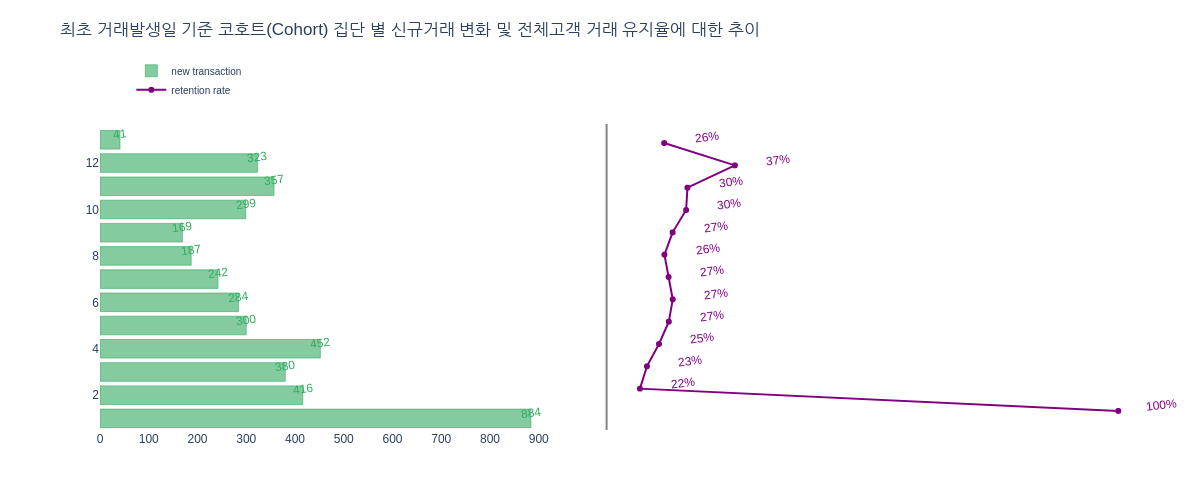

In [ ]:
comp_2_grp(y2=y2nd, y1=y1st, X=x, y2lab='new transaction', y1lab='retention rate', tlt='최초 거래발생일 기준 코호트(Cohort) 집단 별 신규거래 변화 및 전체고객 거래 유지율에 대한 추이', dtick2=100, dtick1=0.1, annot_inter_x2=0.07, annot_inter_x1=0, upload_code=1)

* <font size = 2>Link (Interactive chart) :</font>
> <font size=2>https://chart-studio.plotly.com/create/?fid=junhee:54</font>


In [ ]:
_df1['TotalPrice'] = _df1['UnitPrice'] * _df1['Quantity']
Monthly_consumption = _df1.groupby("get_YearMonth").agg({"TotalPrice": "sum",
                                                         "CustomerID": "nunique"})
Monthly_consumption['Index'] = range(1, len(Monthly_consumption)+1)

y2, y1, x = zip(*Monthly_consumption.values)
x = pd.Series(x).apply(lambda x: int(x))

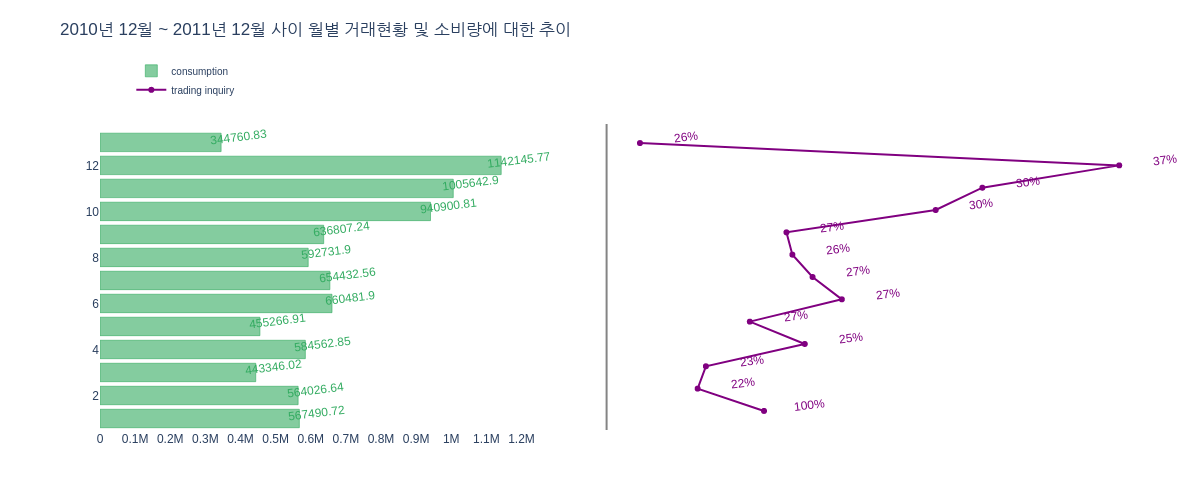

In [ ]:
comp_2_grp(y2, y1, X=x, y2lab='consumption', y1lab='trading inquiry', tlt='2010년 12월 ~ 2011년 12월 사이 월별 거래현황 및 소비량에 대한 추이', dtick2=10 ** 5, dtick1=2*(10 ** 2), annot_inter_x2=10 ** 2, annot_inter_x1=5*(10 ** 4), upload_code=2)

* <font size = 2>Link (Interactive chart) :</font>
> <font size=2>https://chart-studio.plotly.com/create/?fid=junhee:56</font>

<font color = 'white'>.</font>

<center><font color = 'red'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>


## <font size = 3>RFM analysis</font>

<!DOCTYPE html>
<html>

<head>
    <meta charset="utf-8" />
    <meta http-equiv="X-UA-Compatible" content="IE=edge">
    <meta name="viewport" content="width=device-width, initial-scale=1">
</head>

<body>
    <img src="https://sarahtianhua.files.wordpress.com/2015/09/rfm-300x278.png">
</body>

</html>


<font size = 2>‘기업’은 운영과 성장을 위해 평가 기반의 경영이 필수시 됩니다. 더불어, 체계적인 관리를 위해 대표적으로는 R.O.I(Return On Investment)에 기준하여 운영에 따른 성과를 책정합니다. R.O.I는 투자액에 대한 이익률을 나타내는 지표로 아래와 같은 방법으로 계산할 수 있습니다..</font>

<font size = 2>
\begin{align}
        R.O.I = \frac{Return - Investment}{Investment}
    \end{align}
</font>

<font size = 2>“e-commerce market”의 매출 확보는 기업이 보유한 홍보 및 콘텐츠 생산 능력(전략)에 큰 영향을 받을 것입니다. 그러더라도, 본질적으로는 판매와 구매의 활성도에 의존적인 e-commerce 시장에서 마켓을 반복적으로 이용코자 하는 충성고객 유치 즉, <u>소비 패턴에 의거한 "고객유형분류"가 허술하다면, 맞춤화된 홍보, 콘텐츠 생산 전략을 생성할 수 없게되고, 충성고객 유치는 그만큼 어려워질 것입니다.</u></font>

<font size = 2>‘R.F.M’은 Recency + Frequency + Monetary의 약자로 고객관리를 목적으로 고객을 그룹화(Categorization)하는 고전적인 방법입니다. 고객의 그룹화를 위해 <b><u>최근 (R)</u></b>까지 높은 <b><u>빈도 (F)</u></b>로 <b><u>고액 (M)</u></b>의 소비성향을 보일수록 <u>상대적으로 ‘로열그룹'을 구분짓습니다.</u></font>

<font size = 2><b>RFM은 기본적으로 Quantile system을 사용합니다. 이는 데이터를 분할하고자 하는 특정 지표의 점수에 따라 데이터를 분할함을 의미합니다.</b></font>

<font size = 2>- RFM에서는 R, F, M 각각을 4분위수로 5분할 하여 1점부터 5점까지로 점수를 할당하고 최종적으로는 점수를 통합히여 고객을 분류합니다.</font>

<font size = 2>전통적으로는 11 그룹으로 분류 가능하며 각 그룹은 아래와 같이 의미를 부여할 수 있습니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Champions: 구매활동이 최근까지 있었고, 구매주기가 빠르며, 구매액 역시 큰 최상의 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Loyal Customers: 구매액은 높은편에 속하지만 구매주기가 다소 느린 경향을 보입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Potential Loyalist: 새롭게 유입된 고객 중 평균보다 높은 수준의 구매활동을 보이며 한번 이상의 반복구매를 이룬 경험이 있습니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Recent Customers: 가장 최근에 구매를 이루긴 했지만, 구매에 있어 주기성을 띄진 못합니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Promising: 첫 구매 이후로 구매활동이 현저히 드문 고객층입니다.</font>

<font size = 2>- 아래의 6개 그룹은 Naughty SIX로 불리는 추가 그룹입니다. 바교적 R, F, M 점수가 현저히 떨어지지만 우수고객으로서의 잠재력이 높은 그룹을 아래와 같이 분류할 수 있습니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Customers Needing Attention: F, M 점수는 평균 이상인 반면, R 점수가 평균 이하인 경우의 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> About To Sleep: R, F, M 모두가 평균 이하인 경우로 곧 주요고객으로서 제외될 수 있는 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> At Risk: F, M 점수가 과거에 높았던 그룹으로 Lost 그룹과 유사하다고 볼 수 있는 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Can’t Lose Them : At Risk의 유사 그룹이나 상대적으로 3항목의 점수가 낮은 그룹의 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Hibernating: 본사의 서비스 접근이 오래전 끊긴 고객층입니다. 아주 드물게 소비하는 고객층입니다.</font>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/heavy-check-mark.png" width='20'/><font size = 2> Lost: R, F, M 점수가 최 하위권인 고객층입니다.</font>

---

### <img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/sEpHIrx8Hg.png" width = "180">




<img src = "https://cdn.iconscout.com/icon/free/png-256/mobile-keyboard-key-program-coma-semicolon-11562.png" width="30"><font size=2><b><u> 본 분석과정에서 RFM 분석을 선택하게 된 분석경과는 아래와 같습니다.</u></b></font>

<font color = 'white'><font size=2>-</font>

<font size=2>1. <b>우리는 통상 특정 제품을 평가할 때에 "가성비"를 고려</b>하게 됩니다. 내가 지불한 금액이 <u>'적정가'인지</u> 더불어, 저렴한 가격으로 구입을 성공했더라도, <u>품질</u>이 낮은 경우라면 고객은 더 이상의 재구매, 재사용을 고려하지 않게 될 것입니다.</font>

<font size=2>2. <b>제품의 가격변동이 유동적인
 상품, 서비스의 경우</b>라면 어떨까요? 통상 '정기구매'보다도 <u>'다량구매'를 선호</u>하게 될 것입니다.</font>

<font color = 'crimson'><font size=1><b><i>(이는 구매자의 '소득수준' 및 '소비성향'에 의해 변동될 수 있습니다. 이를 '성별', '연령', '직업', '구매상품의 가격대' 등의 데이터로 예측모델을 제작을 시도해볼 수 있겠으나 본 리포트는 해당 데이터 부재로 생략합니다.)</b></i></font>

<font color = 'white'><font size=2>-</font>

<font size = 2><b>위와 같은 가설에 기반하여 'unit price(상품의 단가)'와 'quantity(상품별 판매량)' 간의 '관계성'을 1규명하고, 2분석할 것입니다.</b></font>

#### <font size = 3>1. "단가(Unit price)"와 "구매량(Quantity)" 간의 Correlation Verifying (상관관계 규명)</font>

<font size = 2>- Regression</font>

<img src = "https://cdn.iconscout.com/icon/free/png-256/mobile-keyboard-key-program-coma-semicolon-11562.png" width="30"><font size = 2>'unit price'와 'quantity'간의 관계성 규명을 목표로 '회귀분석'을 진행합니다.

<img src = "https://cdn.iconscout.com/icon/free/png-256/mobile-keyboard-key-program-coma-semicolon-11562.png" width="30"><u>본 분석은 <b>저렴한 가격정책</b>이 <b>주기적인 구매활동을 만들어내는지 여부</b>를 시험하기 위한 것입니다.</u></font>

<font color = 'crimson'><font size=1>***(분석 방법과 관련하여 유념할만한 특이사항은 아래와 같습니다.)***</font>


<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuGBIVSbqpphdYcK6KSRFLvA0jK9LB4e2PHAD0-Q30OR8KBT0hmdwKdz63LvCRX-c04LQ&usqp=CAU" width="50"><font size = 2> 'unit price'와 'quantity'을 그룹화 하여 각 건의 빈도를 '응답변수'로 설정하였습니다.</font>

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuGBIVSbqpphdYcK6KSRFLvA0jK9LB4e2PHAD0-Q30OR8KBT0hmdwKdz63LvCRX-c04LQ&usqp=CAU" width="50"><font size = 2> 더불어, 'unit price'의 경우 [0-1] 사이의 값으로 scaling(정규화)하고, 이를 X일 때 Y (Y=1-X)값을 'unit price'값으로 설정하였습니다. 이는 분석의 목적(가격에 따른 주기적 구매여부 규명)을 위한 것입니다.</font>

In [ ]:
grped_Pr_Qu   = _df1.groupby(['UnitPrice', 'Quantity'])['CustomerID'].sum()
grped_Pr_Qu_  = grped_Pr_Qu.reset_index()

grped_Pr_Qu__ = pd.DataFrame( columns=['x1', 'x2', 'y'])
scaler = MinMaxScaler()
grped_Pr_Qu__.iloc[:, 0], grped_Pr_Qu__.iloc[:, 1], grped_Pr_Qu__.iloc[:, 2] = zip(*scaler.fit_transform(grped_Pr_Qu_.values))
grped_Pr_Qu__ = grped_Pr_Qu__[(grped_Pr_Qu__ == 0).any(axis=1) == False].reset_index(drop=True).copy()
grped_Pr_Qu__['x1'] = 1-grped_Pr_Qu__['x1']

X, y = grped_Pr_Qu__.iloc[:, :2].values, grped_Pr_Qu__.iloc[:, 2].values

if len(X) == len(y):
    n = len(y)
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X, y)
beta_hat = [reg.intercept_] + reg.coef_.tolist()

X1 = np.column_stack((np.ones(n), X))
sigma_hat = np.sqrt(np.sum(np.square(y - X1@beta_hat)) / (n - X1.shape[1]))
beta_cov = np.linalg.inv(X1.T@X1)
t_vals = beta_hat / (sigma_hat * np.sqrt(np.diagonal(beta_cov)))
p_vals = t.sf(np.abs(t_vals), n-X1.shape[1])*2

In [ ]:
Eval_RegressionModel = pd.DataFrame([t_vals, p_vals],
                                    columns=['unit price (predictor variable 1)', 'quantity (predictor variable 2)', 'trading inquiry (response variable)'],
                                    index=['T-value', 'P-value'])

data_table.DataTable(Eval_RegressionModel, include_index=True, num_rows_per_page=2)

,unit price (predictor variable 1),quantity (predictor variable 2),trading inquiry (response variable)
T-value,-0.946137,1.161594,-1.134116
P-value,0.344139,0.245474,0.256818


<font color = 'crimson'><font size=1>***T, P Value에 대한 원리를 아래의 링크에 문서로 작성해두었습니다. 분석된 수치에 대해 보다 구체적인 해석과 증명에 관련된 내용을 확인해 보실 수 있습니다.***</font>

<font color = 'white'><font size=2>-</font>

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/Dxhu9LRH75.png" width = "120">

<font size = 2>**"가격이 저렴할수록 적정량 구입을 주기적으로 진행할 것이다."** 에 대한 회귀계수 유의성 검정(단측검정)에 대해, 유의수준 0.05(5%)에 대한 각 유의 확률 (-1.1341156342551404, 0.2568180208905173) 모두 통계적으로 유의하지 않음으로 귀무가설을 기각할 수 없습니다.</font>

<font size = 2>**"즉, 낮은 단가가 주기적 구매양상에 간접적 영향을 미친다고 볼 수 없다"** 라고 해석할 수 있습니다.</font>

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/VfLdaFMOEQ.png" width = "120">

<font size = 2><b>우리의 가설은 거짓임으로, 단가가 높음과 상관없이 대량구매가 이뤄질 수 있음도 추정범위에 해당합니다.</b></font>

<font size = 2>위와 같은 분석결과를 근거로, 저는 <b>Customer Segmentation</b>을 위해, R.F.M 분석의 <b>M</b>onetary 값을 설정할 때에 단지 전통적인 방법을 따라 <b>Total Price {= (Unit Price) x (Quantity)}</b>를 무조건적으로 활용할 것이 아닌 <b>Unit Price, Quantity 각각의 값을 세분화 한채로 Customer Segmentation을 수행할 필요를 주장합니다.</b></font>

---

#### <font size = 3>2. Change Pattern Analysis</font>

<font size = 2>위 과정에서 주장했던 바 **Customer Segmentation**을 본격적으로 수행하기에 앞서, **Unit Price**, **Quantity**, **Total Price**의 **시간적 변화에 따른 값의 변화 경향** (Trend)를 **분석**, **예측**해봅니다.</font>

<font size = 2>먼저, **상품** (StockCode)에 기준하여 전체 데이터셋을 그룹화 하였습니다. 이 후, 각 데이터셋들의 **표준편차의 평균($\\E({S})$)**보다 ${S}$가 큰 **표본** (Sample)만을 선별하여 시계열 그래프로 시각화 하였습니다.</font>

<font color = 'crimson'><font size=1>***(위의 과정은, 의미적으로 '분산'(편차의 평균)보다 큰 편차를 가진 값들을 선별한 것과 같습니다. 해당 이론에 대한 자세한 자료가 필요하시다면, 다음의 정리문서가 도움이 될 것입니다. https://docs.google.com/document/d/1CQYD6uHHizdy0iAXMeQI7rL2WzbaAA2htFThV1mSJog/edit?usp=sharing)***</font>


In [ ]:
price_nunq  = _df1.groupby('StockCode').UnitPrice.nunique()
over3_codes = list(set(price_nunq[price_nunq >= 3].index))
indexes = list(map(lambda x: np.where(_df1.reset_index(drop=True).StockCode == x)[0].tolist(), over3_codes)); m_indexes = sum(indexes, [])
indexes.sort()

over3_df = _df1.reset_index(drop=True).iloc[m_indexes].reset_index(drop=True)
over3_df.loc[:, 'InvoiceDate'] = over3_df.InvoiceDate.apply(lambda x: pd.to_datetime(x))
over3_dfFv = over3_df.loc[:, ['InvoiceDate', 'StockCode',	'Quantity',	'UnitPrice', 'TotalPrice']].copy()

<font color = 'white'>.</font>

<center><font color = 'blue'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>

In [ ]:
indexL = []
over3_dfFv['extr_date'] = over3_dfFv.InvoiceDate.apply(lambda x: x.date())
y = over3_dfFv.groupby('extr_date')['TotalPrice'].max().reset_index().values
for X in y:
    X1, X2 = X; idx = over3_dfFv[(over3_dfFv['extr_date'] == X1) & (over3_dfFv['TotalPrice'] == X2)].index[0]
    indexL.append(idx)

In [ ]:
X = over3_dfFv.iloc[indexL].iloc[:, 1:]['extr_date']
def YD(y):
    return over3_dfFv.iloc[indexL].iloc[:, 1:][y]

data_dic = {
    'Date':X,
    'UnitPrice':YD('UnitPrice'),
    'Quantity':YD('Quantity'),
    'TotalPrice':YD('TotalPrice')
}; df = pd.DataFrame(data_dic)

df = df.reset_index(drop=True); filename='max_value_grp.csv'
df.to_csv(filename)

In [ ]:
#@title <font color = 'grey'><font size = 3><b>Kalman Filtering</b></font>

'''
    ☑️ 해당 필터는 '계측치'와 '예측치'에 대한 신뢰의 정도를 조절하여 Next state의 예측값을 결정하는 구조입니다.
    ☑️ 하여,  predict function(예측치), update function(계측치)로 나누어 하단에 식을 전개하겠습니다.
    ☑️ 더불어, predict과 update 모두, X, P 즉, 데이터 값, 공분산을 함께 고려합니다.
'''
class kalman_filter():
    # State Update, Covariance Update를 Tuple에 저장합니다. 한 예로, State_t1 = State(X_t1, P_t1)이라면, ((State_t1.X == X_t1) & (State_t1.P == P_t1)) == True가 성립합니다.
    State = namedtuple('State', 'X, P')

    def predict(state, F, Q):
        # F는 해당 시간 t에서의  t-1 상태에 기반한 상태 전이행렬이며, x의 t-1에서의 예측값과 결합됨으로 아래와 같은 '가정 설정문'을 지정합니다.
        assert state.X.shape[0] == F.shape[1]
        assert state.X.shape[1] == 1
        # 전이행렬 'F'와 Process Noise 'Q'값은 대칭행렬이어야 함으로 아래와 같은 '가정 설정문'을 지정합니다.
        assert F.shape[0] == F.shape[1]
        assert Q.shape[0] == Q.shape[1]
        assert Q.shape[0] == F.shape[0]

        x_pred = np.matmul(F, state.X)
        p_pred = np.matmul(F, np.matmul(state.P, F.T)) + Q
        return kalman_filter.State(x_pred, p_pred)

    def update(prior, z, R, H):
        assert prior.X.shape[1] == 1
        assert prior.X.shape[0] == H.shape[1]
        assert H.shape[0] == z.shape[0]
        assert z.shape[1] == 1
        assert prior.P.shape[0] == prior.P.shape[1]
        assert prior.P.shape[1] == H.shape[1]

        z_pred = np.matmul(H, prior.X)
        y = z - z_pred
        # 오차(추정치) 공분산 행렬인 P의 크기가 최소일 때의 K 값을 단계별 K 값으로 결정합니다. 더불어, S의 '역행렬'과 P의 곱을 통해 K(Kalman gain)을 계산합니다. (코드 전개에 대한 수학적 원리를 확인코자 하신다면, 꼭 상단의 첨부문서를 확인해주세요.)
        S = np.matmul(H, np.matmul(prior.P, H.T)) + R
        K = np.matmul(prior.P, np.matmul(H.T, np.linalg.inv(S)))
        x_posterior = prior.X + np.matmul(K, y)
        # P의 Update 값은 P(-)-KHP(-) 값이며, P(-)(1-KH)로 변환할 수 있습니다. (identity를 사용하여 I(단위행렬)을 생성할 수 있습니다.))
        p_posterior = np.matmul((np.identity(prior.P.shape[0]) - np.matmul(K, H)), prior.P)
        return kalman_filter.State(x_posterior, p_posterior)

def main(R_multiplied, target_col, upload_code):
    global gt, res, vel, img_bytes
    tr_intrim, tr_results = [], []
    for Ti in [0, R_multiplied]:
        data, index = [], 0
        target_col = target_col
        with open(filename) as data_file:
            data_reader = csv.DictReader(data_file, delimiter=',')
            for row in data_reader:
                data.append(np.array([[float(row[target_col])]]))

        gt  = {'price': [], 'trend': []}
        res = {'price': [], 'trend': []}
        vel = []

        x = np.full((2, 1), 2)
        P = np.full((2, 2), 2 ** 2)
        state = kalman_filter.State(x, P)

        Q = np.full((2, 2), 1 ** 2)
        F = np.array([[1, 1],
                    [0, 1]])

        # default value is 0
        multiplied_by_any = Ti
        R = np.array([[(0.5 + multiplied_by_any) ** 2]]) #
        H = np.array([[1, 0]])

        counter = 0
        while index < len(data):
            index += 1
            z = data[index - 1]

            if counter == 0:
                x = np.array([[z[0][0]],
                            [0]])
                state = kalman_filter.State(x, P)

            prior = kalman_filter.predict(state, F, Q)
            posterior = kalman_filter.update(prior, z, R, H)
            state = posterior

            gt['price'].append(z[0][0])
            res['price'].append(prior.X[0][0])
            vel.append(prior.X[1][0])

            if counter == 0:
                gt['trend'].append(1)
                res['trend'].append(1)
            else:
                # 현재 시점(state)의 예측값이 이전 시점의 예측 결과값과 비교하여 크면(즉, 증가추세를 보이면) +1, 작으면(동일하거나 감소추세를 보이면) -1로 predicted_trend를 결정합니다.
                predicted_trend = 1 if prior.X[0][0] > res['price'][counter - 1] else -1
                res['trend'].append(predicted_trend)

                gt_trend = 1 if z[0][0] > gt['price'][counter - 1] else -1
                gt['trend'].append(gt_trend)

            counter += 1

        correct_predictions = 0
        for x, y in zip(res['trend'], gt['trend']):
            if x == y:
                correct_predictions += 1

        if Ti == 0:
            print(f"\t \033[1m- data length:\033[0m {len(gt['trend'])} \n")

        print_cp  = f'number of correct_predictions: {correct_predictions}'
        print_acc = f"forcast accuracy: {np.round(np.float(correct_predictions/len(gt['trend'])), 2) * 10**2}%"

        tr_intrim.append([gt, res, vel])
        tr_results.append([print_cp, print_acc])

    print('\n')
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=(f"<i><b>{tr_results[0][0]}, {tr_results[0][1]}  <br><sup>R=default option</b></i></sup>", f"<i><b>{tr_results[1][0]}, {tr_results[1][1]}</b></i>")
                        )

    def to_arr(input_val):
        return np.array(input_val)
    X = pd.to_datetime(df.Date, format='%Y-%m-%d')

    tag = ''
    for i in range(2):
        if i == 1:
            tag = ' - R=default'
        fig.add_trace(go.Scatter(x=X, y=to_arr(tr_intrim[i][0]['price']), name=f'actual price{tag}',
                                 line=dict(color='royalblue', width=3, dash='dot')),
                      row=1, col=i+1)
        fig.add_trace(go.Scatter(x=X, y=to_arr(tr_intrim[i][1]['price']), name=f'predicted price{tag}',
                                 line=dict(color='red', width=2)),
                      row=1, col=i+1)
        if i == 1:
            fig.add_trace(go.Scatter(x=X, y=np.log(tr_intrim[i][2])+10, mode='lines', name=f'actual trend(log scale){tag}',
                                    line=dict(color='grey', width=3)),
                        row=1, col=i+1)

    fig.update_layout(showlegend=False, autosize=False, width=800, height=600,
                      margin=dict(l=5, r=15, b=10, t=30, pad=4), xaxis_title='date time', yaxis_title='', paper_bgcolor='white' )
    fig.update_annotations(font=dict(family='Arial', size=13, color='grey'))
    fig.layout.annotations[0].update(x=0.20, y=0.99)
    fig.layout.annotations[1].update(x=0.75, y=1.001)

    chart_studio.tools.set_credentials_file(username=username, api_key=api_key)
    py.plot(fig, filename = f'kalmanfiltering{upload_code}', auto_open=False)

    img_bytes = fig.to_image(format="png")

	 - data length: 305 





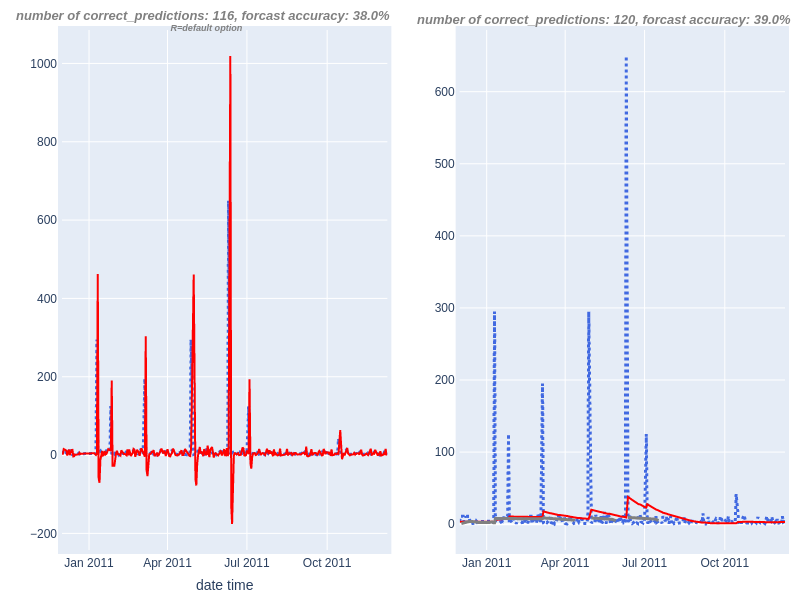

In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'UnitPrice'
if __name__ == '__main__':
    main(R_multiplied, target_col, upload_code=1)

Image(img_bytes)

* <font size = 2>Link (Interactive chart) :</font>
> <font size=2>https://chart-studio.plotly.com/create/?fid=junhee:58</font>



	 - data length: 305 





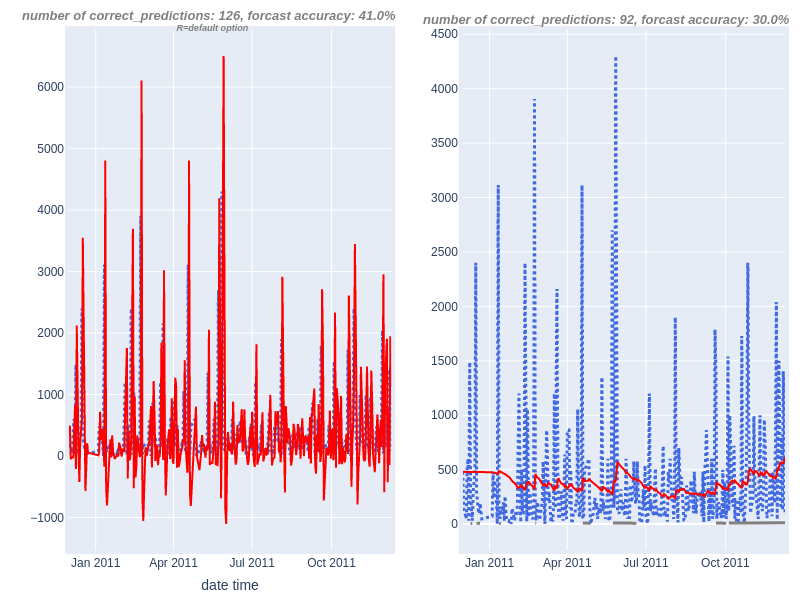

In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'Quantity'
if __name__ == '__main__':
    main(R_multiplied, target_col, upload_code=2)

Image(img_bytes)

* <font size = 2>Link (Interactive chart) :</font>
> <font size=2>https://chart-studio.plotly.com/create/?fid=junhee:71</font>

	 - data length: 305 





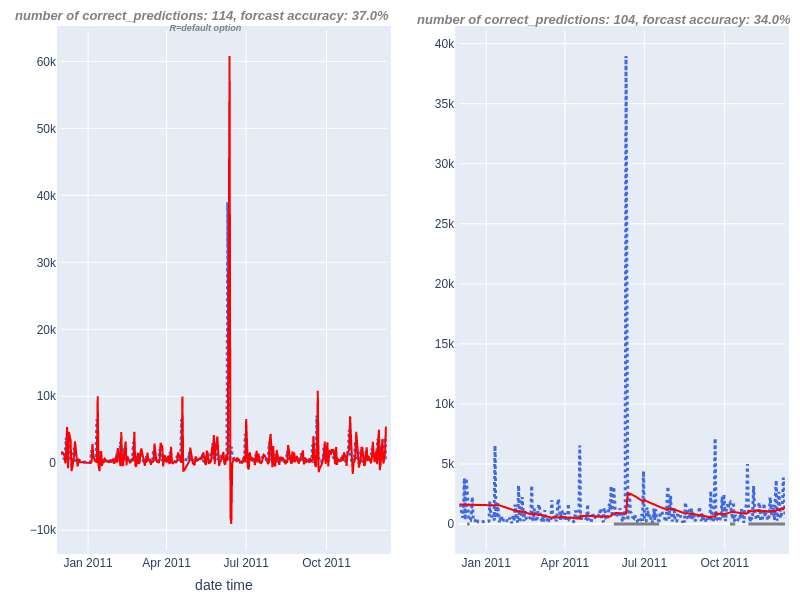

In [ ]:
R_multiplied = 10**3 # default value is 0
target_col = 'TotalPrice'
if __name__ == '__main__':
    main(R_multiplied, target_col, upload_code=3)

Image(img_bytes)

* <font size = 2>Link (Interactive chart) :</font>
> <font size=2>https://chart-studio.plotly.com/create/?fid=junhee:73</font>

<img src = "https://i.esdrop.com/d/f/BCObuUNf7Q/Dxhu9LRH75.png" width = "120">

<font size = 2>**"가격이 저렴할수록 적정량 구입을 주기적으로 진행할 것이다."** 에 대한 회귀계수 유의성 검정(단측검정)에 대해, 유의수준 0.05(5%)에 대한 각 유의 확률 (-1.1341156342551404, 0.2568180208905173) 모두 통계적으로 유의하지 않음으로 귀무가설을 기각할 수 없습니다.</font>

<font size = 2></font>

<font color = 'white'>.</font>

<center><font color = 'red'><font size = 2><i><--></i></font></center>

<font color = 'white'>.</font>


### <font size = 3>Customer Segmentation</font>


	 - R
                     min        std  max  median        mean
Segment_grp                                                 
about_to_sleep        35  10.877256   73    54.0   54.668588
at_Risk               74  68.378886  374   140.0  155.890244
cant_loose            74  66.027784  373   110.0  135.761905
champions              2   3.820839   15     6.0    7.029549
hibernating           74  91.457982  375   221.5  219.353933
loyal_customers       16  15.976348   73    30.0   34.805623
need_attention        35  11.514364   73    54.5   54.047872
new_customers          2   4.061406   15     8.0    8.069767
potential_loyalists    2   9.494930   34    19.0   18.146341
promising             16   5.366947   34    24.5   24.571429



	 - F
                     min        std  max  median       mean
Segment_grp                                                
about_to_sleep         1   0.348741    2     1.0   1.141210
at_Risk                2   0.937036    5     3.0   2.850174
cant_loose  

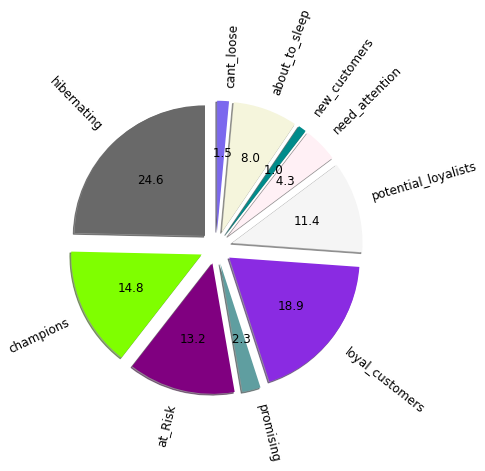

In [ ]:
T_day = max(_df1['InvoiceDate']) + datetime.timedelta(days = 2)
RFM = _df1.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (T_day - x.max()).days,
    'InvoiceNo'  : lambda x: x.nunique(),
    'TotalPrice' : lambda x: x.sum()})

RFM = RFM.reset_index()
RFM.columns = ['ID', 'R', 'F', 'M']

RFM['R_scr'] = pd.qcut(RFM['R'], 5, labels=list(range(1, 6))[::-1])
RFM['F_scr'] = pd.qcut(RFM['F'].rank(method='first'), 5, labels=list(range(1, 6)))
RFM['M_scr'] = pd.qcut(RFM['M'], 5, labels=list(range(1, 6)))

str_typ = lambda colN: RFM[colN].astype(str)
RFM['RF (Segment)'] = str_typ('R_scr') + str_typ('F_scr')
RFM['RFM'] = str_typ('R_scr') + str_typ('F_scr') + str_typ('M_scr')

'''
    seg_map의 두 괄호는 [R][F]의 범위를 의미합니다.
    한 예로, 3[1-2]이라면 R:3, F:1-2 사이의 점수로 구분된 고객층으로 방문빈도('Frequency')는 낮지만, 어능정도 최근까지('Recency') 구매의사를 보인 고객층으로 이해해볼 수 있습니다.
'''
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}
RFM['Segment_grp'] = RFM['RF (Segment)'].replace(seg_map, regex=True)

criteria = ['R', 'F']
RFM_parameters = [RFM.loc[:, ['R', 'F', 'Segment_grp']].groupby('Segment_grp').agg({'min', 'max', 'std', 'mean', 'median'})[x] for x in criteria]
for i, dfi in zip(criteria, RFM_parameters):
    print(f'\n\t {color.BOLD}{color.BLUE}- {i}{color.END}')
    print(dfi)
    print('\n')

random.seed(2023); rfm_grp_colors = random.sample(c_rank, 10)
explodes = [0.25 for x in range(10)]

plt.figure( figsize = (3, 3))
fig = RFM['Segment_grp'].value_counts(sort=False).plot.pie(colors=rfm_grp_colors,
                                                           textprops={'fontsize': 12},
                                                           autopct = '%4.1f',
                                                           startangle= 90,
                                                           radius =2,
                                                           rotatelabels=True,
                                                           shadow = True,
                                                           explode=explodes); plt.ylabel("")
plt.show(fig)